In [ ]:
### Title- Cattle inflammation project
### Analysis includes The analysis includes: 1.DADA2 pipeline; 2.Decontamination using the Decontam and SourceTracker R package
### 3. Evaluation of alpha and beta diversity metrics; 4. Microbial Abundance; 5. Co-occurance analysis; 6. PICRUSt

In [29]:
#Calling R in conda environment 
R.version.string

[1] "R version 4.4.2 (2024-10-31)"

In [30]:
#load required libraries
library(dada2); packageVersion("dada2")
library(phyloseq)
library(ggplot2)
library(ShortRead)  
library(dplyr)
library(stats)
library(Biostrings)
library(ggpubr)
library(vegan)
library(microbiome)

[1] ‘1.34.0’

In [ ]:
### 1. Raw read processing using Trimmomatic
#!/bin/bash

# Define variables
TRIMMO=Trimmomatic-0.39/trimmomatic-0.39.jar
ADAPTERS=Trimmomatic-0.39/Nextera_adapters.fa
OUTDIR=Trimmomatic_trimmed_reads

# Create output directory
mkdir -p $OUTDIR

# Loop through all R1 files
for R1 in *_R1_001.fastq.gz
do
    SAMPLE=$(basename "$R1" _R1_001.fastq.gz)
    R2="${SAMPLE}_R2_001.fastq.gz"

    # Check if both reads exist
    if [[ ! -f "$R1" || ! -f "$R2" ]]; then
        echo "Missing file(s) for sample $SAMPLE. Skipping..."
        continue
    fi

    echo "Processing $SAMPLE..."

    # Run Trimmomatic with HEADCROP:20 and 36 threads
    java -jar "$TRIMMO" PE -threads 36 \
        "$R1" "$R2" \
        "$OUTDIR/${SAMPLE}_R1_paired.fastq.gz" "$OUTDIR/${SAMPLE}_R1_unpaired.fastq.gz" \
        "$OUTDIR/${SAMPLE}_R2_paired.fastq.gz" "$OUTDIR/${SAMPLE}_R2_unpaired.fastq.gz" \
        ILLUMINACLIP:"$ADAPTERS":2:30:10 \
        LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 HEADCROP:20 MINLEN:50 \
        2> "$OUTDIR/${SAMPLE}_trimmomatic.log"

done

#### Copy the trimmed .paired .fastq.gz reads to DADA2_inputs folder

In [ ]:
# 1.1 Uniforming file names . 1. Extraction Controls (N-CONTROL)
for file in N-CONTROL*.fastq.gz; do
  mv "$file" "${file//N-CONTROL/control-extraction-N-CONTROL}"
done

# Renaming Mock Controls (SynMock)
for file in SynMock*.fastq.gz; do
  mv "$file" "${file//SynMock/mock-synthetic}"
done

# Renaming TE Controls
for file in TE-*.fastq.gz; do
  mv "$file" "${file//TE-/control-te-}"
done

# Renaming ZYMO Mock Controls
for file in ZYMO-*.fastq.gz; do
  mv "$file" "${file//ZYMO-/mock-synthetic-ZYMO-}"
done

In [21]:
### 2. Data filtering using DADA2 
# Path to the folder with your FASTQ files
path <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs"
list.files(path)

[1] "1165D1LM_S23_L001_R1_paired.fastq.gz"                      
  [2] "1165D1LM_S23_L001_R2_paired.fastq.gz"                      
  [3] "1165D3LM_S118_L001_R1_paired.fastq.gz"                     
  [4] "1165D3LM_S118_L001_R2_paired.fastq.gz"                     
  [5] "1179-PBS_S91_L001_R1_paired.fastq.gz"                      
  [6] "1179-PBS_S91_L001_R2_paired.fastq.gz"                      
  [7] "1179D1LM_S10_L001_R1_paired.fastq.gz"                      
  [8] "1179D1LM_S10_L001_R2_paired.fastq.gz"                      
  [9] "1179D3LM_S105_L001_R1_paired.fastq.gz"                     
 [10] "1179D3LM_S105_L001_R2_paired.fastq.gz"                     
 [11] "1217-PBS_S92_L001_R1_paired.fastq.gz"                      
 [12] "1217-PBS_S92_L001_R2_paired.fastq.gz"                      
 [13] "1217D1LM_S24_L001_R1_paired.fastq.gz"                      
 [14] "1217D1LM_S24_L001_R2_paired.fastq.gz"                      
 [15] "1217D3LM_S119_L001_R1_paired.fastq.gz"                     
 [16] "1217D3LM_S119_L001_R2_paired.fastq.gz"                     
 [17] "1218D1LM_S12_L001_R1_paired.fastq.gz"                      
 [18] "1218D1LM_S12_L001_R2_paired.fastq.gz"                      
 [19] "1218D3LM_S107_L001_R1_paired.fastq.gz"                     
 [20] "1218D3LM_S107_L001_R2_paired.fastq.gz"                     
 [21] "1226D1LM_S11_L001_R1_paired.fastq.gz"                      
 [22] "1226D1LM_S11_L001_R2_paired.fastq.gz"                      
 [23] "1226D3LM_S106_L001_R1_paired.fastq.gz"                     
 [24] "1226D3LM_S106_L001_R2_paired.fastq.gz"                     
 [25] "1228D1LM_S16_L001_R1_paired.fastq.gz"                      
 [26] "1228D1LM_S16_L001_R2_paired.fastq.gz"                      
 [27] "1228D3LM_S111_L001_R1_paired.fastq.gz"                     
 [28] "1228D3LM_S111_L001_R2_paired.fastq.gz"                     
 [29] "1234D1LM_S26_L001_R1_paired.fastq.gz"                      
 [30] "1234D1LM_S26_L001_R2_paired.fastq.gz"                      
 [31] "1234D3LM_S121_L001_R1_paired.fastq.gz"                     
 [32] "1234D3LM_S121_L001_R2_paired.fastq.gz"                     
 [33] "1261D1LM_S5_L001_R1_paired.fastq.gz"                       
 [34] "1261D1LM_S5_L001_R2_paired.fastq.gz"                       
 [35] "1261D3LM_S100_L001_R1_paired.fastq.gz"                     
 [36] "1261D3LM_S100_L001_R2_paired.fastq.gz"                     
 [37] "1287D1LM_S33_L001_R1_paired.fastq.gz"                      
 [38] "1287D1LM_S33_L001_R2_paired.fastq.gz"                      
 [39] "1287D3LM_S128_L001_R1_paired.fastq.gz"                     
 [40] "1287D3LM_S128_L001_R2_paired.fastq.gz"                     
 [41] "1308D1LM_S47_L001_R1_paired.fastq.gz"                      
 [42] "1308D1LM_S47_L001_R2_paired.fastq.gz"                      
 [43] "1308D3LM_S142_L001_R1_paired.fastq.gz"                     
 [44] "1308D3LM_S142_L001_R2_paired.fastq.gz"                     
 [45] "1314D1LM_S30_L001_R1_paired.fastq.gz"                      
 [46] "1314D1LM_S30_L001_R2_paired.fastq.gz"                      
 [47] "1314D3LM_S125_L001_R1_paired.fastq.gz"                     
 [48] "1314D3LM_S125_L001_R2_paired.fastq.gz"                     
 [49] "1320D1LM_S31_L001_R1_paired.fastq.gz"                      
 [50] "1320D1LM_S31_L001_R2_paired.fastq.gz"                      
 [51] "1320D3LM_S126_L001_R1_paired.fastq.gz"                     
 [52] "1320D3LM_S126_L001_R2_paired.fastq.gz"                     
 [53] "1349D1LM_S49_L001_R1_paired.fastq.gz"                      
 [54] "1349D1LM_S49_L001_R2_paired.fastq.gz"                      
 [55] "1349D3LM_S144_L001_R1_paired.fastq.gz"                     
 [56] "1349D3LM_S144_L001_R2_paired.fastq.gz"                     
 [57] "1355D1LM_S50_L001_R1_paired.fastq.gz"                      
 [58] "1355D1LM_S50_L001_R2_paired.fastq.gz"                      
 [59] "1355D3LM_S145_L001_R1_paired.fastq.gz"                     
 [60] "1355D3LM_S145_L001_R2_paired.fastq.gz"    

In [22]:
# Forward and reverse fastq filenames
fnFs <- sort(list.files(path, pattern = "_R1.paired.fastq.gz", full.names = TRUE))
fnRs <- sort(list.files(path, pattern = "_R2.paired.fastq.gz", full.names = TRUE))

In [23]:
# Extract sample names
sample.names <- sapply(strsplit(basename(fnFs), "_"), `[`, 1)

In [24]:
# Place filtered files in filtered/ subdirectory
filtFs <- file.path(path, "filtered", paste0(sample.names, "_F_filt.fastq.gz"))
filtRs <- file.path(path, "filtered", paste0(sample.names, "_R_filt.fastq.gz"))
names(filtFs) <- sample.names
names(filtRs) <- sample.names

Warning message:
“Removed 932 rows containing missing values or values outside the scale range
(`geom_tile()`).”
Warning message:
“Removed 1133 rows containing missing values or values outside the scale range
(`geom_tile()`).”


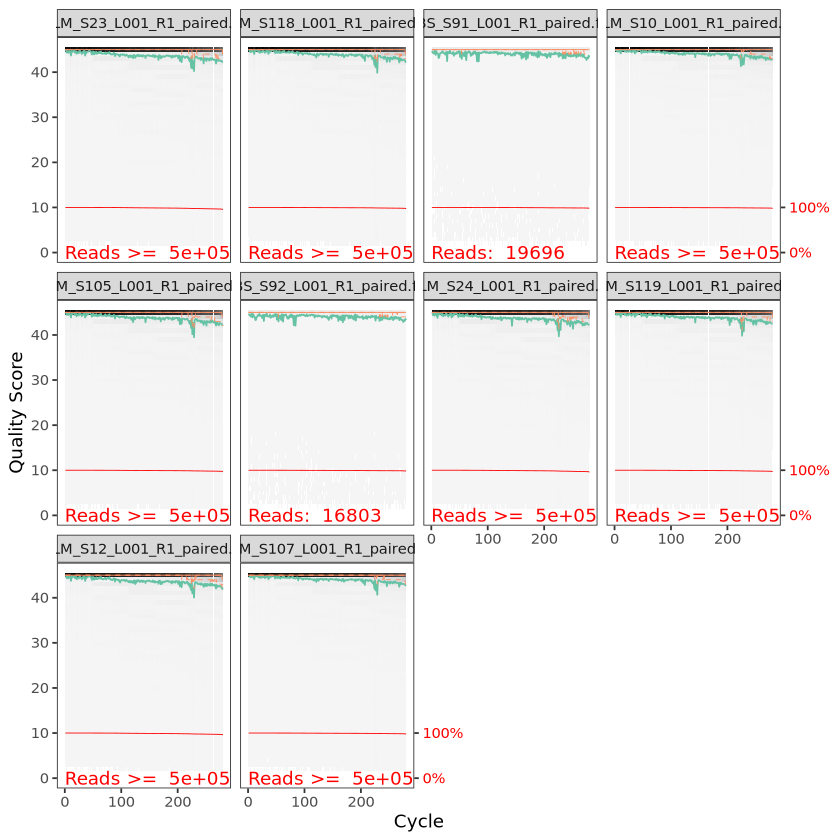

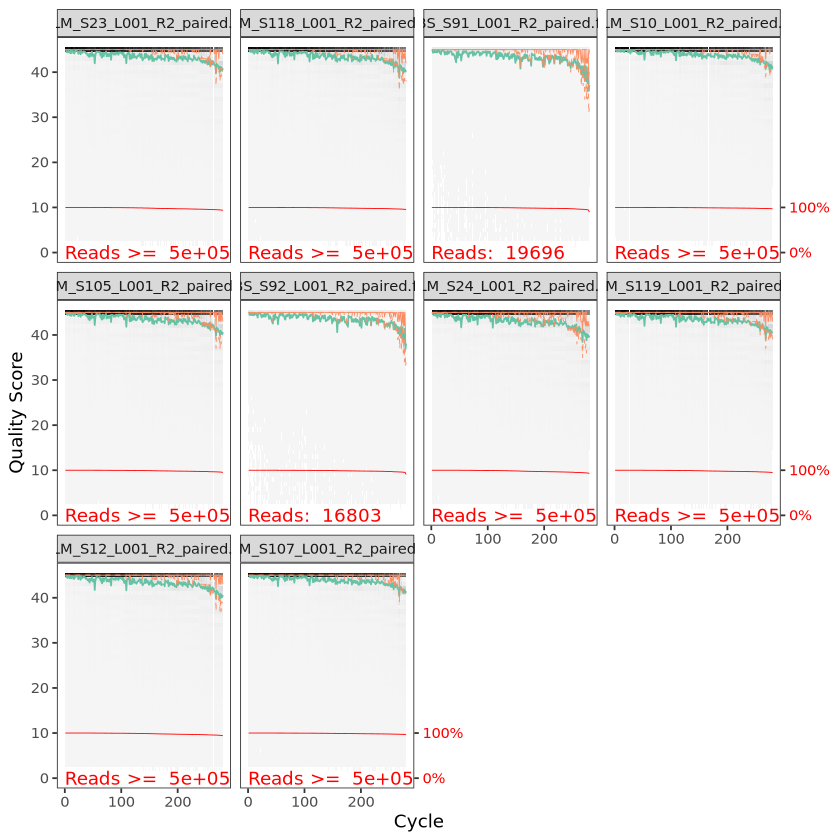

In [221]:
# Check quality of the reads
plotQualityProfile(fnFs[1:10])
plotQualityProfile(fnRs[1:10])

In [ ]:
# Filter and trim the reads
out <- filterAndTrim(fnFs, filtFs, fnRs, filtRs, trimLeft=c(20,17), truncLen=c(240,220),
              maxN=0, maxEE=c(3,4), truncQ=2, rm.phix=TRUE,
              compress=TRUE, multithread=TRUE)
head(out)

In [9]:
# Create output directory
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

In [10]:
path.rds <- output_dir
path.figures <- output_dir

In [11]:
saveRDS(out, file.path(output_dir, "filter_trim_summary.rds"))
saveRDS(filtFs, file.path(output_dir, "filtFs.rds"))
saveRDS(filtRs, file.path(output_dir, "filtRs.rds"))

In [12]:
# Learn error rates for forward and reverse reads
errF <- learnErrors(filtFs, multithread=TRUE)
saveRDS(errF,   file.path(output_dir, "errF.rds"))
errR <- learnErrors(filtRs, multithread=TRUE)
saveRDS(errR,   file.path(output_dir, "errR.rds"))

112869680 total bases in 513044 reads from 1 samples will be used for learning the error rates.
104147932 total bases in 513044 reads from 1 samples will be used for learning the error rates.


In [27]:
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

# Individually load each .rds file
errF <- readRDS(file.path(output_dir, "errF.rds"))
errR <- readRDS(file.path(output_dir, "errR.rds"))
filter_trim_summary <- readRDS(file.path(output_dir, "filter_trim_summary.rds"))
filtFs <- readRDS(file.path(output_dir, "filtFs.rds"))
filtRs <- readRDS(file.path(output_dir, "filtRs.rds"))

In [9]:
# Denoise forward reads
dadaFs <- dada(filtFs, err=errF, multithread=TRUE)
saveRDS(dadaFs, file.path(output_dir, "dadaFs.rds"))

Sample 1 - 513044 reads in 90675 unique sequences.
Sample 2 - 580336 reads in 100365 unique sequences.
Sample 3 - 17034 reads in 1816 unique sequences.
Sample 4 - 491328 reads in 75283 unique sequences.
Sample 5 - 562995 reads in 86809 unique sequences.
Sample 6 - 14495 reads in 1736 unique sequences.
Sample 7 - 491971 reads in 57200 unique sequences.
Sample 8 - 445873 reads in 63950 unique sequences.
Sample 9 - 534166 reads in 91146 unique sequences.
Sample 10 - 439425 reads in 89976 unique sequences.
Sample 11 - 485071 reads in 78707 unique sequences.
Sample 12 - 504308 reads in 93880 unique sequences.
Sample 13 - 425732 reads in 77193 unique sequences.
Sample 14 - 465407 reads in 79216 unique sequences.
Sample 15 - 515886 reads in 76341 unique sequences.
Sample 16 - 508294 reads in 97454 unique sequences.
Sample 17 - 488282 reads in 89427 unique sequences.
Sample 18 - 430117 reads in 75142 unique sequences.
Sample 19 - 640065 reads in 76328 unique sequences.
Sample 20 - 574871 reads

Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”
Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”


In [6]:
# Denoise reverse reads
dadaRs <- dada(filtRs, err=errR, multithread=TRUE)
saveRDS(dadaRs, file.path(output_dir, "dadaRs.rds"))

Sample 1 - 513044 reads in 50468 unique sequences.
Sample 2 - 580336 reads in 54877 unique sequences.
Sample 3 - 17034 reads in 1553 unique sequences.
Sample 4 - 491328 reads in 40617 unique sequences.
Sample 5 - 562995 reads in 47771 unique sequences.
Sample 6 - 14495 reads in 1278 unique sequences.
Sample 7 - 491971 reads in 38142 unique sequences.
Sample 8 - 445873 reads in 36817 unique sequences.
Sample 9 - 534166 reads in 50425 unique sequences.
Sample 10 - 439425 reads in 43610 unique sequences.
Sample 11 - 485071 reads in 45588 unique sequences.
Sample 12 - 504308 reads in 49165 unique sequences.
Sample 13 - 425732 reads in 40748 unique sequences.
Sample 14 - 465407 reads in 41275 unique sequences.
Sample 15 - 515886 reads in 47390 unique sequences.
Sample 16 - 508294 reads in 50120 unique sequences.
Sample 17 - 488282 reads in 48946 unique sequences.
Sample 18 - 430117 reads in 40208 unique sequences.
Sample 19 - 640065 reads in 52903 unique sequences.
Sample 20 - 574871 reads 

Warning message in rval[, 1:ncol(tt)] + tt:
“NAs produced by integer overflow”


In [7]:
# Merge paired reads
mergers <- mergePairs(dadaFs, filtFs, dadaRs, filtRs, verbose=TRUE)
head(mergers[[1]])
length(mergers)
saveRDS(mergers, file.path(output_dir, "mergers.rds"))

437136 paired-reads (in 6449 unique pairings) successfully merged out of 498271 (in 35701 pairings) input.

491549 paired-reads (in 7473 unique pairings) successfully merged out of 564029 (in 43163 pairings) input.

16941 paired-reads (in 195 unique pairings) successfully merged out of 16990 (in 200 pairings) input.

434631 paired-reads (in 5452 unique pairings) successfully merged out of 479050 (in 28332 pairings) input.

487253 paired-reads (in 6669 unique pairings) successfully merged out of 549434 (in 33713 pairings) input.

14022 paired-reads (in 190 unique pairings) successfully merged out of 14439 (in 199 pairings) input.

450064 paired-reads (in 4158 unique pairings) successfully merged out of 484364 (in 18385 pairings) input.

388346 paired-reads (in 4686 unique pairings) successfully merged out of 436226 (in 23816 pairings) input.

454419 paired-reads (in 5870 unique pairings) successfully merged out of 521031 (in 36091 pairings) input.

361569 paired-reads (in 6638 unique pa

,sequence,abundance,forward,reverse,nmatch,nmismatch,nindel,prefer,accept
,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<lgl>
1,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGTGGTTTCTTAAGTCAGAGGTGAAAGGCTACGGCTCAACCGTAGTAAGCCTTTGAAACTGGGAAACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTTGCGAAGGCGGCTCTCTGGACTGTAACTGACACTGAGGCACGAAAG,10390,1,1,60,0,0,1,TRUE
2,AAAGCCTGATGGTGCGACGCCGCGTGGGGGAGGAAGGTCTTCGGATTGTAAACCCCTGTCATGTGGGAGCAAGACTTCGGTTTGATAGTACCACAAGAGGAAGAGACGGCAAACTCTGTGCCAGCAGCCGCGGTAATACAGAGGTCTCAAGCGTTGTTCGGAATCACTGGGCGTAAAGGGTACGTAGGCGGCATCATAAGTCGTGCGTGAAAGGCAGGGGCTCAACCTCTGGAGTGCGCGTGATACTGTGATGCTGGAGTAATGGAGGGGGAACCGGAATTCTTGGTGTAGCAGTGAAATGCGTAGATATCAAGAAGAAGACTCGTGGCGAAGGCGGGTTCCTGGACATTTACTGACGCTGAGGTACGAAGG,7238,3,4,51,0,0,2,TRUE
3,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGAATTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGCCAGAAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTTTTGGAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTAGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAG,6823,2,7,60,0,0,2,TRUE
4,GACGACTGAACCAGCCATGCCGCGTGAAGGTCACGGCCCTATGGGTCTTAAACTTCTTTTGTAAGGGAGCAATAAGTCTCACGTGTGGGATGATGAGAGTACCTTACGAATAAGCATCGGCTAACTCCGTGCCAGCAGCCGCGGTAATACGGGGGATGCAAGCGTTATCCGGATTTATTGGGTTTAAAGGGTGCGTAGGCGGCGTCTTAAGTCAGCGGTGAAATTTAGGGGCTCAACCTCTACCGTGCCGTTGATACTGGGATGCTGGAATGCGGATGCCGTGGGAGGAATGTGTGGTGTAGCGGTGAAATGCATAGATATCACACAGAACACCGATTGCGAAGGCATCTCACGAATCCGCTATTGACGCTGAGGCACGAAAG,5084,4,10,40,0,0,2,TRUE
5,AAAGCCTGACCGAGCAACGCCGCGTGAATGATGAAGGCCTTCGGGTTGTAAAATTCTGTTATAAGGGAAGAACGACTTTAGTAGGAAATGGCTAAAGTGTGACGGTACCTTATGAGAAAGCCACGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGTGGCAAGCGTTATCCGGAATTATTGGGCGTAAAGAGCGCGCAGGTGGTTGATTAAGTCTGATGTGAAAGCCCACGGCTTAACCGTGGAGGGTCATTGGAAACTGGTCGACTTGAGTGCAGAAGAGGGAAGTGGAATTCCATGTGTAGCGGTGAAATGCGTAGAGATATGGAGGAACACCAGTGGCGAAGGCGGCTTCCTGGTCTGTAACTGACACTGAGGCGCGAAAG,4898,5,8,34,0,0,2,TRUE
6,AAAGCCTGATGCAGCAACGCCGCGTGAGCGATGAAGGCCTTCGGGTCGTAAAGCTCTGTCCTCAAGGAAGATAATGACGGTACTTGAGGAGGAAGCCCCGGCTAACTACGTGCCAGCAGCCGCGGTAATACGTAGGGGGCTAGCGTTATCCGGATTTACTGGGCGTAAAGGGTGCGTAGGCGGTCTTTCAAGTCAGGAGTGAAAGGCTACGGCTCAACCGTAGTAAGCTCTTGAAACTGTAAGACTTGAGTGCAGGAGAGGAGAGTGGAATTCCTAGTGTAGCGGTGAAATGCGTAGATATTAGGAGGAACACCAGTTGCGAAGGCGGCTCTCTGGACTGTAACTGACGCTGAGGCACGAAAG,4300,6,14,60,0,0,1,TRUE


[1] 162

1165D1LM 1165D3LM 1179-PBS 1179D1LM 1179D3LM 1217-PBS 
  437136   491549    16941   434631   487253    14022

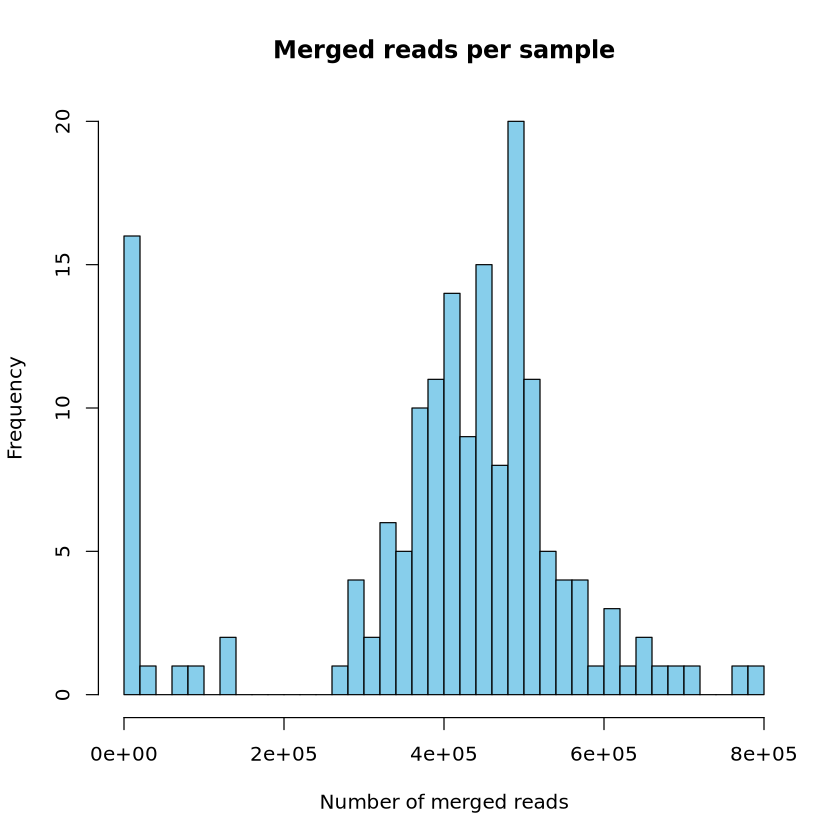

In [8]:
merged_counts <-sapply(mergers, function(x) sum(x$abundance)) #How many reads were successfully merged per sample!
head(merged_counts) #Quick table of the total merged reads per sample.

#visualize the distribution of merged reads
hist(merged_counts, main = "Merged reads per sample",
     xlab = "Number of merged reads", ylab = "Frequency",
     col = "skyblue", breaks = 30)

In [14]:
# Remove chimeras
seqtab <- makeSequenceTable(mergers)#Create a sequence table
dim(seqtab)
seqtab2 <- seqtab[,nchar(colnames(seqtab)) %in% 250:258]
sum(seqtab2)/sum(seqtab)
saveRDS(seqtab, file.path(output_dir, "seqtab.rds"))

[1]    162 151077

[1] 4.102491e-05

In [15]:
table(nchar(getSequences(seqtab)))
length_table <- table(nchar(getSequences(seqtab)))
saveRDS(length_table, file.path(output_dir, "length_table.rds"))


  220   221   222   223   224   225   226   227   228   229   230   231   232 
 2903   134  2903   360   177    58    34   118    39    25    35    33    28 
  233   234   235   236   237   238   239   240   241   242   243   244   245 
   21    24    70    34    27    22    19    11    13    27    21    17    18 
  246   247   248   249   250   251   252   253   254   255   256   257   258 
   27   112    15    21    34    22    35    38    27    34    49     7    11 
  259   260   261   262   263   264   265   266   267   268   269   270   271 
   14    11    18    21    36    79    14    24    22    16    12    17    20 
  272   273   274   275   276   277   278   279   280   281   282   283   284 
   39    10     7     3    26    49    13    37    20    10    15    13    14 
  285   286   287   288   289   290   291   292   293   294   295   296   297 
   15    19    20    49    20    14    36    39    18    19    13    79    12 
  298   299   300   301   302   303   304   305   3

In [17]:
#Remove bimeras
seqtab.nochim <- removeBimeraDenovo(seqtab, method="consensus", multithread=TRUE, verbose=TRUE)
dim(seqtab.nochim)
sum(seqtab.nochim)/sum(seqtab)
saveRDS(dim(seqtab.nochim), file.path(output_dir, "seqtab_nochim_dim.rds"))
saveRDS(sum(seqtab.nochim) / sum(seqtab), file.path(output_dir, "seqtab_nochim_ratio.rds"))
saveRDS(seqtab.nochim, file.path(output_dir, "seqtab_nochim.rds"))

Identified 118024 bimeras out of 151077 input sequences.



[1]   162 33053

[1] 0.9329143

In [31]:
errF <- readRDS(file.path(output_dir, "errF.rds"))
errR <- readRDS(file.path(output_dir, "errR.rds"))
filtFs <- readRDS(file.path(output_dir, "filtFs.rds"))
filtRs <- readRDS(file.path(output_dir, "filtRs.rds"))
out <- readRDS(file.path(output_dir, "filter_trim_summary.rds"))
dadaFs <- readRDS(file.path(output_dir, "dadaFs.rds"))
dadaRs <- readRDS(file.path(output_dir, "dadaRs.rds"))
length_table <- readRDS(file.path(output_dir, "length_table.rds"))
mergers <- readRDS(file.path(output_dir, "mergers.rds"))
seqtab <- readRDS(file.path(output_dir, "seqtab.rds"))
seqtab_nochim_dim <- readRDS(file.path(output_dir, "seqtab_nochim_dim.rds"))
seqtab_nochim_ratio <- readRDS(file.path(output_dir, "seqtab_nochim_ratio.rds"))
taxa <- readRDS(file.path(output_dir, "taxa_species.rds"))
taxa <- readRDS(file.path(output_dir, "taxa_assignments.rds"))
taxa_filtered <- readRDS(file.path(output_dir, "taxa_wo_chloroplast_mitochondria.rds"))

In [ ]:
# Track read retention through the pipeline
getN <- function(x) sum(getUniques(x))
track <- cbind(out, sapply(dadaFs, getN), sapply(dadaRs, getN), sapply(mergers, getN), rowSums(seqtab.nochim))
colnames(track) <- c("input", "filtered", "denoisedF", "denoisedR", "merged", "nonchim")
rownames(track) <- sample.names
head(track)
write.table(track, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/track_reads_summary.csv", row.names = TRUE, col.names = NA, sep = ",", dec = ".", qmethod = "double")

In [19]:
#### Adding track table to the metadata
metadata <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/Cow_FecalMicrobiome_Metadata-2_Updated.csv", stringsAsFactors = FALSE)
track_reads <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/track_reads_summary.csv", stringsAsFactors = FALSE)

merged_metadata <- left_join(metadata, track_reads, by = c("Sample_ID" = "X"))

write.csv(merged_metadata, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Cow_FecalMicrobiome_Metadata.csv", row.names = FALSE)


In [32]:
# Assign taxonomy
taxa <- assignTaxonomy(seqtab.nochim, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/silva_nr99_v138.2_toGenus_trainset.fa", multithread=TRUE)
saveRDS(taxa, file.path(output_dir, "taxa_assignments.rds"))

In [33]:
taxa.print <- taxa
rownames(taxa.print) <- NULL
head(taxa.print)

Kingdom,Phylum,Class,Order,Family,Genus
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria


In [34]:
# Assign taxonomy_species
taxa <- addSpecies(taxa, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/silva_v138.2_assignSpecies.fa")
saveRDS(taxa, file.path(output_dir, "taxa_species.rds"))

In [35]:
taxa.print <- taxa
rownames(taxa.print) <- NULL
head(taxa.print)

Kingdom,Phylum,Class,Order,Family,Genus,Species
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Romboutsia,NA
Bacteria,Bacillota,Bacilli,Erysipelotrichales,Erysipelotrichaceae,Turicibacter,NA
Bacteria,Actinomycetota,Actinobacteria,Bifidobacteriales,Bifidobacteriaceae,Bifidobacterium,NA
Bacteria,Bacillota,Clostridia,Clostridiales,Clostridiaceae,Clostridium,NA
Bacteria,Bacillota,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paeniclostridium,NA
Bacteria,Bacillota,Bacilli,Lactobacillales,Listeriaceae,Listeria,NA


In [36]:
# Check number of chloroplast sequences
sum(taxa[, "Order"] == "Chloroplast", na.rm = TRUE)

# Check number of mitochondrial sequences
sum(taxa[, "Family"] == "Mitochondria", na.rm = TRUE)

# View the actual rows (optional)
chloroplast_taxa <- taxa[taxa[, "Order"] == "Chloroplast", , drop = FALSE]
mitochondria_taxa <- taxa[taxa[, "Family"] == "Mitochondria", , drop = FALSE]

# View if any exist
if (nrow(chloroplast_taxa) > 0) print(chloroplast_taxa)
if (nrow(mitochondria_taxa) > 0) print(mitochondria_taxa)


[1] 67

[1] 249

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [43]:
# Remove chloroplast and mitochondrial DNA
taxa_filtered <- taxa[!(taxa[, "Order"] == "Chloroplast" | taxa[, "Family"] == "Mitochondria"), ]
saveRDS(taxa_filtered, file.path(output_dir, "taxa_wo_chloroplast_mitochondria.rds"))

In [57]:
###Create Phyloseq Object Without Positive Controls
# Subset OTU table to match filtered taxonomy
seqtab.filtered <- seqtab.nochim[, colnames(seqtab.nochim) %in% rownames(taxa_filtered)]
# Create OTU table
seq <- otu_table(seqtab.filtered, taxa_are_rows = FALSE)
# Create taxonomy table
tax <- tax_table(taxa_filtered)

In [58]:
##Preparing the metadata
# Read the metadata CSV
meta <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_inputs/Cow_FecalMicrobiome_Metadata.csv", 
                 stringsAsFactors = FALSE, check.names = FALSE)
meta$Corrected_Sample_ID <- trimws(meta$Corrected_Sample_ID)
# Set the rownames to the corrected sample ID
rownames(meta) <- meta$Corrected_Sample_ID
# Trim whitespace from sample ID column (in case there are any hidden spaces)
meta$Corrected_Sample_ID <- trimws(meta$Corrected_Sample_ID)
sample_names(seq) <- trimws(sample_names(seq))
#Corrections to the naming pattern
sample_names(seq) <- sub("^(1179|1217|302|6767)-PBS$", "\\1D1LM-PBS", sample_names(seq))
sample_names(seq) <- gsub("^1359D1LM$", "1354D1LM", sample_names(seq)) #1354 is the correct one
sample_names(seq) <- gsub("^1359D3LM$", "1354D3LM", sample_names(seq))
# Subset metadata to match samples in seq (removes mock-synthetic1 and 2)
meta <- meta[sample_names(seq), ]
#Check identicals #It should return TRUE if correct
identical(sample_names(seq), rownames(meta))

[1] TRUE

Determining distance matrix based on shared 8-mers:

Time difference of 7.72 secs

Clustering into groups by similarity:

Time difference of 3.16 secs

Aligning Sequences:

Time difference of 32.19 secs

Iteration 1 of 2:

Determining distance matrix based on alignment:

Time difference of 1.05 secs

Reclustering into groups by similarity:

Time difference of 3.36 secs

Realigning Sequences:

Time difference of 17.94 secs

Iteration 2 of 2:

Determining distance matrix based on alignment:

Time difference of 1.13 secs

Reclustering into groups by similarity:

Time difference of 3.39 secs

Realigning Sequences:

Time difference of 6.92 secs

Refining the alignment:

Time difference of 0.64 secs



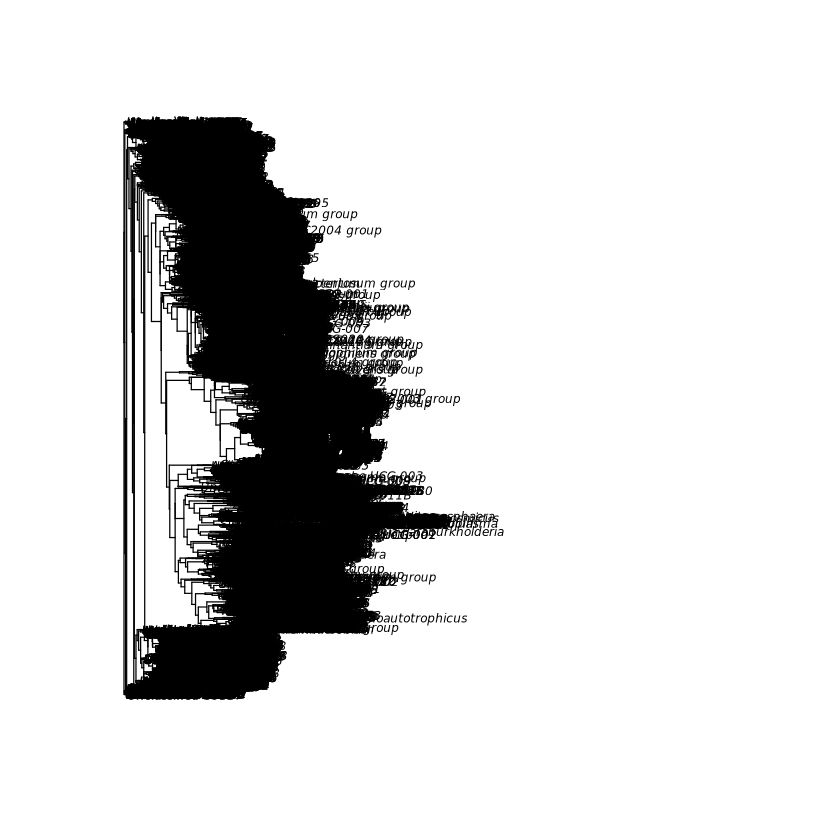

In [60]:
##### Phylogenetic Tree Construction using Filtered ASV Table #####

# Load required libraries
library(Biostrings)
library(DECIPHER)
library(phangorn)
library(ape)

# Use already-filtered ASV table and taxonomy
seqtab <- seqtab_filtered
taxa <- taxa_filtered

# Step 1: Keep only ASVs that exist in both seqtab and taxonomy
shared_asvs <- intersect(colnames(seqtab), rownames(taxa))
seqtab <- seqtab[, shared_asvs]
taxa <- taxa[shared_asvs, , drop = FALSE]

# Step 2: Filter ASVs with total read count > 10 across all samples
asv_abund <- colSums(seqtab)
keep_asvs <- asv_abund > 10
seqtab_filt <- seqtab[, keep_asvs]
asv_seqs_filt <- colnames(seqtab_filt)
taxa_filt <- taxa[asv_seqs_filt, , drop = FALSE]

# Step 3: Assign genus names (use "Unclassified_x" if Genus is NA)
genus_names <- ifelse(is.na(taxa_filt[, "Genus"]), 
                      paste0("Unclassified_", seq_along(taxa_filt[, "Genus"])), 
                      taxa_filt[, "Genus"])
unique_genera <- unique(genus_names)

# Step 4: Pick one ASV per genus (most abundant)
rep_asv_indices <- sapply(unique_genera, function(g) {
  inds <- which(genus_names == g)
  abundances <- colSums(seqtab_filt[, inds, drop = FALSE])
  inds[which.max(abundances)]
})

rep_asv_seqs <- asv_seqs_filt[rep_asv_indices]

# Step 5: Convert representative sequences to DNAStringSet
rep_dna <- DNAStringSet(rep_asv_seqs)
names(rep_dna) <- unique_genera

# Step 6: Align representative sequences
alignment <- AlignSeqs(rep_dna, processors = 32)  # adjust cores if needed

# Step 7: Convert alignment to phyDat and compute distance matrix
phang_align <- phyDat(as(alignment, "matrix"), type = "DNA")
dm <- dist.ml(phang_align)

# Step 8: Build neighbor-joining tree
treeNJ <- NJ(dm)

# Step 9: Optimize tree using GTR model (light optimization)
fit <- pml(treeNJ, data = phang_align)
fit_opt <- optim.pml(fit, model = "GTR", optInv = FALSE, optGamma = FALSE,
                     rearrangement = "none", control = pml.control(trace = 0))

# Step 10: Save and plot tree
saveRDS(fit_opt$tree, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree.rds")
plot(fit_opt$tree, cex = 0.6)


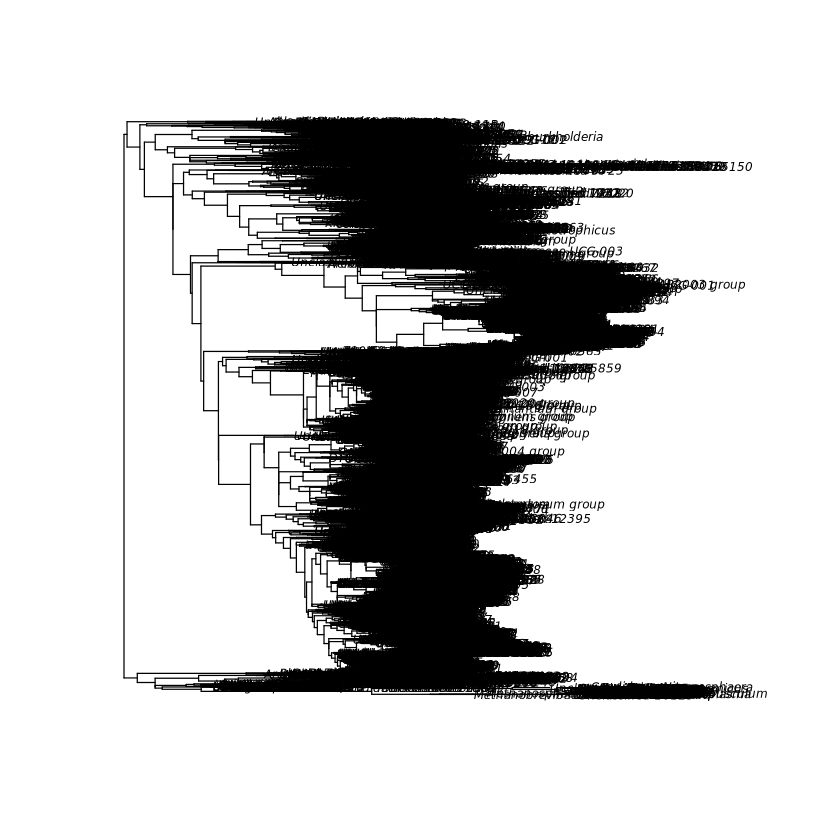

In [61]:
library(ape)
tree_rooted <- midpoint(fit_opt$tree)
# Save rooted tree
saveRDS(tree_rooted, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree_rooted.rds")

# Optional plot
plot(tree_rooted, cex = 0.6)


In [63]:
# Create phyloseq object with positive control
# ----------- Load Required Packages -----------
library(phyloseq)
library(Biostrings)

# ----------- Define Output Directory -----------
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

# ----------- Create DNAStringSet from ASV sequences -----------
dna <- DNAStringSet(colnames(seqtab))
names(dna) <- colnames(seqtab)

# ----------- Build phyloseq components -----------
otu <- otu_table(seqtab, taxa_are_rows = FALSE)
tax <- tax_table(taxa_filtered)
sampdata <- sample_data(meta)

# ----------- Build phyloseq object with all samples -----------
ps <- phyloseq(otu, tax, sampdata, dna)

# ----------- Save the phyloseq object -----------
saveRDS(ps, file = file.path(output_dir, "phyloseq.rds"))

## Phyloseq with controls (Mock, negative control)


In [64]:
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23387 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 23387 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 23387 reference sequences ]

In [65]:
### 14. Phyloseq Object for Positive Control/Mock
# Phyloseq for positive samples
seqtab.positive <- seqtab.nochim[grepl("mock", rownames(seqtab.nochim), ignore.case = TRUE), ]
dim(seqtab.positive)
# Create phyloseq components
seq.positive <- otu_table(seqtab.positive, taxa_are_rows = FALSE)
# Subset samples that are mocks 
mock_samples <- grep("mock", sample_names(ps), ignore.case = TRUE, value = TRUE)

# Subset phyloseq object for mock samples only
ps.mock <- prune_samples(mock_samples, ps)

# Optionally prune taxa not present in these samples
ps.mock <- prune_taxa(taxa_sums(ps.mock) > 0, ps.mock)

# Check
ps.mock

# Save mock phyloseq object
saveRDS(ps.mock, file = file.path(output_dir, "ps.mock.rds"))
#ps.mock.rds is the phyloseq object for mock/positive samples

[1]     5 33053

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1358 taxa and 5 samples ]
sample_data() Sample Data:       [ 5 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 1358 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 1358 reference sequences ]

In [66]:
# Mock community #
#Define base identifiers for each mock group
mockA <- c("mock-synthetic-ZYMO-1", "mock-synthetic-ZYMO-2", "mock-synthetic-ZYMO-3")
mockB <- c("mock-synthetic-ZYMO-4", "mock-synthetic-ZYMO-5")

# Match actual sample names in ps.mock using pattern matching
mockA_samples <- grep(paste(mockA, collapse = "|"), sample_names(ps.mock), value = TRUE)
mockB_samples <- grep(paste(mockB, collapse = "|"), sample_names(ps.mock), value = TRUE)

In [67]:
### Generate phyloseq object for each mock community
# MOCK A
ps.mockA <- prune_samples(mockA_samples, ps.mock)
ps.mockA <- prune_taxa(taxa_sums(ps.mockA) > 0, ps.mockA)
saveRDS(ps.mockA, file = file.path(output_dir, "ps.mockA.rds"))

# MOCK B
ps.mockB <- prune_samples(mockB_samples, ps.mock)
ps.mockB <- prune_taxa(taxa_sums(ps.mockB) > 0, ps.mockB)
saveRDS(ps.mockB, file = file.path(output_dir, "ps.mockB.rds"))


In [71]:
ps.mockA
ps.mockB

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1203 taxa and 3 samples ]
sample_data() Sample Data:       [ 3 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 1203 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 1203 reference sequences ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 169 taxa and 2 samples ]
sample_data() Sample Data:       [ 2 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 169 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 169 reference sequences ]

In [69]:
# Count ASVs
n_asvs_mockA <- ntaxa(ps.mockA)
n_asvs_mockB <- ntaxa(ps.mockB)

# Total reads (summed across all samples in each mock group)
total_reads_mockA <- sum(sample_sums(ps.mockA))
total_reads_mockB <- sum(sample_sums(ps.mockB))

# Output
cat("Number of ASVs in MOCK A:", n_asvs_mockA, "\n")
cat("Total read count in MOCK A:", total_reads_mockA, "\n\n")

cat("Number of ASVs in MOCK B:", n_asvs_mockB, "\n")
cat("Total read count in MOCK B:", total_reads_mockB, "\n")

Number of ASVs in MOCK A: 1203 
Total read count in MOCK A: 2048792 

Number of ASVs in MOCK B: 169 
Total read count in MOCK B: 1055584 


In [70]:
##### Predict sequencing quality
# Load libraries
library(dada2)
library(ggplot2)
library(ggpubr)
library(patchwork)
library(dplyr)
library(gghalves)
library(phyloseq)
library(decontam)
library(dplyr)
library(pairwiseAdonis)
library(microbiome)
library(forcats)

Loading required package: cluster

Warning message:
“package ‘cluster’ was built under R version 4.4.3”


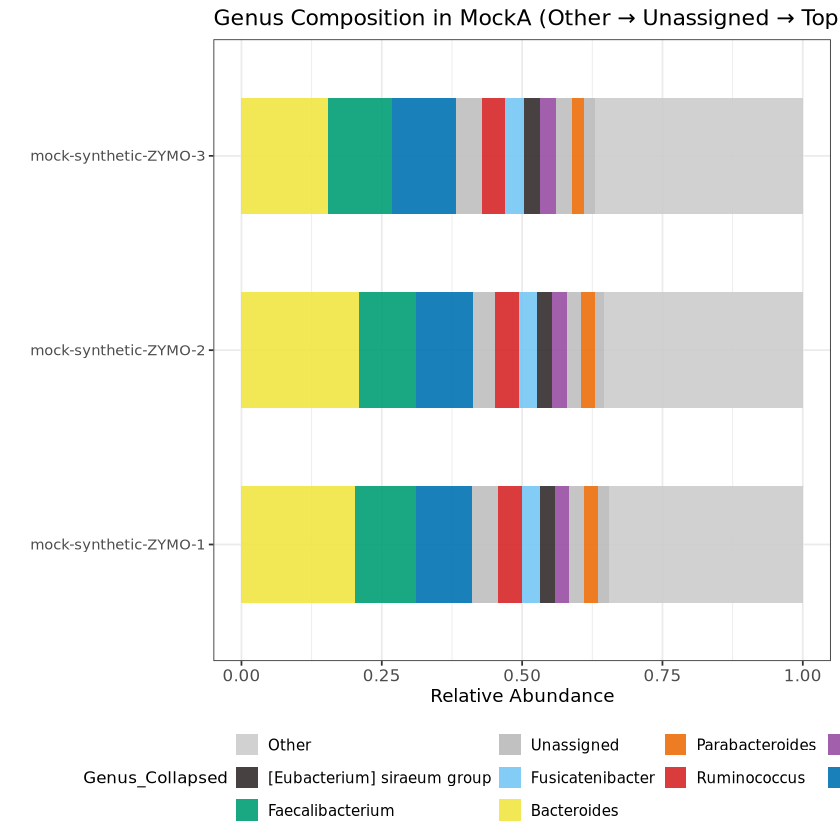

In [72]:
# 1. Clean taxonomy
tax_Mock_A <- as.data.frame(tax_table(ps.mockA))
tax_Mock_A$Genus <- as.character(tax_Mock_A$Genus)
tax_Mock_A$Genus[is.na(tax_Mock_A$Genus) | tax_Mock_A$Genus == "NA"] <- "Unassigned"
tax_table(ps.mockA) <- tax_table(as.matrix(tax_Mock_A))

# 2. Aggregate to Genus
ps.genus.MockA <- tax_glom(ps.mockA, taxrank = "Genus")

# 3. Relative abundance
ps.rel.MockA <- transform_sample_counts(ps.genus.MockA, function(x) x / sum(x))

# 4. Melt
df.abund <- psmelt(ps.rel.MockA)

# 5. Calculate total abundance
genus_summary <- df.abund %>%
  group_by(Genus) %>%
  summarise(total_abundance = sum(Abundance)) %>%
  arrange(desc(total_abundance))

# 6. Define top 10 genera
top10_genus <- genus_summary$Genus[1:10]

# 7. Collapse genera
df.abund <- df.abund %>%
  mutate(Genus_Collapsed = case_when(
    Genus %in% top10_genus ~ Genus,
    Genus == "Unassigned" ~ "Unassigned",
    TRUE ~ "Other"
  ))

# 8. Define factor levels: reverse order of top 10, then Unassigned, then Other
ordered_levels <- c("Other", "Unassigned", rev(setdiff(top10_genus, c("Unassigned", "Other"))))
df.abund$Genus_Collapsed <- factor(df.abund$Genus_Collapsed, levels = ordered_levels)

# 9. Define palette
genusPalette <- c(
  "Faecalibacterium" = "#009e73",
  "Blautia" = "#0072b2",
  "Bacteroides" = "#f0e442",
  "Subdoligranulum" = "#ecb333",
  "Ruminococcus" = "#d62728",
  "Parabacteroides" = "#ec6e0b",
  "Fusicatenibacter" = "#76c6f3",
  "[Eubacterium] siraeum group" = "#332d2d",
  "Agathobacter" = "#984ea3",
  "Unassigned" = "#bababa",
  "Other" = "#cccccc"
)

# 10. Plot
p.mockA <- ggplot(df.abund, aes(x = Sample, y = Abundance, fill = Genus_Collapsed)) +
  geom_bar(stat = "identity", position = "stack", alpha = 0.9, width = 0.6) +
  scale_fill_manual(values = genusPalette, na.value = "gray") +
  theme_bw() +
  labs(
    title = "Genus Composition in MockA (Other → Unassigned → Top Genera)",
    y = "Relative Abundance", x = ""
  ) +
  coord_flip() +
  theme(
    axis.text.x = element_text(size = 10),
    axis.title.y = element_text(size = 10),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.key.size = unit(0.5, "cm"),
    legend.text = element_text(size = 9),
    legend.title = element_text(size = 10)
  ) +
  guides(fill = guide_legend(nrow = 3, byrow = TRUE))

# 11. Show plot
print(p.mockA)


In [73]:
#### 15.4 Plot sequencing depth and 16S gene copy numbers by sample types
# Extract and clean metadata
sdata_df <- as(sample_data(ps), "data.frame")

# Clean whitespace and fix Sample_Type categories
sdata_df$Sample_Type <- trimws(as.character(sdata_df$Sample_Type))

# Correct Sample_Type levels
sdata_df$Sample_Type[sdata_df$Sample_Type == "mock"] <- "Mock"
sdata_df$Sample_Type[sdata_df$Sample_Type == "feces"] <- "Feces"
sdata_df$Sample_Type[sdata_df$Sample_Type == "environmental_control"] <- "Environmental_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "extraction_control"] <- "Extraction_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "reagent_control"] <- "Reagent_Control"

# Reorder levels: "Feces", "Mock", "Reagent_Control", "Extraction_Control", "Environmental_Control"
SAMPLE_TYPES <- c("Feces", "Mock", "Reagent_Control", "Extraction_Control", "Environmental_Control")
sdata_df$Sample_Type <- factor(sdata_df$Sample_Type, levels = SAMPLE_TYPES)

# Color palette
ColorFillManual <- c(
  "Feces" = "#ff7f0e",
  "Mock" = "#2ca02c",
  "Reagent_Control" = "#d62728",
  "Extraction_Control" = "#bcbd22",
  "Environmental_Control" = "#1f77b4"
)


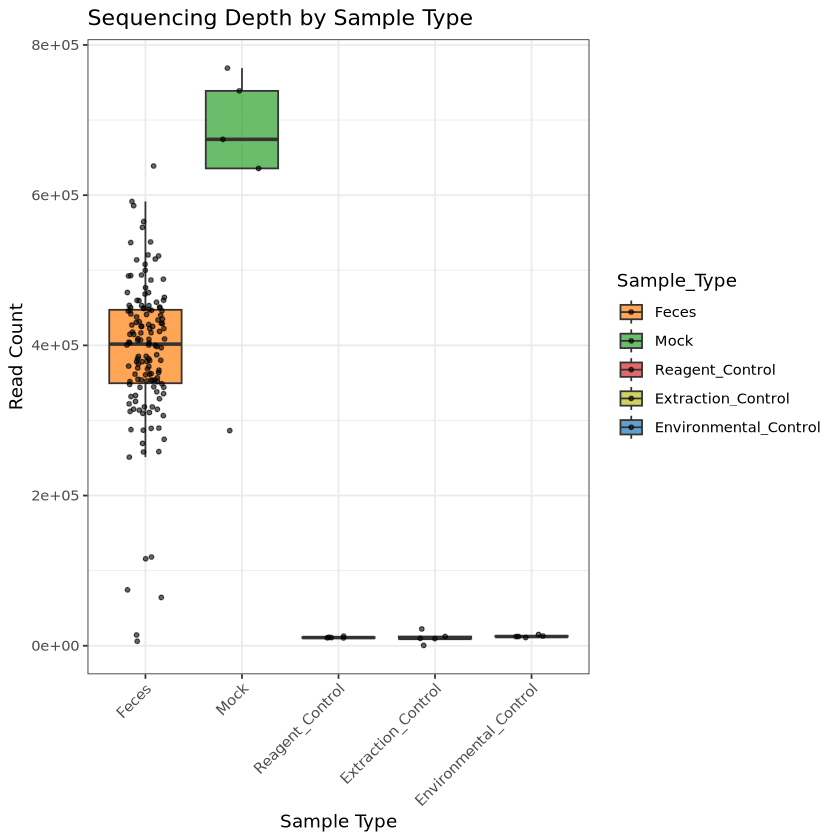

In [74]:
### Sequencing depth plot
# Add read count
sdata_df$read_count <- sample_sums(ps)

# Plot sequencing depth
p_depth <- ggplot(sdata_df, aes(x = Sample_Type, y = read_count, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = ColorFillManual) +
  labs(
    title = "Sequencing Depth by Sample Type",
    y = "Read Count",
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show plot
p_depth


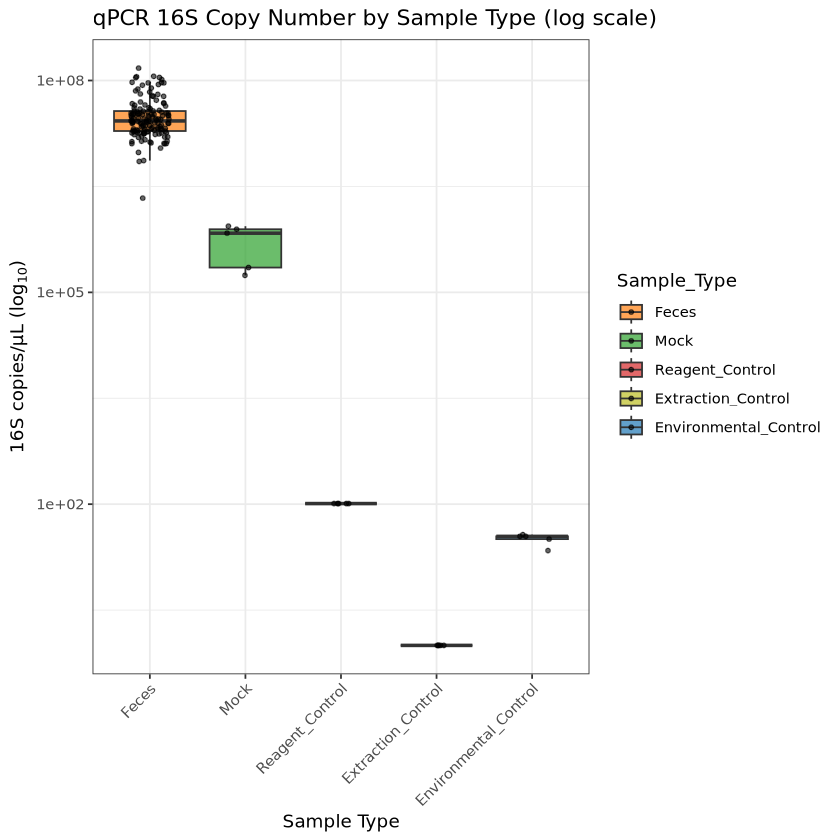

In [78]:
#### 16s Copy number
# Clean and convert qPCR copy number
sdata_df$qpcr_16s_copies_ul <- gsub(",", "", sdata_df$qpcr_16s_copies_ul)
sdata_df$qpcr_16s_copies_ul[sdata_df$qpcr_16s_copies_ul %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
sdata_df$qpcr_16s_copies_ul <- as.numeric(sdata_df$qpcr_16s_copies_ul)

# Plot qPCR copy number
p_qpcr <- ggplot(sdata_df, aes(x = Sample_Type, y = qpcr_16s_copies_ul, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, na.rm = TRUE) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6, na.rm = TRUE) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(
    title = "qPCR 16S Copy Number by Sample Type (log scale)",
    y = expression("16S copies/μL (log"[10]*")"),
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show plot
p_qpcr


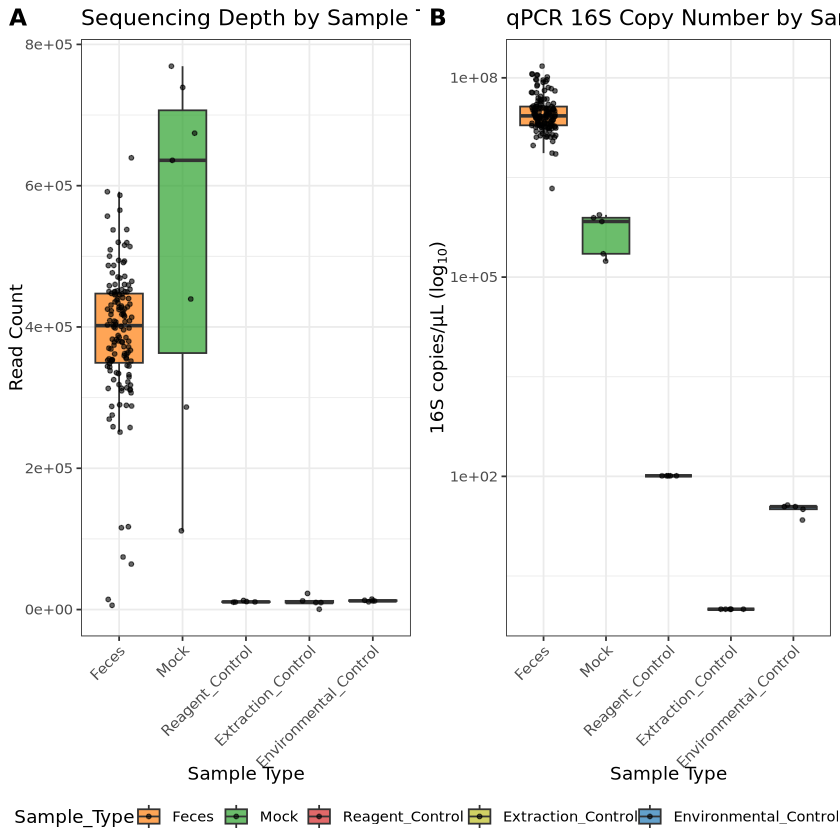

In [92]:
#### Combine plots 
library(ggpubr)

# Combine plots side-by-side
combined_plot <- ggarrange(
  p_depth, p_qpcr,
  ncol = 2,
  labels = c("A", "B"),
  common.legend = TRUE,
  legend = "bottom"
)

# Define output path
output_path <- file.path(path.figures, "SequencingDepth_qPCR_CopyNumber.png")

# Save the combined figure
ggsave(filename = output_path, plot = combined_plot,
       width = 12, height = 6, dpi = 300)

# Also display the plot in the viewer
combined_plot


In [75]:
#### 16s Copy number
# Clean and convert qPCR copy number into a new column
sdata_df$CopyNumber <- gsub(",", "", sdata_df$qpcr_16s_copies_ul)
sdata_df$CopyNumber[sdata_df$CopyNumber %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
sdata_df$CopyNumber <- as.numeric(sdata_df$CopyNumber)


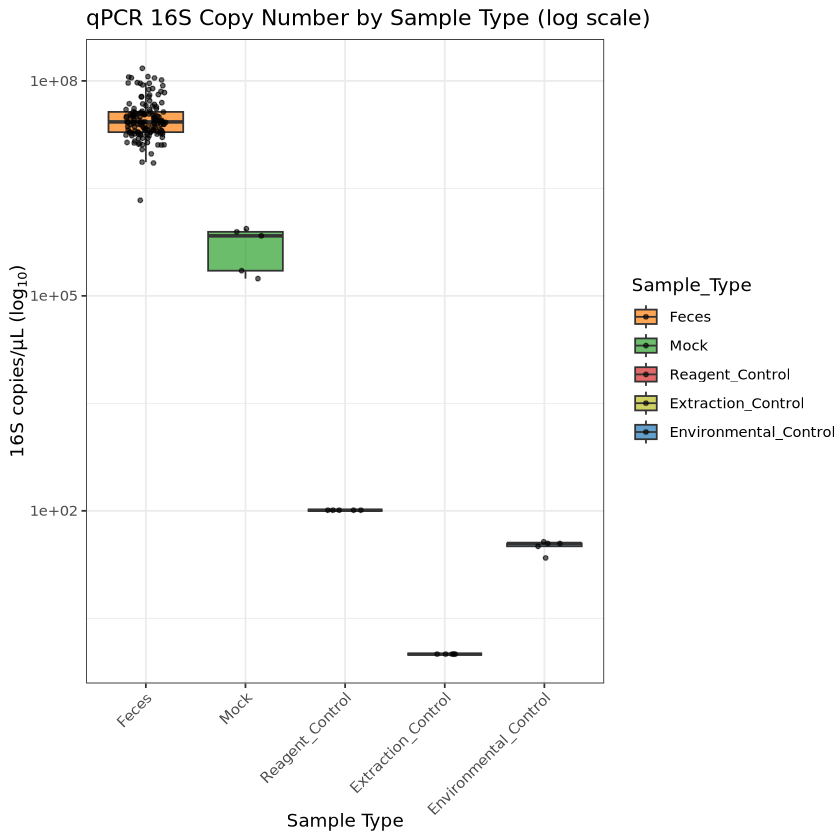

In [95]:
# Filter for valid values only
plot_data <- sdata_df[!is.na(sdata_df$CopyNumber), ]

# Plot qPCR copy number
p_qpcr <- ggplot(plot_data, aes(x = Sample_Type, y = CopyNumber, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(
    title = "qPCR 16S Copy Number by Sample Type (log scale)",
    y = expression("16S copies/μL (log"[10]*")"),
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Show plot
p_qpcr


In [80]:
library(ggplot2)
library(dplyr)
library(emmeans)
library(car)
library(ggpubr)

# --------- 1. Clean metadata ---------
sdata_df <- as(sample_data(ps), "data.frame")

# Clean Sample_Type
sdata_df$Sample_Type <- trimws(as.character(sdata_df$Sample_Type))
sdata_df$Sample_Type[sdata_df$Sample_Type == "mock"] <- "Mock"
sdata_df$Sample_Type[sdata_df$Sample_Type == "feces"] <- "Feces"
sdata_df$Sample_Type[sdata_df$Sample_Type == "environmental_control"] <- "Environmental_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "extraction_control"] <- "Extraction_Control"
sdata_df$Sample_Type[sdata_df$Sample_Type == "reagent_control"] <- "Reagent_Control"

# Set Sample_Type as factor with desired order
SAMPLE_TYPES <- c("Feces", "Mock", "Reagent_Control", "Extraction_Control", "Environmental_Control")
sdata_df$Sample_Type <- factor(sdata_df$Sample_Type, levels = SAMPLE_TYPES)

# --------- 2. Add sequencing depth ---------
sdata_df$read_count <- sample_sums(ps)

# --------- 3. Clean and create CopyNumber ---------
sdata_df$CopyNumber <- gsub(",", "", sdata_df$qpcr_16s_copies_ul)
sdata_df$CopyNumber[sdata_df$CopyNumber %in% c("ND", "NaN", "NA", "", "Undetermined")] <- NA
sdata_df$CopyNumber <- as.numeric(sdata_df$CopyNumber)

# --------- 4. Color palette ---------
ColorFillManual <- c(
  "Feces" = "#ff7f0e",
  "Mock" = "#2ca02c",
  "Reagent_Control" = "#d62728",
  "Extraction_Control" = "#bcbd22",
  "Environmental_Control" = "#1f77b4"
)

# --------- 5. Plot 1: Sequencing Depth ---------
p_depth <- ggplot(sdata_df, aes(x = Sample_Type, y = read_count, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, na.rm = TRUE) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6, na.rm = TRUE) +
  scale_fill_manual(values = ColorFillManual) +
  labs(
    title = "Sequencing Depth by Sample Type",
    y = "Read Count",
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --------- 6. Plot 2: qPCR 16S Copy Number (log10 scale) ---------
plot_qpcr_df <- sdata_df[!is.na(sdata_df$CopyNumber), ]

p_qpcr <- ggplot(plot_qpcr_df, aes(x = Sample_Type, y = CopyNumber, fill = Sample_Type)) +
  geom_boxplot(outlier.shape = NA, alpha = 0.7, na.rm = TRUE) +
  geom_jitter(width = 0.2, size = 1, alpha = 0.6, na.rm = TRUE) +
  scale_fill_manual(values = ColorFillManual) +
  scale_y_log10() +
  labs(
    title = "qPCR 16S Copy Number by Sample Type (log scale)",
    y = expression("16S copies/μL (log"[10]*")"),
    x = "Sample Type"
  ) +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# --------- 7. Save Combined Plot ---------
combined_plot <- ggarrange(
  p_depth, p_qpcr,
  ncol = 2,
  labels = c("A", "B"),
  common.legend = TRUE,
  legend = "bottom"
)

# Set output path
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
ggsave(file.path(path.figures, "SequencingDepth_16S_CopyNumber.png"), plot = combined_plot,
       width = 12, height = 6, dpi = 300)

# --------- 8. Statistical analysis ---------
# GLM on log-transformed CopyNumber
glm.sample.CopyN <- glm(log(CopyNumber) ~ Sample_Type, data = plot_qpcr_df)

# Model summary
summary(glm.sample.CopyN)

# ANOVA
car::Anova(glm.sample.CopyN)

# Pairwise comparisons
emmeans::emmeans(glm.sample.CopyN, pairwise ~ Sample_Type)


Warning message:
“package ‘emmeans’ was built under R version 4.4.3”
Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode





Call:
glm(formula = log(CopyNumber) ~ Sample_Type, data = plot_qpcr_df)

Coefficients:
                                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)                       17.16794    0.05079  338.05   <2e-16 ***
Sample_TypeMock                   -4.15378    0.27537  -15.08   <2e-16 ***
Sample_TypeReagent_Control       -12.54297    0.27537  -45.55   <2e-16 ***
Sample_TypeExtraction_Control    -17.16794    0.27537  -62.34   <2e-16 ***
Sample_TypeEnvironmental_Control -13.71226    0.27537  -49.80   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 0.3662466)

    Null deviance: 2994.905  on 161  degrees of freedom
Residual deviance:   57.501  on 157  degrees of freedom
AIC: 303.94

Number of Fisher Scoring iterations: 2


,LR Chisq,Df,Pr(>Chisq)
,<dbl>,<dbl>,<dbl>
Sample_Type,8020.292,4,0


$emmeans
 Sample_Type           emmean     SE  df lower.CL upper.CL
 Feces                  17.17 0.0508 157   17.068   17.268
 Mock                   13.01 0.2710 157   12.480   13.549
 Reagent_Control         4.62 0.2710 157    4.090    5.160
 Extraction_Control      0.00 0.2710 157   -0.535    0.535
 Environmental_Control   3.46 0.2710 157    2.921    3.990

Results are given on the log (not the response) scale. 
Confidence level used: 0.95 

$contrasts
 contrast                                   estimate    SE  df t.ratio p.value
 Feces - Mock                                   4.15 0.275 157  15.084  <.0001
 Feces - Reagent_Control                       12.54 0.275 157  45.550  <.0001
 Feces - Extraction_Control                    17.17 0.275 157  62.345  <.0001
 Feces - Environmental_Control                 13.71 0.275 157  49.796  <.0001
 Mock - Reagent_Control                         8.39 0.383 157  21.918  <.0001
 Mock - Extraction_Control                     13.01 0.383 157  34.002  <.0001
 Mock - Environmental_Control                   9.56 0.383 157  24.973  <.0001
 Reagent_Control - Extraction_Control           4.62 0.383 157  12.083  <.0001
 Reagent_Control - Environmental_Control        1.17 0.383 157   3.055  0.0219
 Extraction_Control - Environmental_Control    -3.46 0.383 157  -9.029  <.0001

Results are given on the log (not the response) scale. 
P value adjustment: tukey method for comparing a family of 5 estimates

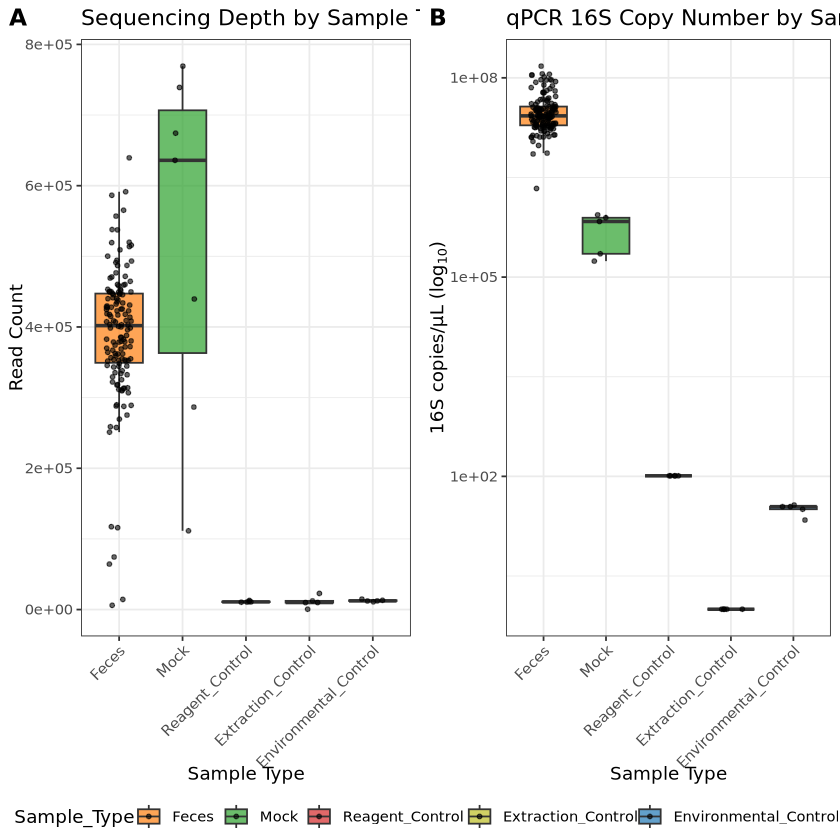

In [99]:
print(combined_plot)


In [100]:
# --- Create Output Directory ---
path.stats <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"
dir.create(path.stats, showWarnings = FALSE, recursive = TRUE)

# --- 1. GLM Coefficients Summary ---
glm_summary <- summary(glm.sample.CopyN)
glm_coef <- as.data.frame(coef(glm_summary))
glm_coef$Term <- rownames(glm_coef)
rownames(glm_coef) <- NULL
glm_coef <- glm_coef[, c("Term", "Estimate", "Std. Error", "t value", "Pr(>|t|)")]

# Round and rename
glm_coef <- glm_coef %>%
  mutate(across(where(is.numeric), ~ round(., 4)))
names(glm_coef) <- c("Coefficient", "Estimate", "Std_Error", "t_value", "p_value")

# --- 2. ANOVA Table ---
anova_results <- car::Anova(glm.sample.CopyN)
anova_df <- as.data.frame(anova_results)
anova_df$Term <- rownames(anova_df)
rownames(anova_df) <- NULL
anova_df <- anova_df[, c("Term", "LR Chisq", "Df", "Pr(>Chisq)")]

# Round and rename
anova_df <- anova_df %>%
  mutate(across(where(is.numeric), ~ signif(., 4)))
names(anova_df) <- c("Term", "LR_Chisq", "DF", "p_value")

# --- 3. Pairwise Comparisons with emmeans ---
emm <- emmeans::emmeans(glm.sample.CopyN, pairwise ~ Sample_Type)
pairwise_df <- as.data.frame(emm$contrasts)

# Round numeric columns
pairwise_df <- pairwise_df %>%
  mutate(across(where(is.numeric), ~ signif(., 4)))
names(pairwise_df)[names(pairwise_df) == "p.value"] <- "p_value"

# --- 4. Save Outputs ---
write.csv(glm_coef, file.path(path.stats, "glm_coefficients.csv"), row.names = FALSE)
write.csv(anova_df, file.path(path.stats, "glm_anova.csv"), row.names = FALSE)
write.csv(pairwise_df, file.path(path.stats, "glm_emmeans_pairwise.csv"), row.names = FALSE)


In [106]:
library(dplyr)

# Identify the correct p-value column
pval_col <- grep("^p[._]?value", colnames(pairwise_df), value = TRUE)[1]

# Clean and rename for manuscript-ready format
pairwise_df_clean <- pairwise_df %>%
  rename(p.value = all_of(pval_col)) %>%
  mutate(
    contrast = gsub(" - ", " vs. ", contrast),
    estimate = round(estimate, 2),
    SE = round(SE, 2),
    t.ratio = round(t.ratio, 2),
    p.value = signif(p.value, 3)
  ) %>%
  select(contrast, estimate, SE, t.ratio, p.value) %>%
  arrange(p.value)

# View the cleaned result
print(pairwise_df_clean)

write.csv(pairwise_df_clean, file.path(path.stats, "glm_emmeans_pairwise_cleaned.csv"), row.names = FALSE)

                                       contrast estimate   SE t.ratio  p.value
1                                Feces vs. Mock     4.15 0.28   15.08 9.42e-14
2                     Feces vs. Reagent_Control    12.54 0.28   45.55 9.42e-14
3                  Feces vs. Extraction_Control    17.17 0.28   62.35 9.42e-14
4               Feces vs. Environmental_Control    13.71 0.28   49.80 9.42e-14
5                      Mock vs. Reagent_Control     8.39 0.38   21.92 9.42e-14
6                   Mock vs. Extraction_Control    13.01 0.38   34.00 9.42e-14
7                Mock vs. Environmental_Control     9.56 0.38   24.97 9.42e-14
8        Reagent_Control vs. Extraction_Control     4.62 0.38   12.08 9.86e-14
9  Extraction_Control vs. Environmental_Control    -3.46 0.38   -9.03 1.46e-13
10    Reagent_Control vs. Environmental_Control     1.17 0.38    3.06 2.19e-02


In [76]:
####Decontam and sourcetracker
### 1. Load Required Libraries
library(decontam)
library(dplyr)
library(ggplot2)
library(phyloseq)
library(ggpubr)
library(pairwiseAdonis)
library(patchwork)
library(microbiome)

In [77]:
### 2. Define Sample Types and Paths

TYPE <- c("Feces")
path.rds <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"
path.stats <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/stats"

In [81]:
### 3. Load Phyloseq Object

ps <- readRDS(file.path(path.rds, "phyloseq.rds"))
ps
ps.mock <- readRDS(file.path(path.rds, "ps.mock.rds"))
ps.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23387 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 23387 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 23387 reference sequences ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 1358 taxa and 5 samples ]
sample_data() Sample Data:       [ 5 samples by 65 sample variables ]
tax_table()   Taxonomy Table:    [ 1358 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 1358 reference sequences ]

In [82]:
### Check the tax_table aspect of the phyloseq object:
colnames(tax_table(ps))

[1] "Kingdom" "Phylum"  "Class"   "Order"   "Family"  "Genus"   "Species"

In [83]:
tax_df <- as.data.frame(tax_table(ps))

In [88]:
### Metadata preparation

# Convert phyloseq sample_data to data.frame with mock included
samp_df <- as.data.frame(sample_data(ps))

# Clean whitespace in Sample_Type
samp_df$Sample_Type <- trimws(samp_df$Sample_Type)

# Initialize SampleOrControl as 'Sample'
samp_df$SampleOrControl <- "Sample"

# Set to 'Control' only for real control types
samp_df$SampleOrControl[samp_df$Sample_Type %in% c("Environmental_Control", "Extraction_Control", "Reagent_Control")] <- "Control"

# Check what's being classified
table(samp_df$SampleOrControl, samp_df$Sample_Type)

# Assign CopyNumber from external metadata (meta) matching sample names
samp_df$CopyNumber <- meta[rownames(samp_df), "CopyNumber"]

# Ensure CopyNumber is numeric (already done, but safe)
samp_df$CopyNumber <- as.numeric(samp_df$CopyNumber)

# Write back to phyloseq sample_data
sample_data(ps) <- sample_data(samp_df)

# Now subset to exclude controls (Mock is retained as 'Sample')
ps.samples <- subset_samples(ps, SampleOrControl == "Sample")
ps.samples <- prune_taxa(taxa_sums(ps.samples) > 0, ps.samples)


         
          Environmental_Control Extraction_Control Feces Mock_A Mock_B
  Control                     5                  5     0      0      0
  Sample                      0                  0   142      3      2
         
          Reagent_Control
  Control               5
  Sample                0

In [89]:
# Replace specific Sample_Type entries
meta$Sample_Type[meta$Sample_ID %in% c("ZYMO-1", "ZYMO-2", "ZYMO-3")] <- "Mock_A"
meta$Sample_Type[meta$Sample_ID %in% c("ZYMO-4", "ZYMO-5")] <- "Mock_B"

# Reassign the updated metadata back to the phyloseq object
sample_data(ps) <- meta

In [94]:
#### Frequency method 
# Prepare data for 'frequency' method
# 1. phyloseq object without positive controls
exclude_mock <- c("Mock_A", "Mock_B")
ps.samples.wo.mock <- subset_samples(ps, !Sample_Type %in% exclude_mock) 
ps.samples.wo.mock <- prune_taxa(taxa_sums(ps.samples.wo.mock) > 0, ps.samples.wo.mock) # remove taxa with no counts
ps.samples.wo.mock #Removed mock samples, kept feces + negative controls

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22215 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 66 sample variables ]
tax_table()   Taxonomy Table:    [ 22215 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 22215 reference sequences ]

In [95]:
# Remove negative control samples 
# 2. phyloseq object without negative controls
exclude_controls <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")
ps.samples.wo.controls <- subset_samples(ps, !Sample_Type %in% exclude_controls) 
ps.samples.wo.controls <- prune_taxa(taxa_sums(ps.samples.wo.controls) > 0, ps.samples.wo.controls) # remove taxa with no counts
ps.samples.wo.controls #Removed negative controls, kept feces + mocks

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22262 taxa and 147 samples ]
sample_data() Sample Data:       [ 147 samples by 66 sample variables ]
tax_table()   Taxonomy Table:    [ 22262 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 22262 reference sequences ]

In [96]:
# Remove positive control samples ("MockA and MockB" ) and negative controls
exclude_mock <- c("Mock_A", "Mock_B")
ps.samples.wo.controls.mock <- subset_samples(ps.samples.wo.controls, !Sample_Type %in% exclude_mock) 
ps.samples.wo.controls.mock <- prune_taxa(taxa_sums(ps.samples.wo.controls.mock) > 0, ps.samples.wo.controls.mock) # remove taxa with no counts
ps.samples.wo.controls.mock #Final clean: only true feces samples — no mocks, no controls

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21062 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 66 sample variables ]
tax_table()   Taxonomy Table:    [ 21062 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 21062 reference sequences ]

In [97]:
# List of phyloseq objects
phylo_list <- list(
  ps = ps,
  ps.samples = ps.samples,
  ps.samples.filtered = ps.samples.filtered,
  ps.samples.wo.mock = ps.samples.wo.mock,
  ps.samples.wo.controls = ps.samples.wo.controls,
  ps.samples.wo.controls.mock = ps.samples.wo.controls.mock
)

# Build summary table
phylo_summary <- lapply(names(phylo_list), function(name) {
  obj <- phylo_list[[name]]
  data.frame(
    Object_Name = name,
    Num_Samples = nsamples(obj),
    Num_Taxa = ntaxa(obj),
    Unique_SampleTypes = paste(unique(sample_data(obj)$Sample_Type), collapse = "; "),
    stringsAsFactors = FALSE
  )
})

phylo_summary_df <- do.call(rbind, phylo_summary)

# Save as CSV
write.csv(
  phylo_summary_df,
  file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phyloseq_object_auto_summary.csv",
  row.names = FALSE
)


In [104]:
# Run frequency method

# Check the format of the qPCR values: remove the commas and convert the qpcr_16s_copies_ul column to numeric format in R
meta <- as.data.frame(sample_data(ps.samples.wo.controls.mock))
meta$qpcr_16s_copies_ul <- as.numeric(gsub(",", "", meta$qpcr_16s_copies_ul))
sample_data(ps.samples.wo.controls.mock) <- meta # Reassign cleaned metadata back to phyloseq object

# Run Method:
contamdf.freq <- isContaminant(ps.samples.wo.controls.mock, 
                               method="frequency", 
                               conc="qpcr_16s_copies_ul", 
                               threshold = 0.5) # DNA concentration is stored in the qpcr_16s_copies_ul column
# View summary
table(contamdf.freq$contaminant)



FALSE  TRUE 
19138  1924 

In [106]:
# # Extract ASV names flagged as contaminants (TRUE)
write.csv(data.frame(ASV_Sequence = contaminant_asvs),
          file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv",
          row.names = FALSE, quote = FALSE)


In [107]:
contam_feature_indices <- which(contamdf.freq$contaminant == TRUE)
head(contam_feature_indices)

[1]   6   7  97 120 125 154

In [108]:
# Select contaminants from otu table
contam_seq_freq <- rownames(contamdf.freq[contamdf.freq$contaminant == "TRUE",])

contamdf.freqMod <- contamdf.freq %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
 ifelse(prev > 2 & prev <= 5, "3-5",
 ifelse(prev >= 6 & prev <= 10, "6-10", "11+"))) )

contamdf.freqMod$Prevalence <- factor(contamdf.freqMod$Prevalence, levels = c("2", "3-5", "6-10", "11+"))

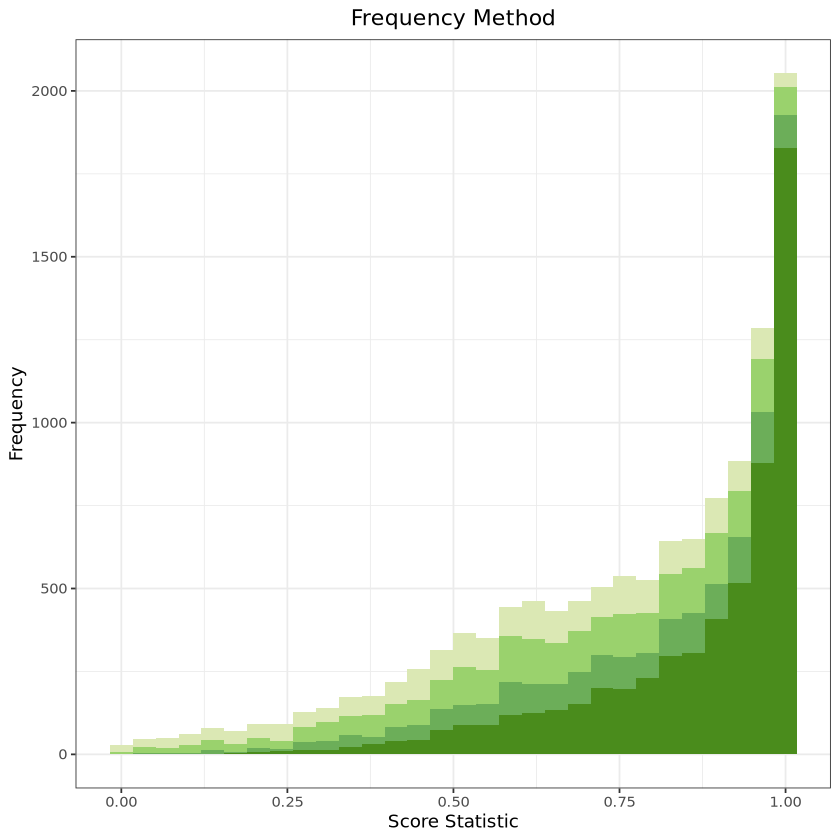

In [109]:
### Plot Score statistics for frequency method
# Set up:
theme_set(theme_bw())
 # Part of the Area Green Tableau color palette (Version 9.x)
 # Similar to Davis et al., (2018)
scaleColorFillManualFrequency <-
 scale_fill_manual(
 values =
 c(
 "2" = "#dbe8b4",
 "3-5" = "#9ad26d",
 "6-10" = "#6cae59",
 "11+" = "#4a8c1c"
 )
 )
# Plot score statistics output
freqScorePlot <- ggplot(contamdf.freqMod, aes(x = p, fill = Prevalence)) +
 geom_histogram(bins = 30) +
 scaleColorFillManualFrequency +
 ggtitle("Frequency Method") +
 xlab("Score Statistic") +
 ylab("Frequency") +
 theme(
 plot.title = element_text(hjust = 0.5),
 legend.position = "none")
print(freqScorePlot)

In [110]:
### Prevalence method for all the sample (Sample + Mock + Controls)

# Prepare data for 'prevalence' method. 
sample_data(ps)$is.neg <- sample_data(ps)$Sample_Type %in% c("Environmental_Control", "Extraction_Control", "Reagent_Control")
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable
contamdf.prev <- isContaminant(ps, method="prevalence", neg="is.neg", threshold=0.5)
table(contamdf.prev$contaminant)


FALSE  TRUE 
22904   483 

In [111]:
contam_feature_indices_prev <- which(contamdf.prev$contaminant == TRUE)
head(contam_feature_indices_prev)

[1]  813 1953 2159 2962 3061 3108

In [113]:
# Extract ASVs flagged as contaminants
asv.prev <- rownames(contamdf.prev)[contamdf.prev$contaminant == TRUE]

# Save contaminant ASVs detected in prevalence method
write.csv(
  data.frame(ASV_Sequence = asv.prev),
  file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence_all_sample.csv",
  row.names = FALSE,
  quote = FALSE
)

In [114]:
# 1. Load the contaminant ASVs from both methods
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence_all_sample.csv", stringsAsFactors = FALSE)

# 2. Clean up column names if necessary (make sure both have same column: ASV_Sequence)
colnames(asv.freq) <- "ASV_Sequence"
colnames(asv.prev) <- "ASV_Sequence"

# 3. Trim any extra spaces from sequences (prevent mismatches)
asv.freq$ASV_Sequence <- trimws(asv.freq$ASV_Sequence)
asv.prev$ASV_Sequence <- trimws(asv.prev$ASV_Sequence)

# 4. Find intersecting ASVs
common.asvs <- intersect(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence)

# 5. Summary table
summary_overlap <- data.frame(
  Category = c("Frequency Only", "Prevalence Only", "Both"),
  Num_ASVs = c(
    length(setdiff(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence)),
    length(setdiff(asv.prev$ASV_Sequence, asv.freq$ASV_Sequence)),
    length(common.asvs)
  )
)

# 6. View summary
print(summary_overlap)

# 7. Save overlap if needed
write.csv(data.frame(ASV_Sequence = common.asvs),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/common_asvs_prevalence_frequency.csv",
          row.names = FALSE, quote = FALSE)


         Category Num_ASVs
1  Frequency Only     1889
2 Prevalence Only      448
3            Both       35


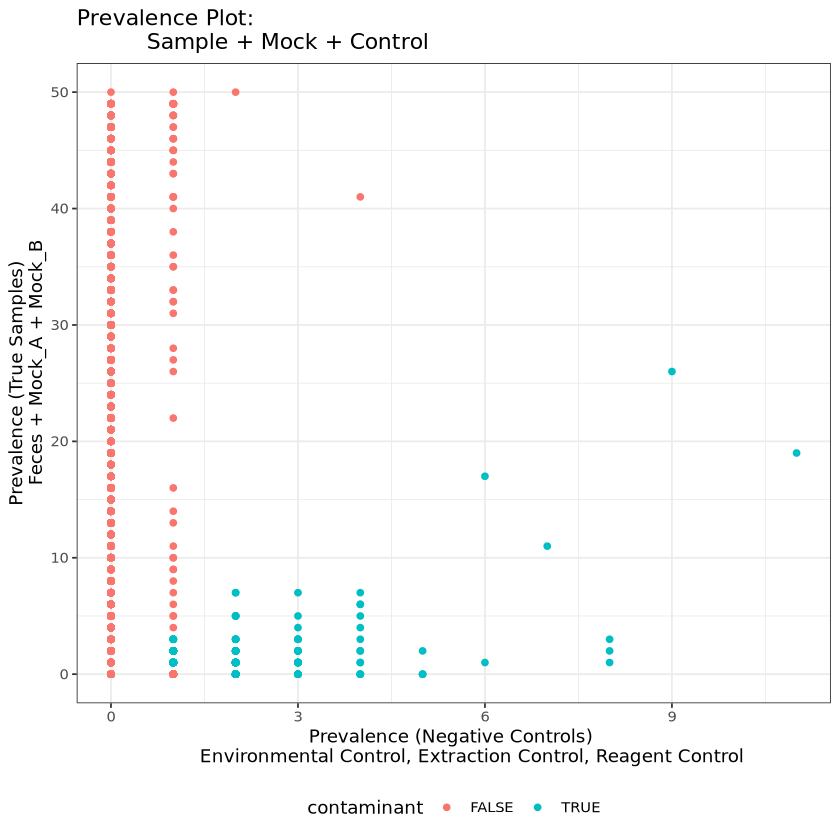

In [117]:
# Plot presence-absence in negative controls and true samples (Feces and Mock)
ps.pa <- transform_sample_counts(
  ps, 
  function(abund) 1*(abund>0))

ps.pa.neg <- prune_samples(
  sample_data(ps.pa)$Sample_Type %in% c(
    "Environmental_Control",
    "Extraction_Control", 
    "Reagent_Control"), 
  ps.pa)

ps.pa.pos <- prune_samples(
  sample_data(
    ps.pa)$Sample_Type == c(
      "Feces", "Mock_A", "Mock_B"), ps.pa)



# Make data.frame of prevalence in positive and negative samples
df.pa <- data.frame(
  pa.pos=taxa_sums(ps.pa.pos), 
  pa.neg=taxa_sums(ps.pa.neg),
  contaminant=contamdf.prev$contaminant)

pa.plot <- ggplot(data=df.pa, 
                  aes(x=pa.neg, 
                      y=pa.pos, 
                      color=contaminant)) + geom_point() +
  theme(legend.position = "bottom")+
  xlab("Prevalence (Negative Controls) 
      Environmental Control, Extraction Control, Reagent Control") +
  ylab("Prevalence (True Samples)
       Feces + Mock_A + Mock_B") +
  ggtitle("Prevalence Plot: 
          Sample + Mock + Control")

print(pa.plot)


In [118]:
## Prevalence method for Sample + Controls
# Plot of presence-absence in negative controls and true samples (Feces)
ps.pa.wo.mock <- transform_sample_counts(ps, function(abund) 1*(abund>0))

ps.pa.neg.wo.mock <- prune_samples(sample_data(ps.pa.wo.mock)$Sample_Type %in% c("Environmental_Control",
                                                                                 "Extraction_Control",
                                                                                 "Reagent_Control"), 
                                   ps.pa.wo.mock)
ps.pa.neg.wo.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23387 taxa and 15 samples ]
sample_data() Sample Data:       [ 15 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 23387 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 23387 reference sequences ]

In [120]:
ps.pa.pos.wo.mock <- prune_samples(sample_data(ps.pa.wo.mock)$Sample_Type == c("Feces"), ps.pa.wo.mock)
ps.pa.pos.wo.mock

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23387 taxa and 142 samples ]
sample_data() Sample Data:       [ 142 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 23387 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 23387 reference sequences ]

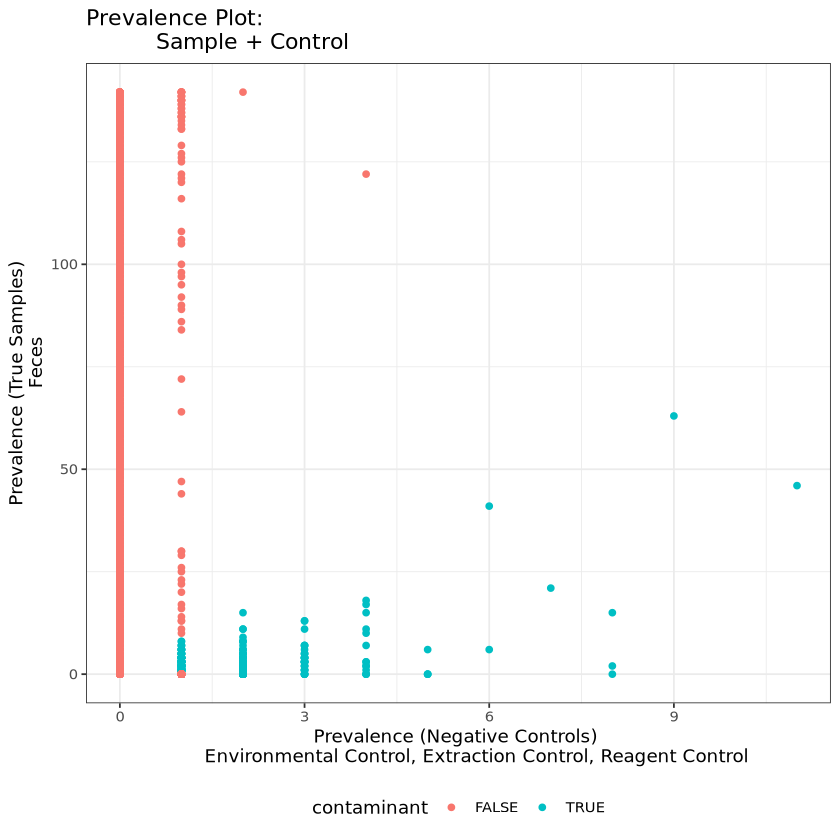

In [121]:
# Make data.frame of prevalence in positive and negative samples
df.pa.wo.mock <- data.frame(
  pa.pos.wo.mock=taxa_sums(ps.pa.pos.wo.mock), 
  pa.neg.wo.mock=taxa_sums(ps.pa.neg.wo.mock),
  contaminant=contamdf.prev$contaminant)

pa.plot.wo.mock <- ggplot(
  data=df.pa.wo.mock, 
  aes(x=pa.neg.wo.mock, 
      y=pa.pos.wo.mock, 
      color=contaminant)) +
  geom_point() +
  theme(legend.position = "bottom")+
  xlab("Prevalence (Negative Controls) 
      Environmental Control, Extraction Control, Reagent Control") +
  ylab("Prevalence (True Samples)
       Feces") +
  ggtitle("Prevalence Plot: 
          Sample + Control")
pa.plot.wo.mock

In [122]:
### Prevalence-Based Detection: Extraction Control

#Prepare data for 'prevalence' method, without "Extraction control" is control

ps.no.extraction <- subset_samples(ps, Sample_Type != "Extraction_Control") # remove extraction samples
ps.no.extraction <- prune_taxa(taxa_sums(ps.no.extraction) > 0, ps.no.extraction) # remove taxa with no counts
ps.no.extraction

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23099 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 23099 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 23099 reference sequences ]

In [123]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.extraction <- isContaminant(ps.no.extraction, 
                                          method="prevalence", 
                                          neg="is.neg", 
                                          threshold=0.5)

table(contamdf.prev.extraction$contaminant)


FALSE  TRUE 
22730   369 

In [126]:
# Extract ASVs flagged as contaminants from Extraction control
asv.prev.extraction <- rownames(contamdf.prev.extraction)[contamdf.prev.extraction$contaminant == TRUE]

# Save to CSV
write.csv(
  data.frame(ASV_Sequence = asv.prev.extraction),
  file = file.path(output_dir, "contaminant_asvs_prevalence_extraction_only.csv"),
  row.names = FALSE,
  quote = FALSE
)

In [127]:
# Identify contaminant feature indices:
contam_feature_indices_prev_extraction <- which(
  contamdf.prev.extraction$contaminant == TRUE)

head(contam_feature_indices_prev_extraction) 

[1] 2159 2962 3061 3108 3882 4045

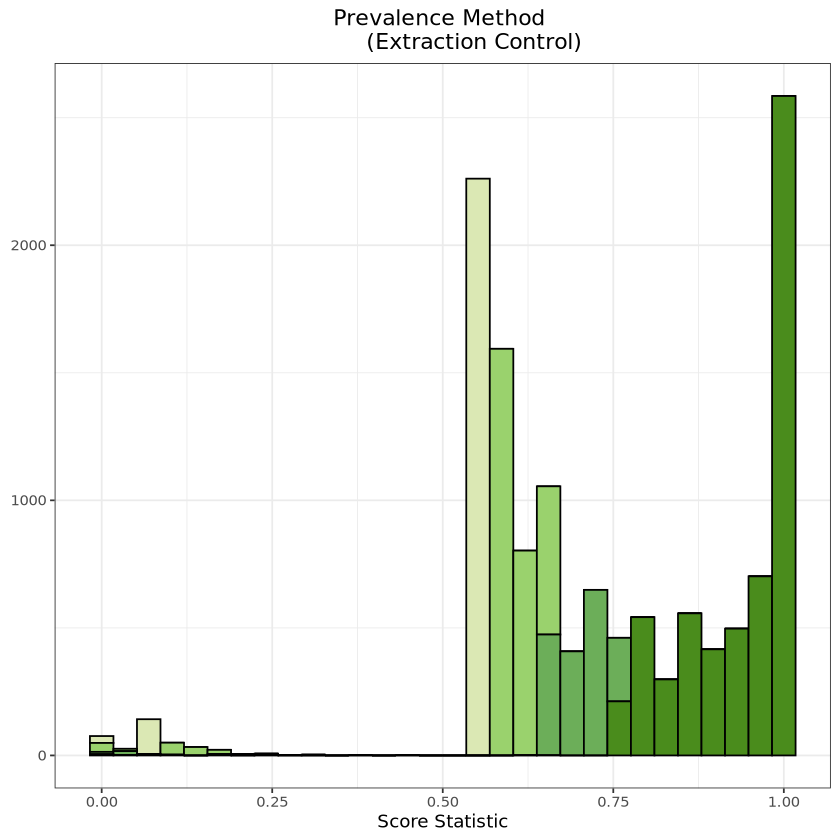

In [128]:
# Plot Extraction Control Score
contamdf.prev.extractionMod <- contamdf.prev.extraction %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
 ifelse(prev > 2 & prev <= 5, "3-5",
 ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
 )


contamdf.prev.extractionMod$Prevalence <- factor(
  contamdf.prev.extractionMod$Prevalence, 
  levels = c("2", "3-5", "6-10", "11+"))


prev.ExtractionScorePlot <- ggplot(
  contamdf.prev.extractionMod, 
  aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method 
         (Extraction Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
    )

prev.ExtractionScorePlot

In [129]:
#select seq names of contaminants identified by prevalence method using extraction as control
contam_seq_prev_extraction <- rownames(contamdf.prev.extraction[contamdf.prev.extraction$contaminant == "TRUE",])

In [130]:
### Prevalence-Based Detection: Reagent Control

#Prepare data for 'prevalence' method, "Reagent control" is control

ps.no.reagent <- subset_samples(ps, Sample_Type != "Reagent_Control") # remove extraction samples
ps.no.reagent <- prune_taxa(taxa_sums(ps.no.reagent) > 0, ps.no.reagent) # remove taxa with no counts
ps.no.reagent

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 23020 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 23020 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 23020 reference sequences ]

In [131]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable

contamdf.prev.reagent <- isContaminant(ps.no.reagent, method="prevalence", neg="is.neg", threshold=0.5)

table(contamdf.prev.reagent$contaminant)


FALSE  TRUE 
22671   349 

In [132]:
# Extract ASVs flagged as contaminants from Reagent Control
asv.prev.reagent <- rownames(contamdf.prev.reagent)[contamdf.prev.reagent$contaminant == TRUE]

# Save to CSV
write.csv(
  data.frame(ASV_Sequence = asv.prev.reagent),
  file = file.path(output_dir, "contaminant_asvs_prevalence_reagent_only.csv"),
  row.names = FALSE,
  quote = FALSE
) 

In [133]:
# Identify contaminant feature indices:
contam_feature_indices_prev_reagent <- which(contamdf.prev.reagent$contaminant == TRUE)
head(contam_feature_indices_prev_reagent)

[1]  813 1953 2159 2962 3061 3067

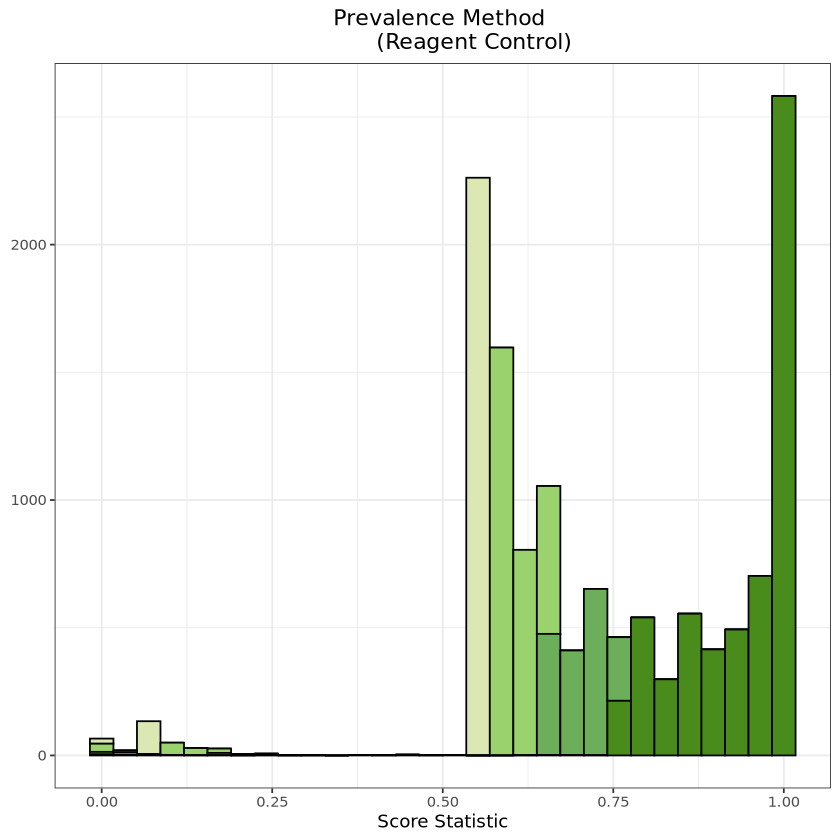

In [134]:
# Plot Reagent Control Score

# Filter to keep only taxa with prevalence > 1 and categorize prevalence into bins
contamdf.prev.reagentMod <- contamdf.prev.reagent %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
                            ifelse(prev > 2 & prev <= 5, "3-5",
                                   ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
 )

# Make sure the prevalence factor has the right order
contamdf.prev.reagentMod$Prevalence <- factor(
  contamdf.prev.reagentMod$Prevalence, 
  levels = c("2", "3-5", "6-10", "11+"))

# Plot histogram of the score statistic 'p' colored by prevalence category
prev.reagentScorePlot <- ggplot(
  contamdf.prev.reagentMod, 
  aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method 
         (Reagent Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
 )
prev.reagentScorePlot

In [136]:
# Select seq names of contaminants identified by prevalence method using reagent as control
contam_seq_prev_reagent <- rownames(contamdf.prev.reagent)[contamdf.prev.reagent$contaminant == "TRUE"]

In [137]:
### Prevalence-Based Detection: Environment Control

#Prepare data for 'prevalence' method, without "Extraction control" is control 
ps.no.Environment  <- subset_samples(ps, Sample_Type != "Environmental_Control")  # remove extraction samples 

ps.no.Environment  <- prune_taxa(taxa_sums(ps.no.Environment) > 0, ps.no.Environment) # remove taxa with no counts 
ps.no.Environment

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 22947 taxa and 157 samples ]
sample_data() Sample Data:       [ 157 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 22947 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 22947 reference sequences ]

In [138]:
# Run 'prevalence' method
# Information about whether the sample ir a control or true sample is stored in 'is.neg' variable  

contamdf.prev.Environment <- isContaminant(
  ps.no.Environment, 
  method="prevalence", 
  neg="is.neg", 
  threshold=0.5)  

table(contamdf.prev.Environment$contaminant)  


FALSE  TRUE 
22612   335 

In [142]:
# Extract ASVs flagged as contaminants from Environmental Control
asv.prev.Environment <- rownames(contamdf.prev.Environment)[contamdf.prev.Environment$contaminant == TRUE]

# Save to CSV
write.csv(
  data.frame(ASV_Sequence = asv.prev.Environment),
  file = file.path(output_dir, "contaminant_asvs_prevalence_Environment_only.csv"),
  row.names = FALSE,
  quote = FALSE
)

In [143]:
# Identify contaminant feature indices:
contam_feature_indices_prev_Environment <- which(contamdf.prev.Environment$contaminant == TRUE) 

head(contam_feature_indices_prev_Environment)

[1]  813 1953 2159 2962 3061 3067

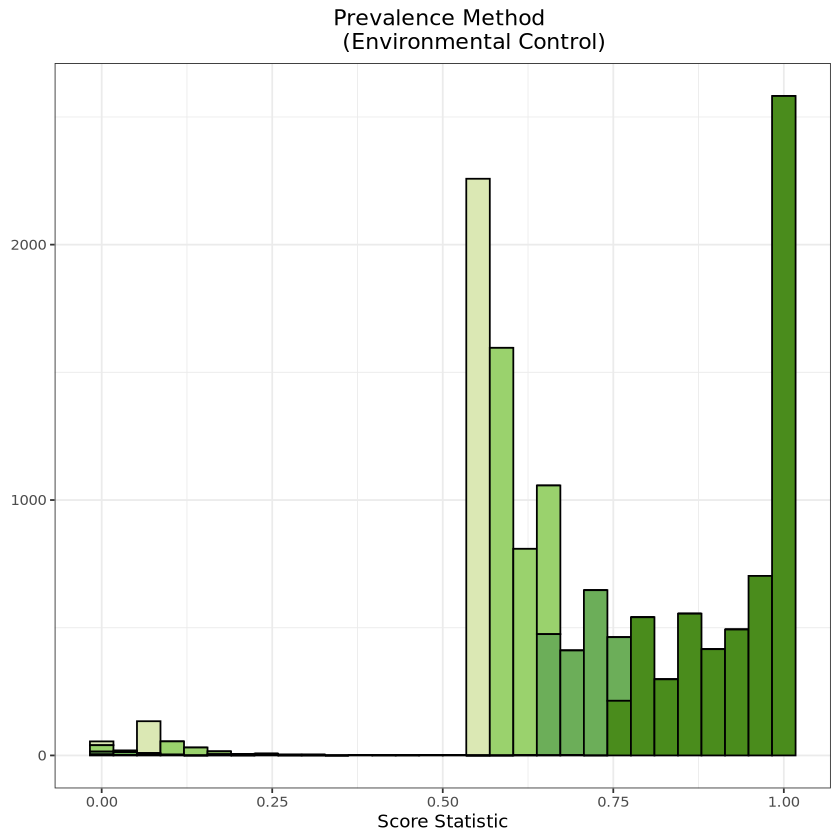

In [144]:
# Plot Environment Control Score 

# Filter to keep only taxa with prevalence > 1 and categorize prevalence into bins
contamdf.prev.EnvironmentMod <- contamdf.prev.Environment %>%
 filter(prev > 1) %>%
 mutate(Prevalence = ifelse(prev == 2, "2",
                            ifelse(prev > 2 & prev <= 5, "3-5",
                                   ifelse(prev >= 6 & prev <= 10, "6-10", "11+")))
 )

# Make sure the prevalence factor has the right order
contamdf.prev.EnvironmentMod$Prevalence <- factor(
  contamdf.prev.EnvironmentMod$Prevalence, 
  levels = c("2", "3-5", "6-10", "11+"))

# Plot histogram of the score statistic 'p' colored by prevalence category
prev.EnvironmentScorePlot <- ggplot(
  contamdf.prev.EnvironmentMod, 
  aes(x = p, fill = Prevalence)) +
  geom_histogram(bins = 30, color = "black") +
  scaleColorFillManualFrequency +
  ggtitle("Prevalence Method 
         (Environmental Control)") +
  xlab("Score Statistic") +
  ylab("Frequency") +
  theme(
    plot.title = element_text(hjust = 0.5),
    legend.position = "none",
    axis.title.y = element_blank()
 )
prev.EnvironmentScorePlot

In [145]:
#select seq names of contaminants identified by prevalence method using environmental as control
contam_seq_prev_Environment <- rownames(contamdf.prev.Environment[contamdf.prev.Environment$contaminant == "TRUE",])

In [146]:
### Phyloseq object after Decontam
# Create noncontam ps project
# Select unique seq names of contaminants identified by both frequency and prevalence methods separately
contam_seq <- c(contam_seq_freq,
                contam_seq_prev_reagent,
                contam_seq_prev_extraction,
                contam_seq_prev_Environment)

contam_seq <- unique(contam_seq)

# Create ps project after removing contaminants
allTaxa = taxa_names(ps)
Taxa.decontam <- allTaxa[!(allTaxa %in% contam_seq)]
ps.decontam <- prune_taxa(Taxa.decontam, ps)
saveRDS(ps.decontam, file.path(path.rds, "ps.decontam.rds"))
ps.contam <- prune_taxa(contam_seq, ps)
saveRDS(ps.contam, file.path(path.rds, "ps.contam.rds"))

In [147]:
# Look inside the ps.contam object

ps.contam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 2377 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 2377 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 2377 reference sequences ]

In [148]:
# Look inside the ps.decontam object

ps.decontam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21010 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 21010 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 21010 reference sequences ]

In [149]:
### Plot 16S Gene Copy vs Abundance of Contaminants

SAMPLE_TYPES <- c(
 "Feces",
 "Mock_A",
 "Mock_B",
 "Extraction_Control", 
 "Reagent_Control",
 "Environmental_Control")

my_palette<- c(
 "Feces" = "#1f77b4",
 "Mock_A" = "#9f7f3f",
 "Mock_B" = "#7f4f7f",
 "Extraction_Control" = "#ff7f0e",
 "Reagent_Control" = "#2ca02c",
 "Environmental_Control" = "#d62728")

In [151]:
#Data
readRDS(file.path(path.rds, "ps.decontam.rds"))
readRDS(file.path(path.rds, "ps.contam.rds"))

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21010 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 21010 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 21010 reference sequences ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 2377 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 2377 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 2377 reference sequences ]

`geom_smooth()` using formula = 'y ~ x'


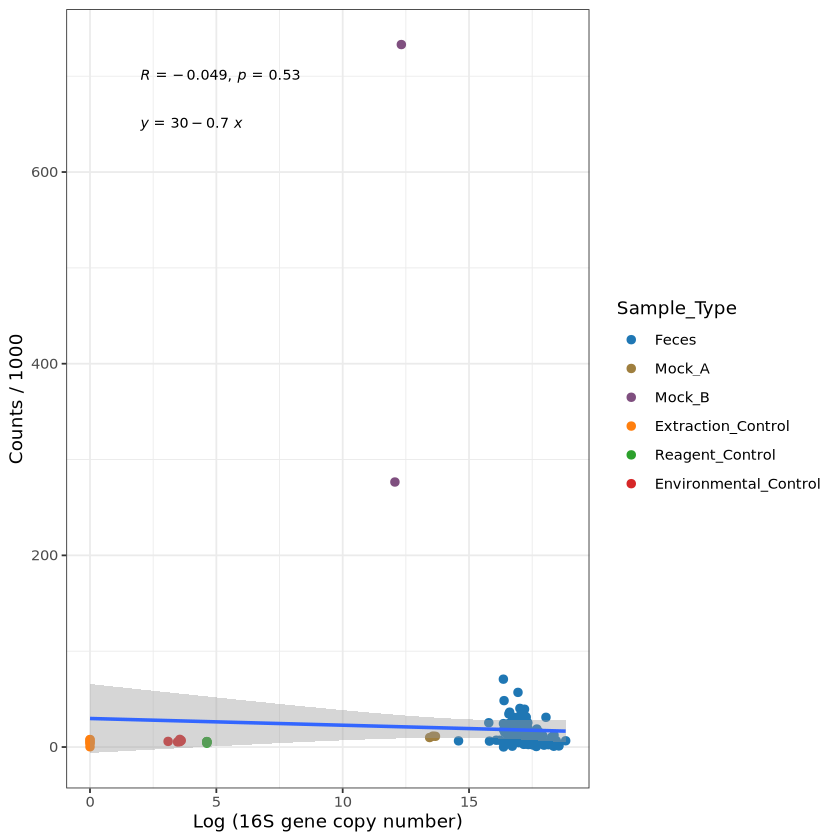

In [152]:
metadata_contam <- data.frame(sample_data(ps.contam))

# Set up the data for the plot
metadata_contam$Sample_ID <- rownames(metadata_contam) 
counts <- data.frame(sample_sums(ps.contam))
colnames(counts) <- "counts"
counts$Sample_ID <- rownames(counts)
metadata_contam <- as.data.frame(left_join(metadata_contam, counts, by = "Sample_ID"))
metadata_contam$Sample_Type <- factor(metadata_contam$Sample_Type, levels =  SAMPLE_TYPES)

# Check the type of input in the qPCR colums 
metadata_contam$qpcr_16s_copies_ul <- as.numeric(
  gsub(",", "", metadata_contam$qpcr_16s_copies_ul)
)

# Plot all the samples and controls
p.contam.counts <- ggplot(data = metadata_contam, aes(x = log(qpcr_16s_copies_ul), y = counts / 1000)) +
  geom_point(aes(color = Sample_Type), size = 2) +
  geom_smooth(aes(group = 1), method = "lm", se = TRUE) +
  stat_cor(label.x = 2, label.y = 700, size = 3) +
  stat_regline_equation(label.x = 2, label.y = 650, size = 3) +
  xlab("Log (16S gene copy number)") +
  ylab("Counts / 1000") +
  scale_color_manual(values = my_palette)

p.contam.counts # 16S gene copy number vs abundance of contaminants

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_smooth()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range (`stat_cor()`).”
Warning message:
“Removed 1 row containing non-finite outside the scale range
(`stat_regline_equation()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


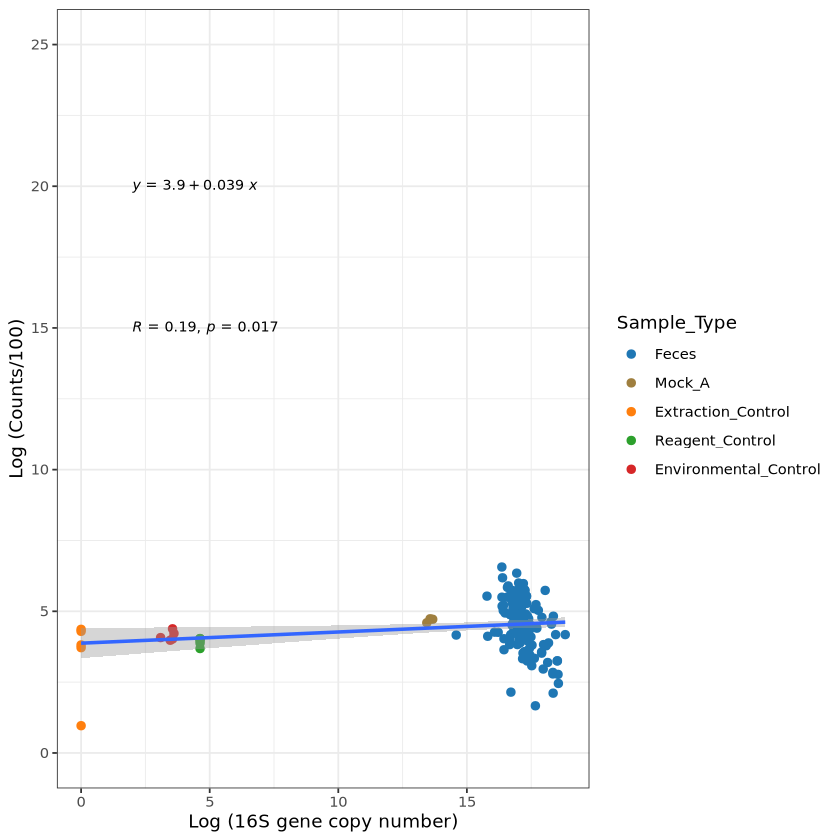

In [153]:
# Plot for the samples and controls, except Mock_B
metadata_plot_wo.MockB <- metadata_contam %>% filter(Sample_Type != "Mock_B")
p.contam.counts.wo.MockB <- ggplot(data = metadata_plot_wo.MockB,
                                   aes(x = log(qpcr_16s_copies_ul), 
                                       y = log(counts/100))) +
  geom_point(aes(color = Sample_Type), size = 2) +
  geom_smooth(aes(group = 1), method = "lm", se = TRUE) +
  stat_cor(label.x = 2, label.y = 15, size = 3) +
  stat_regline_equation(label.x = 2, label.y = 20, size = 3) +
  xlab("Log (16S gene copy number)") +
  ylab("Log (Counts/100)") +
  ylim(0, 25) +
  scale_color_manual(values = my_palette)

p.contam.counts.wo.MockB 

Warning message:
“Removed 4 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”


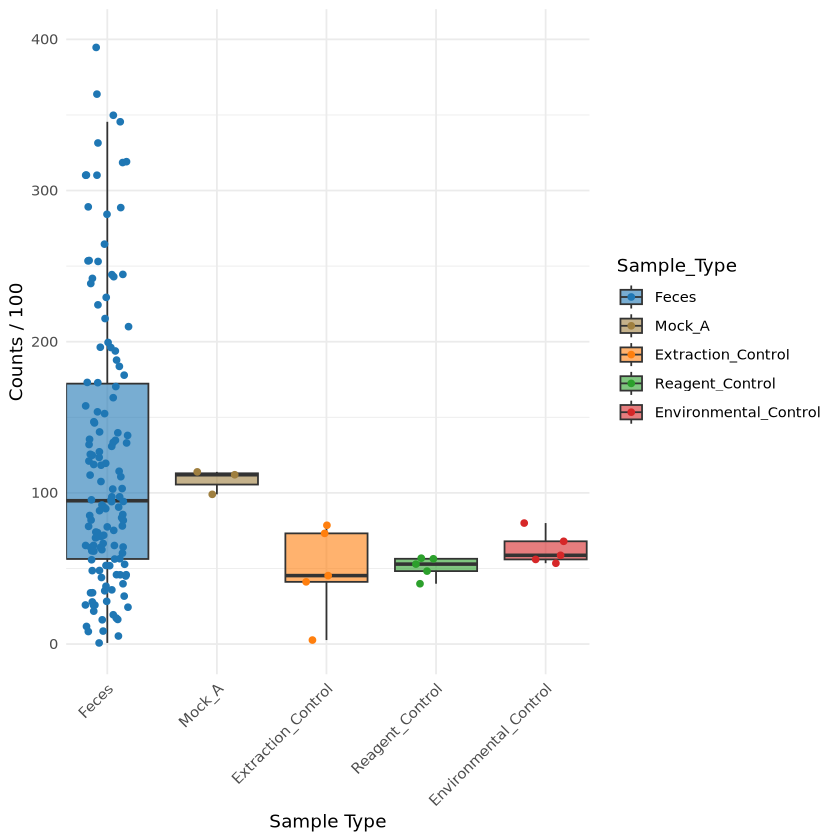

In [154]:
# Box plot without Mock B

p.contam.counts.wo.MockB.BP <-  ggplot(metadata_plot_wo.MockB,
                           aes(x = Sample_Type, y = counts / 100, fill = Sample_Type)) +
  geom_boxplot(alpha = 0.6, outlier.shape = NA) +
  geom_jitter(aes(color = Sample_Type), width = 0.2, size = 1.5) +
  ylab("Counts / 100") +
  xlab("Sample Type") +
  scale_fill_manual(values = my_palette) +
  scale_color_manual(values = my_palette) +
  theme_minimal()

# Print plot
p.contam.counts.wo.MockB.BP + 
  ylim(0, 400) +  
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) + 
  scale_x_discrete(expand = expansion(mult = c(0.05, 0.1))) 

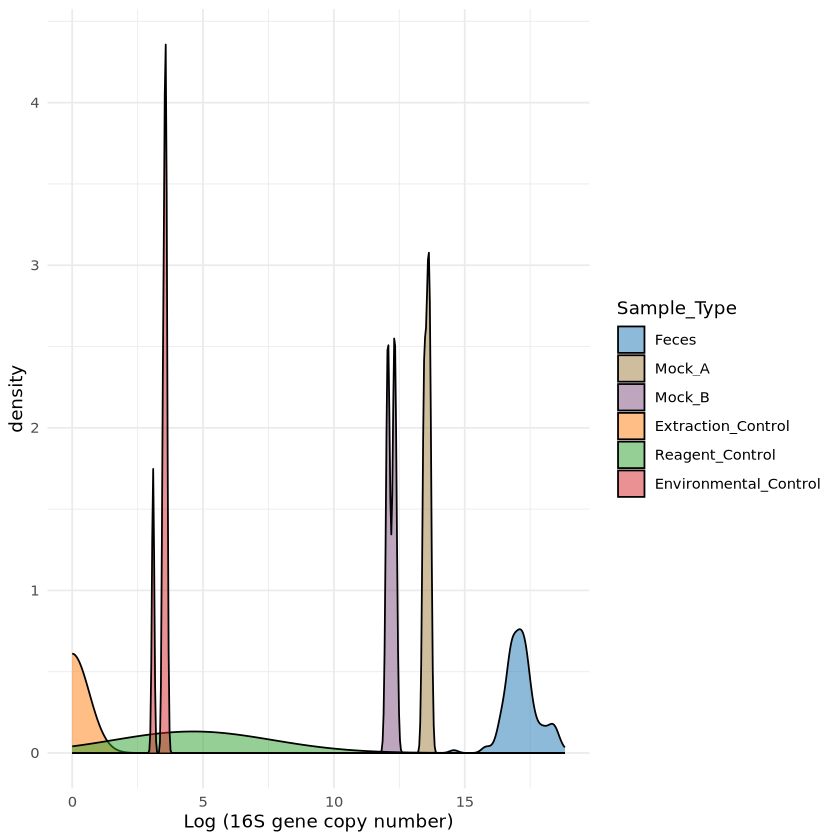

In [155]:
# Density Plot
# Visualize distribution of contaminants across copy numbers.
ggplot(metadata_contam, aes(x = log(qpcr_16s_copies_ul), fill = Sample_Type)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = my_palette) +
  xlab("Log (16S gene copy number)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message in qt((1 - level)/2, df):
“NaNs produced”
Warning message in max(ids, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


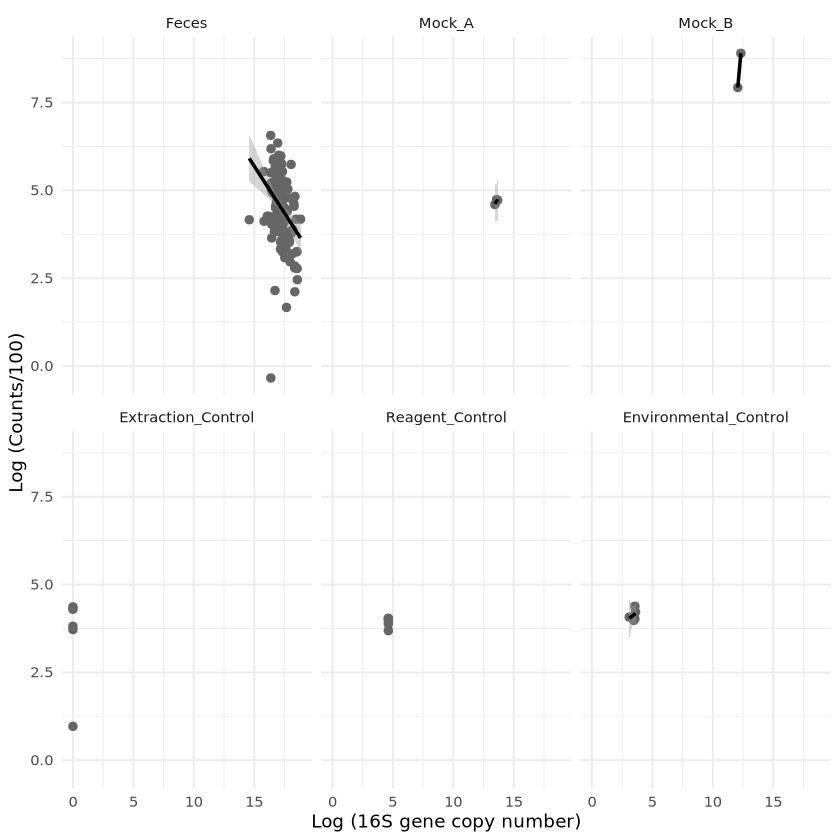

In [156]:
# Facet by Sample Type 
# See the relationship per group without overplotting

ggplot(metadata_contam, aes(x = log(qpcr_16s_copies_ul), y = log(counts / 100))) +
  geom_point(color = "gray40", size = 2) +
  geom_smooth(method = "lm", se = TRUE, color = "black") +
  facet_wrap(~ Sample_Type) +
  xlab("Log (16S gene copy number)") +
  ylab("Log (Counts/100)") +
  theme_minimal()

`geom_smooth()` using formula = 'y ~ x'
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“span too small.   fewer data values than degrees of freedom.”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“pseudoinverse used at 13.44”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“neighborhood radius 0.12989”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“reciprocal condition number  0”
Warning message in simpleLoess(y, x, w, span, degree = degree, parametric = parametric, :
“There are other near singularities as well. 0.010282”
Warning message in predLoess(object$y, object$x, newx = if (is.null(newdata)) object$x else if (is.data.frame(newdata)) as.matrix(model.frame(delete.response(terms(object)), :
“span too small.   fewer data values than degrees of freedom.”
Warning message in predLoess(object$y, object$x, newx = if (

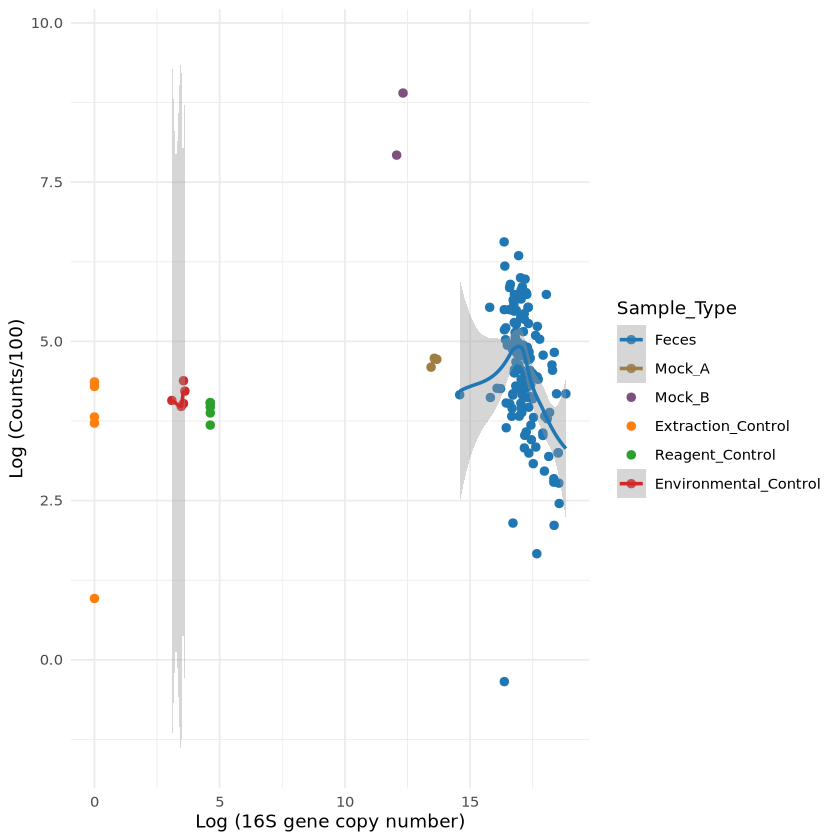

In [157]:
# LOESS instead of linear, to better capture curves in the data.
# LOESS can adapt to small local trends even with high variability 

ggplot(metadata_contam, aes(x = log(qpcr_16s_copies_ul), y = log(counts / 100), color = Sample_Type)) +
  geom_point(size = 2) +
  geom_smooth(method = "loess", se = TRUE,  span = 0.7) +
  scale_color_manual(values = my_palette) +
  xlab("Log (16S gene copy number)") +
  ylab("Log (Counts/100)") +
  theme_minimal()

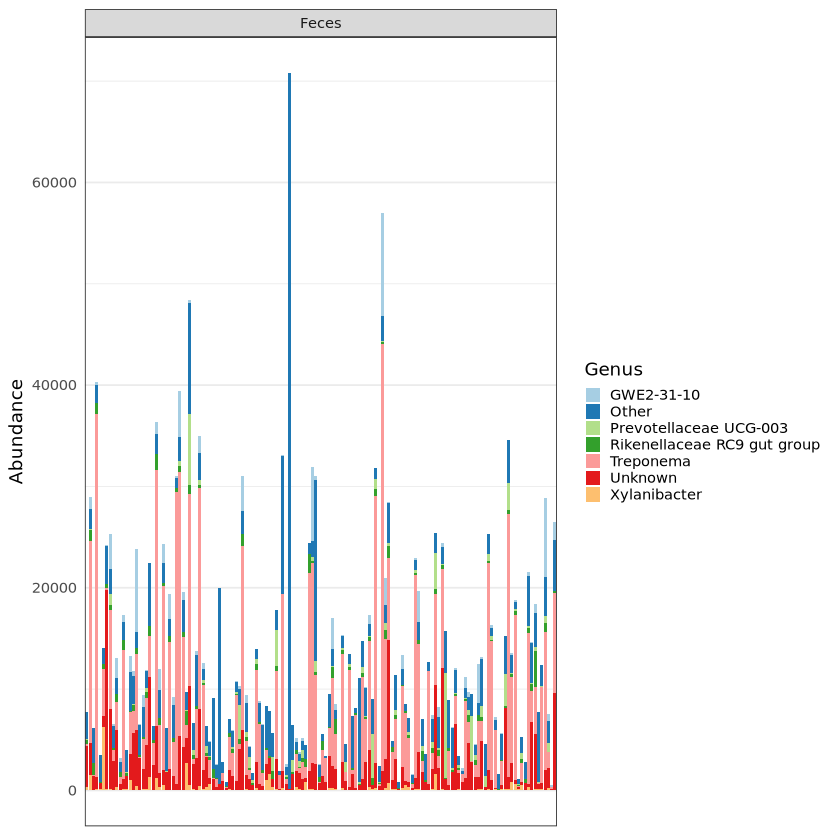

In [159]:
## Plot the Abundance of Contaminants
# Data
detection <- sum(taxa_sums(ps.contam))/162*0.05
pseq.contam <- aggregate_rare(ps.contam, 
                              level="Genus", 
                              detection = detection,
                              prevalence = 0.05)

melt.contam <- psmelt(pseq.contam)
# Plot for Feces
p.contam1 <- ggplot(
  melt.contam %>% filter(Sample_Type == "Feces"), 
  aes(x = Sample_ID, 
      y = Abundance, 
      fill = Genus)) +
  geom_bar(stat = "identity") +
  facet_grid(. ~ Sample_Type, 
             scales = "free_x", 
             space = "free") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_blank(),
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_brewer("Genus", palette = "Paired")
p.contam1

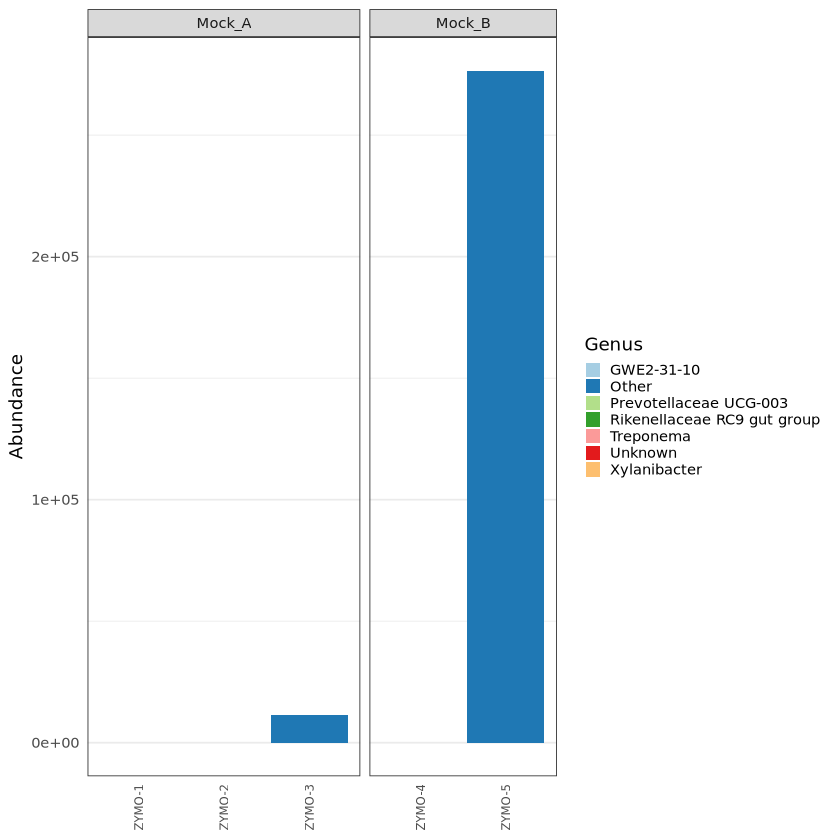

In [160]:
# Plot for Mock Communities 

p.contam3 <- ggplot(
  melt.contam %>% filter(Sample_Type == c( "Mock_A", 
                                           "Mock_B")),
  aes(x = Sample_ID, y = Abundance, fill = Genus)) +
    geom_bar(stat = "identity") +
  facet_grid(. ~ Sample_Type, 
             scales = "free_x", 
             space = "free") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7), 
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_brewer("Genus", palette = "Paired")

p.contam3

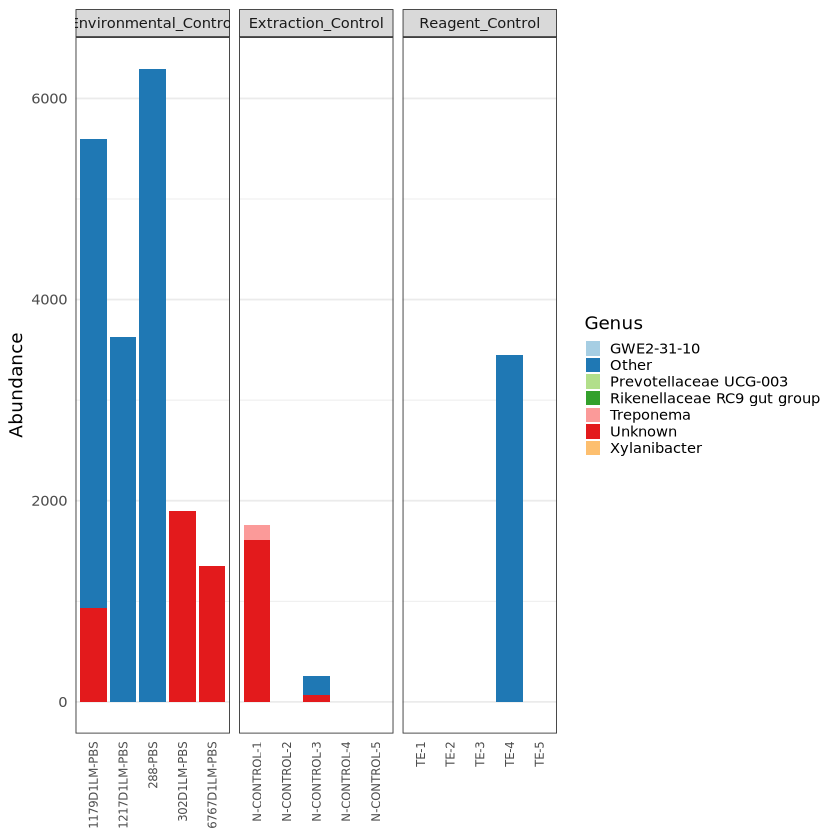

In [161]:
# Plot for Negative Controls
p.contam2 <- ggplot(
  melt.contam %>% filter(Sample_Type == c("Environmental_Control",
    "Extraction_Control", "Reagent_Control")),
  aes(x = Sample_ID, y = Abundance, fill = Genus)) +
    geom_bar(stat = "identity") +
  facet_grid(. ~ Sample_Type, 
             scales = "free_x", 
             space = "free") +
  theme_bw() +
  theme(
    axis.title.x = element_blank(),
    axis.text.x =  element_text(angle = 90, vjust = 0.5, hjust = 1, size = 7), 
    axis.ticks = element_blank(),
    legend.key.size = unit(10, "pt"),
    panel.grid.major.x = element_blank()
  ) +
  scale_fill_brewer("Genus", palette = "Paired")

p.contam2

In [162]:
# Subset only Feces samples and Positive controls
ps.contam.sample <- subset_samples(ps.contam, 
                                   Sample_Type %in% c("Feces",
                                                      "Mock_A",
                                                      "Mock_B" ))


ps.contam.sample <- prune_taxa(taxa_sums(ps.contam)>0, 
                               ps.contam.sample)

type_colors <- c("Feces" = "#1f77b4", 
                 "Mock_A" = "#2ca02c",
                 "Mock_B"= "#d62728")


ord.bray.nmds.contam <- ordinate(ps.contam.sample, 
                                 "NMDS", 
                                 "bray", 
                                 k=4, 
                                 trymax = 1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.189738 
Run 1 stress 0.1888034 
... New best solution
... Procrustes: rmse 0.02934281  max resid 0.1293215 
Run 2 stress 0.190005 
Run 3 stress 0.1897055 
Run 4 stress 0.1903288 
Run 5 stress 0.189448 
Run 6 stress 0.1885951 
... New best solution
... Procrustes: rmse 0.04988486  max resid 0.1326134 
Run 7 stress 0.1885672 
... New best solution
... Procrustes: rmse 0.03586481  max resid 0.1066577 
Run 8 stress 0.1889162 
... Procrustes: rmse 0.03294498  max resid 0.1658716 
Run 9 stress 0.1887789 
... Procrustes: rmse 0.01792234  max resid 0.07337199 
Run 10 stress 0.1892017 
Run 11 stress 0.1890123 
... Procrustes: rmse 0.02048169  max resid 0.09463404 
Run 12 stress 0.1893208 
Run 13 stress 0.1889455 
... Procrustes: rmse 0.03038185  max resid 0.1504318 
Run 14 stress 0.1886865 
... Procrustes: rmse 0.01440793  max resid 0.05987059 
Run 15 stress 0.1885245 
... New best solution
... Procrustes: rmse 0.0122367

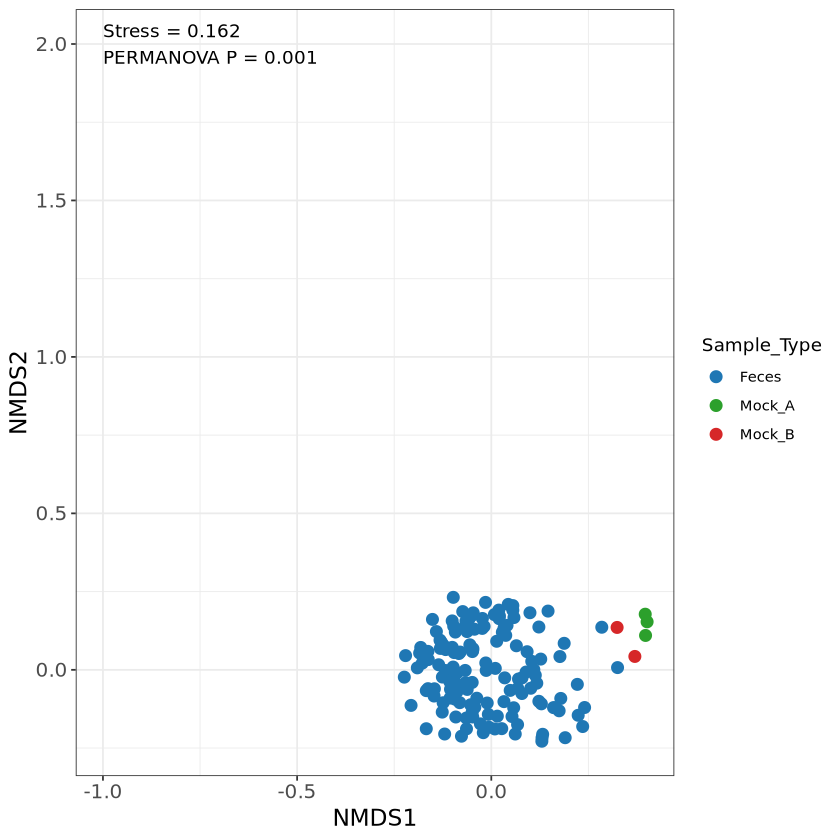

In [163]:
# PERMANOVA
ord.pnmds.contam <- plot_ordination(ps.contam.sample, ord.bray.nmds.contam, color = "Sample_Type") +
 geom_point(size = 3.0) +
 theme_bw() +
 scale_color_manual(values = type_colors) +
 theme(axis.text = element_text(size = 12),
 axis.title = element_text(size = 14),
 plot.title = element_text(hjust=0.5))+
 annotate("text", x = -1, y = 2, label = "Stress = 0.162\nPERMANOVA P = 0.001",
 hjust = 0)
print(ord.pnmds.contam) # NMDS of contaminants

In [164]:

bray.dist.contam<-vegdist(otu_table(ps.contam.sample), method='bray')
metadata.sample <- sample_data(ps.contam.sample) %>% data.frame()
beta_div.contam <-pairwise.adonis2(bray.dist.contam ~ Sample_Type, 
                                   data=metadata.sample, 
                                   permutations=999)

'nperm' >= set of all permutations: complete enumeration.

Set of permutations < 'minperm'. Generating entire set.



In [165]:
beta_div.contam

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,1.80748,0.03279796,4.84915,0.001
Residual,143,53.30205,0.96720204,NA,NA
Total,144,55.10953,1.00000000,NA,NA
,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Model,1,1.131117,0.02074714,3.008512,0.002
Residual,142,53.388045,0.97925286,NA,NA
Total,143,54.519162,1.00000000,NA,NA
,Df,SumOfSqs,R2,F,Pr(>F)


In [130]:
#### Sourcetracker


In [166]:
# SourceTracker Libraries
library (dplyr)
library (phyloseq)
library (vegan)
library (ggplot2)
library (MicrobiotaProcess)
library (tidyr)
library (data.table)
library(devtools)
library (pairwiseAdonis)
library (microbiome)
library (patchwork)

ERROR: Error in library(MicrobiotaProcess): there is no package called ‘MicrobiotaProcess’


In [187]:
library(reticulate)
use_condaenv("r_env", required = TRUE)

# Now this should finally work:
st_module <- import("sourcetracker._sourcetracker")
st <- st_module$SourceTracker()


ERROR: No module named 'sourcetracker._sourcetracker'

In [185]:
# Import the actual SourceTracker class
st_module <- import("sourcetracker._sourcetracker")


ERROR: No module named 'sourcetracker._sourcetracker'

In [167]:
#Phyloseq Object after Decontam
ps.decontam <- readRDS(file.path(path.rds,"ps.decontam.rds"))
ps.decontam

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 21010 taxa and 162 samples ]
sample_data() Sample Data:       [ 162 samples by 67 sample variables ]
tax_table()   Taxonomy Table:    [ 21010 taxa by 7 taxonomic ranks ]
refseq()      DNAStringSet:      [ 21010 reference sequences ]

In [168]:
# Metadata / Label samples as source or sink
metadata <- as.data.frame(sample_data(ps.decontam))
metadata$SourceSink <- NA
metadata$SourceSink[ metadata$Sample_Type %in% 
    c("Reagent_Control", "Extraction_Control", "Environmental_Control") ] <- "source"
metadata$SourceSink[ metadata$Sample_Type %in% 
    c("Feces", "Mock_A", "Mock_B") ] <- "sink"
metadata$SourceSink

[1] "sink"   "sink"   "source" "sink"   "sink"   "source" "sink"   "sink"  
  [9] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [17] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [25] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [33] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "source" "sink"  
 [41] "sink"   "source" "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [49] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [57] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [65] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [73] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [81] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [89] "source" "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
 [97] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[105] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[113] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[121] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[129] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[137] "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"   "sink"  
[145] "sink"   "sink"   "sink"   "source" "source" "source" "source" "source"
[153] "source" "source" "source" "source" "source" "sink"   "sink"   "sink"  
[161] "sink"   "sink"

In [170]:
# Prepare OTU matrix
# Sourcetracker wants the sample names as rows in an otu table and the metadatafile, which is the opposite of how phyloseq likes it!
otus <- as.matrix(data.frame(otu_table(ps.decontam)))
dim(otus) # 21818 (OTUs),   162 (Samples)

[1]   162 21010

In [171]:
# Extract only those samples in common between the two tables (metadata and otus):
common.sample.ids  <- intersect(rownames(metadata),rownames(otus))
st_otus <- otus[common.sample.ids , , drop = FALSE]
metadata <- metadata[common.sample.ids , , drop = FALSE]


# Double-check that the mapping file and otu table had overlapping samples:
if(length(common.sample.ids) <= 1) {
 message <- paste(sprintf('Error: there are %d sample ids in
 common '),'between the metadata file
 and data table')
 stop(message)
}

In [173]:
# Train the model 
# Extract the source environments and source/sink indices
train.ix <- which(metadata$SourceSink=='source')
test.ix <- which(metadata$SourceSink=='sink')


# Check sink OTU table dimensions:
dim(otus[test.ix, ]) 
length(test.ix) 
# env
envs <- metadata$Sample_Type
envs

[1]   147 21010

[1] 147

[1] "Feces"                 "Feces"                 "Environmental_Control"
  [4] "Feces"                 "Feces"                 "Environmental_Control"
  [7] "Feces"                 "Feces"                 "Feces"                
 [10] "Feces"                 "Feces"                 "Feces"                
 [13] "Feces"                 "Feces"                 "Feces"                
 [16] "Feces"                 "Feces"                 "Feces"                
 [19] "Feces"                 "Feces"                 "Feces"                
 [22] "Feces"                 "Feces"                 "Feces"                
 [25] "Feces"                 "Feces"                 "Feces"                
 [28] "Feces"                 "Feces"                 "Feces"                
 [31] "Feces"                 "Feces"                 "Feces"                
 [34] "Feces"                 "Feces"                 "Feces"                
 [37] "Feces"                 "Feces"                 "Environmental_Control"
 [40] "Feces"                 "Feces"                 "Environmental_Control"
 [43] "Feces"                 "Feces"                 "Feces"                
 [46] "Feces"                 "Feces"                 "Feces"                
 [49] "Feces"                 "Feces"                 "Feces"                
 [52] "Feces"                 "Feces"                 "Feces"                
 [55] "Feces"                 "Feces"                 "Feces"                
 [58] "Feces"                 "Feces"                 "Feces"                
 [61] "Feces"                 "Feces"                 "Feces"                
 [64] "Feces"                 "Feces"                 "Feces"                
 [67] "Feces"                 "Feces"                 "Feces"                
 [70] "Feces"                 "Feces"                 "Feces"                
 [73] "Feces"                 "Feces"                 "Feces"                
 [76] "Feces"                 "Feces"                 "Feces"                
 [79] "Feces"                 "Feces"                 "Feces"                
 [82] "Feces"                 "Feces"                 "Feces"                
 [85] "Feces"                 "Feces"                 "Feces"                
 [88] "Feces"                 "Environmental_Control" "Feces"                
 [91] "Feces"                 "Feces"                 "Feces"                
 [94] "Feces"                 "Feces"                 "Feces"                
 [97] "Feces"                 "Feces"                 "Feces"                
[100] "Feces"                 "Feces"                 "Feces"                
[103] "Feces"                 "Feces"                 "Feces"                
[106] "Feces"                 "Feces"                 "Feces"                
[109] "Feces"                 "Feces"                 "Feces"                
[112] "Feces"                 "Feces"                 "Feces"                
[115] "Feces"                 "Feces"                 "Feces"                
[118] "Feces"                 "Feces"                 "Feces"                
[121] "Feces"                 "Feces"                 "Feces"                
[124] "Feces"                 "Feces"                 "Feces"                
[127] "Feces"                 "Feces"                 "Feces"                
[130] "Feces"                 "Feces"                 "Feces"                
[133] "Feces"                 "Feces"                 "Feces"                
[136] "Feces"                 "Feces"                 "Feces"                
[139] "Feces"                 "Feces"                 "Feces"                
[142] "Feces"                 "Feces"                 "Feces"                
[145] "Feces"                 "Feces"                 "Feces"                
[148] "Extraction_Control"    "Extraction_Control"    "Extraction_Control"   
[151] "Extraction_Control"    "Extraction_Control"    "Reagent_Control"      
[154] "Reagent_Control" 

In [174]:
if(is.element('Cow_ID',colnames(metadata))) desc <- metadata$Cow_ID

In [176]:
#Tune the alpha values using cross-validation (this is slow!)
alpha1 <- alpha2 <- 0.001
alpha1 # 0.001
alpha2 # 0.001

[1] 0.001

[1] 0.001

In [184]:
# Train SourceTracker object on training data
st <- sourcetracker(otus[train.ix,],  envs[train.ix], rarefaction_depth = NULL)

ERROR: Error in sourcetracker(otus[train.ix, ], envs[train.ix], rarefaction_depth = NULL): could not find function "sourcetracker"


In [178]:
#Export Data
otu_train <-otus[train.ix,]
otu_envs <-envs[train.ix]

# Export SourceTracker model and data splits
saveRDS(st, file.path(path.rds, "st.rds"))
saveRDS(otu_train, file.path(path.rds, "otu_train.rds"))
saveRDS(otu_envs, file.path(path.rds, "otu_envs.rds"))
saveRDS(envs, file.path(path.rds, "envs.rds"))
saveRDS(train.ix, file.path(path.rds, "train.ix.rds"))
saveRDS(test.ix, file.path(path.rds, "test.ix.rds"))


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'object' in selecting a method for function 'saveRDS': object 'st' not found


In [5]:
# Define the path again # to be sure
path.rds <- "/scratch/negishi/ldas/COW_INFLAMMATION"

# Load previously saved objects
otu_mat  <- readRDS(file.path(path.rds, "otu_mat.rds"))
envs     <- readRDS(file.path(path.rds, "envs.rds"))
train.ix <- readRDS(file.path(path.rds, "train.ix.rds"))
test.ix  <- readRDS(file.path(path.rds, "test.ix.rds"))


# Load the SourceTracker function
source("/scratch/negishi/ldas/Gabriela/SourceTracker.r")

# Train the SourceTracker model
st <- sourcetracker(otu_mat[train.ix, ], envs[train.ix], rarefaction_depth = 1000)

# Save the trained model
saveRDS(st, file = file.path(path.rds, "st.rds"))


Rarefying training data at 1000


In [6]:

library(parallel)

# Optional: set parameters
alpha1 <- 0.001
alpha2 <- 0.001
# Define auto rarefaction depth based on training sample read counts
rarefaction_auto <- min(rowSums(otu_mat[train.ix, ]))
rarefaction <- rarefaction_auto

# Filter test samples that have enough reads
row_sums <- rowSums(otu_mat[test.ix, ])
sufficient_reads <- row_sums >= rarefaction
filtered_test_ix <- test.ix[sufficient_reads]
otu_test_filtered <- otu_mat[filtered_test_ix, ]

# Detect number of cores
n.cores <- detectCores() - 10  # Leave one core free

# Predict source proportions in parallel
results <- mclapply(1:nrow(otu_test_filtered), function(i) {
  sample_matrix <- otu_test_filtered[i, , drop = FALSE]
  predict(st, sample_matrix,
          alpha1 = alpha1,
          alpha2 = alpha2,
          full.results = TRUE,
          rarefaction_depth = rarefaction)
}, mc.cores = n.cores)

# Save the results
saveRDS(results, file.path(path.rds, "sourcetracker_results1.rds"))


In [82]:
st_result <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/sourcetracker_results1.rds")
length(st_result)  # Should be > 0


[1] 142

In [74]:
# 1. Load the SourceTracker results
st_result <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/sourcetracker_results1.rds")

# 2. Load the OTU table used for SourceTracker (must match the one used for training/testing)
otu_mat <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/otu_mat.rds")
test.ix <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/test.ix.rds")  # index of sink samples (e.g., feces)

# 3. Extract source proportions (assumes default output from `predict(..., full.results = TRUE)`)
source_prop_mat <- t(sapply(st_result, function(x) x$proportions))

# 4. Identify sink samples where predicted contamination is >50%
high_contam_sinks <- which(source_prop_mat[, "Unknown"] < 0.5)  # i.e., more than 50% from known sources (controls)
high_contam_samples <- test.ix[high_contam_sinks]

# 5. Get ASVs that appear in these high contamination samples
asv_st <- colnames(otu_mat)[colSums(otu_mat[high_contam_samples, , drop = FALSE]) > 0]

# 6. Check number of ASVs
length(asv_st)
head(asv_st)


ERROR: Error in h(simpleError(msg, call)): error in evaluating the argument 'x' in selecting a method for function 'which': no 'dimnames' attribute for array


In [80]:
# Load SourceTracker result
st_result <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/sourcetracker_results1.rds")

# Extract column names from first prediction (source labels)
source_labels <- colnames(st_result[[1]]$proportions)

# Build matrix of proportions with correct dimnames
source_prop_mat <- do.call(rbind, lapply(st_result, function(x) x$proportions))
colnames(source_prop_mat) <- source_labels  # add column names if missing

# Define control source labels
control_sources <- c("Environmental_Control", "Extraction_Control", "Reagent_Control")

# Calculate total contribution from control sources
control_prop_sum <- rowSums(source_prop_mat[, control_sources, drop = FALSE])

# Identify highly contaminated sink samples (>50%)
high_contam_sinks <- which(control_prop_sum > 0.5)
# Load OTU matrix and sink indices
otu_mat <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/otu_mat.rds")
test.ix <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/test.ix.rds")

# Identify sink sample names
high_contam_samples <- test.ix[high_contam_sinks]

# Extract ASVs from contaminated sink samples
asv.st <- colnames(otu_mat)[colSums(otu_mat[high_contam_samples, , drop = FALSE]) > 0]

# Save these ASVs
write.csv(
  data.frame(ASV_Sequence = asv.st),
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_sourcetracker.csv",
  row.names = FALSE, quote = FALSE
)


In [81]:
# Step 1: Load all ASV lists
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence.csv", stringsAsFactors = FALSE)
asv.st   <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_sourcetracker.csv", stringsAsFactors = FALSE)

# Step 2: Standardize column name
colnames(asv.freq) <- "ASV_Sequence"
colnames(asv.prev) <- "ASV_Sequence"
colnames(asv.st)   <- "ASV_Sequence"

# Step 3: Trim whitespace
asv.freq$ASV_Sequence <- trimws(asv.freq$ASV_Sequence)
asv.prev$ASV_Sequence <- trimws(asv.prev$ASV_Sequence)
asv.st$ASV_Sequence   <- trimws(asv.st$ASV_Sequence)

# Step 4: Get shared contaminants
common_3way <- Reduce(intersect, list(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence, asv.st$ASV_Sequence))
common_freq_prev <- intersect(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence)
common_freq_st   <- intersect(asv.freq$ASV_Sequence, asv.st$ASV_Sequence)
common_prev_st   <- intersect(asv.prev$ASV_Sequence, asv.st$ASV_Sequence)

# Step 5: Summary
asv_summary <- data.frame(
  Category = c(
    "Frequency only",
    "Prevalence only",
    "SourceTracker only",
    "Frequency ∩ Prevalence",
    "Frequency ∩ SourceTracker",
    "Prevalence ∩ SourceTracker",
    "All Methods (Shared)"
  ),
  Num_ASVs = c(
    length(setdiff(asv.freq$ASV_Sequence, union(asv.prev$ASV_Sequence, asv.st$ASV_Sequence))),
    length(setdiff(asv.prev$ASV_Sequence, union(asv.freq$ASV_Sequence, asv.st$ASV_Sequence))),
    length(setdiff(asv.st$ASV_Sequence, union(asv.freq$ASV_Sequence, asv.prev$ASV_Sequence))),
    length(common_freq_prev),
    length(common_freq_st),
    length(common_prev_st),
    length(common_3way)
  )
)

# Print summary
print(asv_summary)

# Step 6: Save the shared ASVs
write.csv(data.frame(ASV_Sequence = common_3way),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/common_contaminants_all_methods.csv",
          row.names = FALSE, quote = FALSE)


                    Category Num_ASVs
1             Frequency only     1882
2            Prevalence only      448
3         SourceTracker only        0
4     Frequency ∩ Prevalence       37
5  Frequency ∩ SourceTracker        0
6 Prevalence ∩ SourceTracker        0
7       All Methods (Shared)        0


In [73]:
# View first few ASVs
head(asv_st)

# Count total number of ASVs identified as contaminants by SourceTracker
length(asv_st)


character(0)

[1] 0

In [7]:
# Load SourceTracker prediction results
results <- readRDS(file.path(path.rds, "sourcetracker_results1.rds"))

# Define sink sample names used in prediction
sink_sample_ids <- rownames(otu_mat)[filtered_test_ix]

# Safe extractor to handle results using `$proportions`
safe_extract_proportions <- function(res, sample_name) {
  if (is.null(res) || is.null(res$proportions) || length(res$proportions) == 0) {
    return(NULL)
  }

  p <- res$proportions

  # Convert to named vector
  if (is.matrix(p) || is.data.frame(p)) {
    vec <- as.numeric(p[1, , drop = TRUE])
    names(vec) <- colnames(p)
  } else {
    vec <- as.numeric(p)
    if (is.null(names(vec))) names(vec) <- paste0("Source", seq_along(vec))
  }

  data.frame(Sample_ID = rep(sample_name, length(vec)),
             Source     = names(vec),
             Proportion = vec,
             stringsAsFactors = FALSE)
}

# Apply the function to all results
compiled_list <- mapply(
  safe_extract_proportions,
  res         = results,
  sample_name = sink_sample_ids,
  SIMPLIFY    = FALSE
)

# Combine into one data frame
compiled_df <- do.call(rbind, compiled_list)

# Preview
cat("Compiled", nrow(compiled_df), "rows from", length(results), "samples.\n")
head(compiled_df)

# Save to CSV
write.csv(compiled_df,
          file = file.path(path.rds, "sourcetracker_results_compiled.csv"),
          row.names = FALSE)


Compiled 568 rows from 142 samples.


,Sample_ID,Source,Proportion
,<chr>,<chr>,<dbl>
Environmental_Control,1165D1LM,Environmental_Control,0.00042106
Extraction_Control,1165D1LM,Extraction_Control,0.03178949
Reagent_Control,1165D1LM,Reagent_Control,0.00021053
Unknown,1165D1LM,Unknown,0.96757892
Environmental_Control1,1165D3LM,Environmental_Control,0.00000000
Extraction_Control1,1165D3LM,Extraction_Control,0.04400001


In [8]:
library(ggplot2)
library(dplyr)
library(viridis)

# Ensure Source is a factor with all levels
all_sources <- unique(compiled_df$Source)
compiled_df <- compiled_df %>%
  mutate(Source = factor(Source, levels = all_sources))

# Order samples by contamination source proportion
contam_source <- "Unknown"
sample_order <- compiled_df %>%
  filter(Source == contam_source) %>%
  arrange(Proportion) %>%
  pull(Sample_ID) %>%
  unique()

compiled_df <- compiled_df %>%
  mutate(Sample_ID = factor(Sample_ID, levels = sample_order))

# Create the plot
p <- ggplot(compiled_df, aes(x = Sample_ID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_viridis_d(
    option = "C",
    end = 0.9,
    direction = 1,
    name = "Source"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
    axis.title.x = element_text(margin = margin(t = 8)),
    axis.title.y = element_text(margin = margin(r = 8)),
    panel.grid.major.x = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 9)
  ) +
  labs(
    title = "SourceTracker: All Source Contributions",
    x = "Sink Sample",
    y = "Proportion"
  )

# Save as high-resolution PNG
ggsave(
  filename = file.path(path.figures, "sourcetracker_viridis_plot.png"),
  plot     = p,
  width    = 10,
  height   = 6,
  units    = "in",
  dpi      = 300
)

# Save as high-resolution TIFF
ggsave(
  filename = file.path(path.figures, "sourcetracker_viridis_plot.tiff"),
  plot     = p,
  width    = 10,
  height   = 6,
  units    = "in",
  dpi      = 300,
  device   = "tiff"
)


Loading required package: viridisLite



ERROR: Error: object 'path.figures' not found


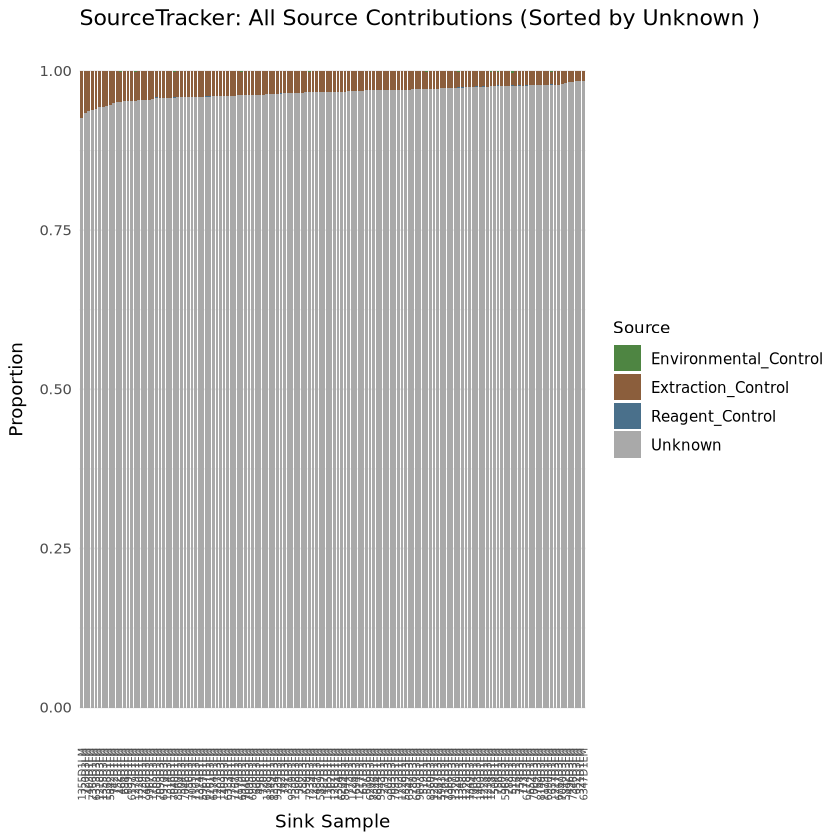

In [9]:
nature_palette <- c(
  "Environmental_Control" = "#4E8542",  # Forest green
  "Extraction_Control"    = "#8B5E3C",  # Earthy brown
  "Reagent_Control"       = "#4A708B",  # Slate blue
  "Unknown"               = "#A9A9A9"   # Ash gray
)
ggplot(compiled_df, aes(x = Sample_ID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_manual(
    values = nature_palette,
    name = "Source"
  ) +
  theme_minimal(base_size = 11) +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 6),
    axis.title.x = element_text(margin = margin(t = 8)),
    axis.title.y = element_text(margin = margin(r = 8)),
    panel.grid.major.x = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 9)
  ) +
  labs(
    title = paste("SourceTracker: All Source Contributions (Sorted by", contam_source, ")"),
    x = "Sink Sample",
    y = "Proportion"
  )


In [10]:
#### Dual Stack plot
contam_source <- "Unknown"        # Source to sort by
output_basename <- "dualscale_sourcetracker_plot"
output_path <- path.figures       # Replace with your actual

# ─────────────────────────────
# Ensure all source levels are present and ordered
all_sources <- unique(compiled_df$Source)
compiled_df <- compiled_df %>%
  mutate(Source = factor(Source, levels = all_sources))

# Order samples by proportion of chosen source (e.g., Unknown)
sample_order <- compiled_df %>%
  filter(Source == contam_source) %>%
  arrange(Proportion) %>%
  pull(Sample_ID) %>%
  unique()

compiled_df <- compiled_df %>%
  mutate(Sample_ID = factor(Sample_ID, levels = sample_order))

# ─────────────────────────────


# Shared base aesthetics
base_plot <- ggplot(compiled_df, aes(x = Sample_ID, y = Proportion, fill = Source)) +
  geom_bar(stat = "identity", width = 0.8) +
  scale_fill_viridis_d(option = "C", end = 0.9, name = "Source") +
  theme_minimal(base_size = 10) +
  theme(
    axis.title.x = element_blank(),
    panel.grid.major.x = element_blank(),
    legend.position = "right",
    legend.title = element_text(size = 10),
    legend.text = element_text(size = 9)
  )

# Full scale plot (0–1)
p_full <- base_plot +
  coord_cartesian(ylim = c(0, 1)) +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank()
  ) +
  labs(title = "Total Source Contributions", y = "Proportion (Full Scale)")

# Zoomed-in plot (0–0.1)
p_zoom <- base_plot +
  coord_cartesian(ylim = c(0, 0.1)) +
  theme(
    axis.text.x = element_text(angle = 90, size = 6, hjust = 1),
    axis.title.x = element_text(margin = margin(t = 8))
  ) +
  labs(title = "SourceTracker_all contribution", y = "Proportion (0–0.1)", x = "Sink Sample")

# Combine vertically using patchwork
p_combined <- p_full / p_zoom + plot_layout(heights = c(2, 1))

# ─────────────────────────────
# EXPORT TO FILES
# ─────────────────────────────

# PNG
ggsave(
  filename = file.path(output_path, paste0(output_basename, ".png")),
  plot     = p_combined,
  width    = 12,
  height   = 8,
  units    = "in",
  dpi      = 300
)

# TIFF
ggsave(
  filename = file.path(output_path, paste0(output_basename, ".tiff")),
  plot     = p_combined,
  width    = 12,
  height   = 8,
  units    = "in",
  dpi      = 300,
  device   = "tiff"
)


ERROR: Error: object 'path.figures' not found


In [12]:
#Identify ASVs common in control samples
control_asvs <- colnames(otu_mat)[colSums(otu_mat[train.ix, ]) > 0]
#Identify ASVs found in sink samples predicted to be from control sources
results <- readRDS(file.path(path.rds, "sourcetracker_results1.rds"))
#proportion of known sources
source_names <- unique(unlist(lapply(results, function(x) colnames(x$proportions))))
print(source_names)  # Helps verify source types like "Reagent_Control", etc.

# Extract just proportions from known contaminant sources
source_prop_mat <- do.call(rbind, lapply(results, function(x) {
  # Pick only known contaminant sources from the proportions matrix
  prop_row <- x$proportions
  contam_sources <- c("Reagent_Control", "Extraction_Control", "Environmental_Control")
  contam_sum <- rowSums(prop_row[, colnames(prop_row) %in% contam_sources, drop = FALSE])
  return(contam_sum)
}))
                                     

[1] "Environmental_Control" "Extraction_Control"    "Reagent_Control"      
[4] "Unknown"              


In [16]:
write.csv(data.frame(ASV = contam_asvs_st),
          file = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_sourcetracker.csv",
          row.names = FALSE,
          quote = FALSE)


In [17]:
# 1. Flag sink samples with >50% composition predicted from controls
high_contam_sinks <- which(source_prop_mat > 0.5)
high_contam_samples <- test.ix[high_contam_sinks]

# 2. Get ASVs in those highly contaminated sink samples
contam_asvs_st <- colnames(otu_mat)[colSums(otu_mat[high_contam_samples, ]) > 0]

# 3. Load frequency and prevalence contaminant ASVs (from decontam)
asv.freq <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/asvs_frequency_contaminants.rds")
asv.prev <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/asvs_prevalence_contaminants.rds")

# 4. Get overlap of all three methods
common_contaminants <- Reduce(intersect, list(asv.freq, asv.prev, contam_asvs_st))
length(common_contaminants)

# 5. Save individual and shared ASVs to CSV
write.csv(data.frame(ASV = asv.freq),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminants_frequency.csv",
          row.names = FALSE)

write.csv(data.frame(ASV = asv.prev),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminants_prevalence.csv",
          row.names = FALSE)

write.csv(data.frame(ASV = contam_asvs_st),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminants_sourcetracker.csv",
          row.names = FALSE)

write.csv(data.frame(ASV = common_contaminants),
          "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/common_contaminants_all_methods.csv",
          row.names = FALSE)


Warning message in gzfile(file, "rb"):
“cannot open compressed file '/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/asvs_frequency_contaminants.rds', probable reason 'No such file or directory'”


ERROR: Error in gzfile(file, "rb"): cannot open the connection


In [18]:
# Load ASV lists
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)$ASV
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence.csv", stringsAsFactors = FALSE)$ASV
asv.st   <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_sourcetracker.csv", stringsAsFactors = FALSE)$ASV

# Find common ASVs across all methods
common_asvs <- Reduce(intersect, list(asv.freq, asv.prev, asv.st))

# Save the common ASVs
write.csv(
  data.frame(ASV = common_asvs),
  "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/common_contaminants_all_methods.csv",
  row.names = FALSE
)

# Optional: print summary
cat("Number of shared ASVs across all methods:", length(common_asvs), "\n")


Number of shared ASVs across all methods: 0 


In [22]:
# Load and check each CSV file
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence.csv", stringsAsFactors = FALSE)
asv.st   <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_sourcetracker.csv", stringsAsFactors = FALSE)

# Check how many rows (ASVs) are in each
nrow(asv.freq)
nrow(asv.prev)
nrow(asv.st)


[1] 1919

[1] 485

[1] 0

In [24]:
# Load ASV lists
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)$ASV
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence.csv", stringsAsFactors = FALSE)$ASV

# Compare sets
common_asvs <- intersect(asv.freq, asv.prev)
freq_only   <- setdiff(asv.freq, asv.prev)
prev_only   <- setdiff(asv.prev, asv.freq)

# Summary counts
summary_df <- data.frame(
  Category = c("Frequency Only", "Prevalence Only", "Both"),
  Num_ASVs = c(length(freq_only), length(prev_only), length(common_asvs))
)

# Print summary
print(summary_df)

# Optionally save output files
write.csv(data.frame(ASV = freq_only), "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/asvs_only_frequency.csv", row.names = FALSE)
write.csv(data.frame(ASV = prev_only), "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/asvs_only_prevalence.csv", row.names = FALSE)
write.csv(data.frame(ASV = common_asvs), "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/asvs_common_freq_prev.csv", row.names = FALSE)


         Category Num_ASVs
1  Frequency Only        0
2 Prevalence Only        0
3            Both        0


In [26]:
# Reload and explicitly extract ASV column as character vector
asv.freq <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_frequency.csv", stringsAsFactors = FALSE)$ASV
asv.prev <- read.csv("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/contaminant_asvs_prevalence.csv", stringsAsFactors = FALSE)$ASV

# Trim whitespace again just in case
asv.freq <- trimws(asv.freq)
asv.prev <- trimws(asv.prev)

# Compare
common_asvs <- intersect(asv.freq, asv.prev)

# Report
length(common_asvs)
head(common_asvs)


[1] 0

character(0)

In [ ]:
#### Alpha Diversity Fibrinogen_InflamStat
library(phyloseq)
library(ggplot2)
library(ggpubr)
library(microbiome)   # For evenness()
library(patchwork)    # For clean spacer plot

# ----------- Calculate Alpha Diversity Metrics -----------
alpha_df <- estimate_richness(ps, measures = c("Observed", "Chao1", "Shannon", "Simpson"))
alpha_df$Evenness <- evenness(ps, index = "pielou")$pielou

# Add Fibrinogen inflammation status from metadata
sample_data_df <- data.frame(sample_data(ps))
alpha_df$InflamStatus <- sample_data_df$Fibrinogen_InflamStat

# ----------- Define Truly Blank Spacer Plot -----------
blank_plot <- ggplot() + theme_void()

# ----------- Define Plotting Function with Spaced p-values -----------
plot_alpha_metric <- function(metric) {
  ymax <- max(alpha_df[[metric]], na.rm = TRUE)
  ggplot(alpha_df, aes(x = InflamStatus, y = .data[[metric]], fill = InflamStatus)) +
    geom_boxplot(alpha = 0.8, outlier.shape = NA) +
    geom_jitter(width = 0.2, size = 2, alpha = 0.6) +
    stat_compare_means(
      method = "wilcox.test",
      label = "p.format",
      size = 4,
      label.x.npc = "center",
      label.y = ymax * 1.08
    ) +
    labs(title = metric, x = NULL, y = NULL) +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      axis.text.x = element_text(angle = 30, hjust = 1, size = 12),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
    )
}

# ----------- Generate Plots -----------
metrics <- c("Observed", "Chao1", "Shannon", "Simpson", "Evenness")
plots <- lapply(metrics, plot_alpha_metric)

# ----------- Arrange Plots with Row Gap and No Yellow Placeholder -----------
row1 <- ggarrange(
  plots[[1]], plots[[2]], plots[[3]],
  ncol = 3,
  labels = c("a", "b", "c"),
  font.label = list(size = 14, face = "bold")
)

row2 <- ggarrange(
  blank_plot, plots[[4]], plots[[5]], blank_plot,
  ncol = 4,
  widths = c(1, 1.2, 1.2, 1),
  labels = c("", "d", "e", ""),
  font.label = list(size = 14, face = "bold")
)

combined_plot <- ggarrange(
  row1,
  blank_plot,  # vertical space between rows
  row2,
  ncol = 1,
  heights = c(1, 0.1, 1),
  common.legend = TRUE,
  legend = "bottom"
)

# ----------- Add Main Title -----------
final_plot <- annotate_figure(
  combined_plot,
  top = text_grob("Alpha Diversity of Feces Microbiome by Fibrinogen_InflamStat",
                  face = "bold", size = 18)
)

# ----------- Show Plot -----------
print(final_plot)

# ----------- Save to PNG and TIFF -----------
ggsave(
  filename = file.path(path.figures, "alpha_diversity_Fibrinogen_InflamStat.png"),
  plot     = final_plot,
  width    = 16,
  height   = 10,
  dpi      = 300,
  units    = "in"
)

ggsave(
  filename = file.path(path.figures, "alpha_diversity_Fibrinogen_InflamStat.tiff"),
  plot     = final_plot,
  width    = 16,
  height   = 10,
  dpi      = 300,
  units    = "in",
  device   = "tiff"
)


In [ ]:
### Alpha dievesity Haptoglobin_InflamStat
library(phyloseq)
library(ggplot2)
library(ggpubr)
library(microbiome)   # For evenness()
library(patchwork)    # For clean spacer plot

# ----------- Calculate Alpha Diversity Metrics -----------
alpha_df <- estimate_richness(ps, measures = c("Observed", "Chao1", "Shannon", "Simpson"))
alpha_df$Evenness <- evenness(ps, index = "pielou")$pielou

# Add Haptoglobin inflammation status from metadata
sample_data_df <- data.frame(sample_data(ps))
alpha_df$InflamStatus <- sample_data_df$Haptoglobin_InflamStat

# ----------- Define Truly Blank Spacer Plot -----------
blank_plot <- ggplot() + theme_void()

# ----------- Define Plotting Function with Spaced p-values -----------
plot_alpha_metric <- function(metric) {
  ymax <- max(alpha_df[[metric]], na.rm = TRUE)
  ggplot(alpha_df, aes(x = InflamStatus, y = .data[[metric]], fill = InflamStatus)) +
    geom_boxplot(alpha = 0.8, outlier.shape = NA) +
    geom_jitter(width = 0.2, size = 2, alpha = 0.6) +
    stat_compare_means(
      method = "wilcox.test",
      label = "p.format",
      size = 4,
      label.x.npc = "center",
      label.y = ymax * 1.08
    ) +
    labs(title = metric, x = NULL, y = NULL) +
    scale_fill_brewer(palette = "Set2") +
    theme_minimal(base_size = 14) +
    theme(
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      legend.position = "none",
      axis.text.x = element_text(angle = 30, hjust = 1, size = 12),
      plot.title = element_text(face = "bold", size = 14, hjust = 0.5)
    )
}

# ----------- Generate Plots -----------
metrics <- c("Observed", "Chao1", "Shannon", "Simpson", "Evenness")
plots <- lapply(metrics, plot_alpha_metric)

# ----------- Arrange Plots with Row Gap and No Yellow Placeholder -----------
row1 <- ggarrange(
  plots[[1]], plots[[2]], plots[[3]],
  ncol = 3,
  labels = c("a", "b", "c"),
  font.label = list(size = 14, face = "bold")
)

row2 <- ggarrange(
  blank_plot, plots[[4]], plots[[5]], blank_plot,
  ncol = 4,
  widths = c(1, 1.2, 1.2, 1),
  labels = c("", "d", "e", ""),
  font.label = list(size = 14, face = "bold")
)

combined_plot <- ggarrange(
  row1,
  blank_plot,  # vertical space between rows
  row2,
  ncol = 1,
  heights = c(1, 0.1, 1),
  common.legend = TRUE,
  legend = "bottom"
)

# ----------- Add Main Title -----------
final_plot <- annotate_figure(
  combined_plot,
  top = text_grob("Alpha Diversity of Feces Microbiome by Haptoglobin_InflamStat",
                  face = "bold", size = 18)
)

# ----------- Show Plot -----------
print(final_plot)

# ----------- Save to PNG and TIFF -----------
ggsave(
  filename = file.path(path.figures, "alpha_diversity_Haptoglobin_InflamStat.png"),
  plot     = final_plot,
  width    = 16,
  height   = 10,
  dpi      = 300,
  units    = "in"
)

ggsave(
  filename = file.path(path.figures, "alpha_diversity_Haptoglobin_InflamStat.tiff"),
  plot     = final_plot,
  width    = 16,
  height   = 10,
  dpi      = 300,
  units    = "in",
  device   = "tiff"
)


In [172]:
library(phyloseq)
library(ggplot2)
library(dplyr)
library(tidyr)
library(scales)
library(forcats)

plot_relative_abundance <- function(ps, group_var, taxrank = "Genus", top_n = 10) {
  # Agglomerate at given taxonomic rank
  ps_tax <- tax_glom(ps, taxrank = taxrank)
  
  # Clean NA/empty taxonomic labels in tax_table
  tax_clean <- tax_table(ps_tax) %>% as.data.frame()
  tax_clean[] <- lapply(seq_along(tax_clean), function(i) {
    x <- as.character(tax_clean[[i]])
    x[is.na(x) | x == ""] <- paste("Unclassified", colnames(tax_clean)[i])
    return(x)
  })
  tax_table(ps_tax) <- tax_table(as.matrix(tax_clean))
  
  # Transform to relative abundance
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  
  # Melt into long format
  df <- psmelt(ps_rel)
  df[[taxrank]] <- as.character(df[[taxrank]])
  
  # Identify top N taxa
  top_taxa <- df %>%
    group_by(!!sym(taxrank)) %>%
    summarise(MeanAbundance = mean(Abundance), .groups = "drop") %>%
    arrange(desc(MeanAbundance)) %>%
    slice_head(n = top_n) %>%
    pull(!!sym(taxrank))
  
  # Assign all other taxa to 'Other'
  df[[taxrank]] <- ifelse(df[[taxrank]] %in% top_taxa, df[[taxrank]], "Other")
  
  # Summarize by group
  df_grouped <- df %>%
    group_by(!!sym(group_var), !!sym(taxrank)) %>%
    summarise(RelAbundance = mean(Abundance), .groups = "drop")
  
  # Reorder factor levels by total abundance
  df_grouped[[taxrank]] <- fct_reorder(df_grouped[[taxrank]], df_grouped$RelAbundance, .fun = sum)

  # Plot
  ggplot(df_grouped, aes(x = !!sym(group_var), y = RelAbundance, fill = !!sym(taxrank))) +
    geom_bar(stat = "identity") +
    scale_y_continuous(labels = percent_format(accuracy = 1)) +
    labs(
      x = group_var,
      y = "Mean Relative Abundance",
      fill = taxrank
    ) +
    theme_minimal(base_size = 12) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      panel.grid.major.x = element_blank(),
      legend.title = element_text(size = 10),
      legend.text = element_text(size = 9),
      legend.key.size = unit(0.5, "cm")
    )
}


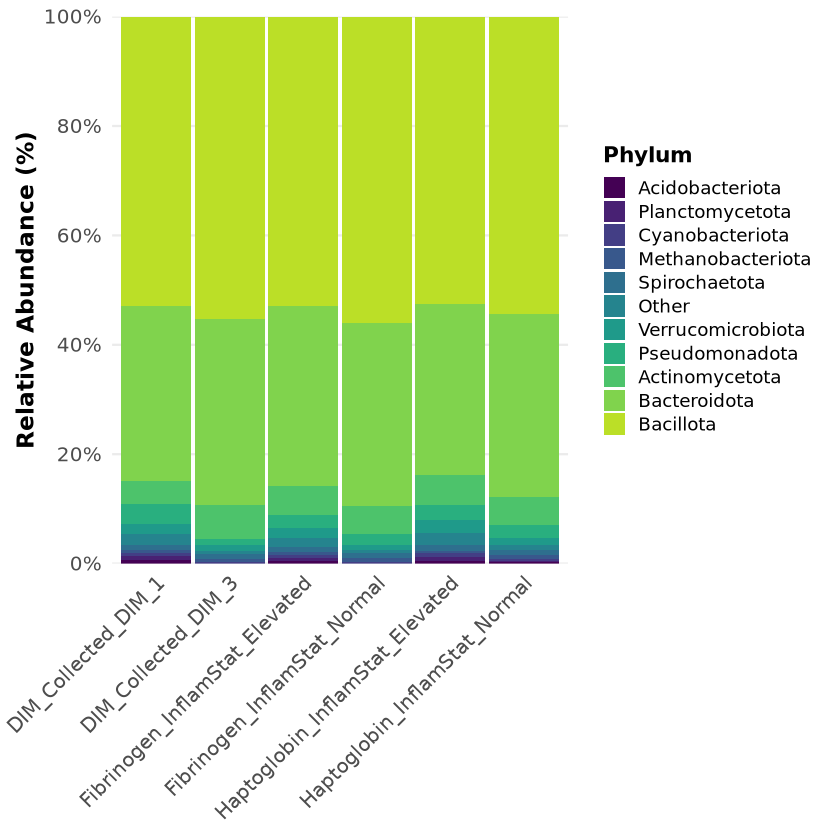

In [187]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(scales)
library(viridis)
library(ggpubr)

# ----------- Clean Taxonomy -----------
tax_clean <- tax_table(ps) %>% as.data.frame()
for (i in seq_along(tax_clean)) {
  tax_clean[[i]] <- as.character(tax_clean[[i]])
  tax_clean[[i]][is.na(tax_clean[[i]]) | tax_clean[[i]] == ""] <- paste("Unclassified", colnames(tax_clean)[i])
}
tax_table(ps) <- tax_table(as.matrix(tax_clean))

# ----------- Relative Abundance Preparation Function -----------
prepare_phylum_plot_data <- function(group_var, top_n = 10) {
  meta <- sample_data(ps) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Phylum")
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df$Phylum <- as.character(df$Phylum)
  df$Phylum[is.na(df$Phylum) | df$Phylum == ""] <- "Unclassified_Phylum"

  top_phyla <- df %>%
    group_by(Phylum) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    arrange(desc(MeanRA)) %>%
    slice_head(n = top_n) %>%
    pull(Phylum)

  df$Phylum <- ifelse(df$Phylum %in% top_phyla, df$Phylum, "Other")

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, Phylum) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, Phylum) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Plotting Function -----------
plot_phylum_abundance <- function(df, output_prefix = "phylum_abundance", output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  df$Phylum <- fct_reorder(df$Phylum, df$RelAbundance, .fun = sum)

  p <- ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = Phylum)) +
    geom_col(width = 0.95, position = position_stack(reverse = TRUE), na.rm = TRUE) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = "Phylum"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )

  ggsave(file.path(output_dir, paste0(output_prefix, ".tiff")), plot = p, width = 10, height = 6, dpi = 300)
  ggsave(file.path(output_dir, paste0(output_prefix, ".png")), plot = p, width = 10, height = 6, dpi = 300)

  return(p)
}

# ----------- Generate and Plot Data -----------
df_phylum <- bind_rows(
  prepare_phylum_plot_data("Haptoglobin_InflamStat", top_n = 10),
  prepare_phylum_plot_data("Fibrinogen_InflamStat", top_n = 10),
  prepare_phylum_plot_data("DIM_Collected", top_n = 10)
)

plot_phylum_abundance(df_phylum, output_prefix = "phylum_abundance")


In [182]:

# Load package
library(writexl)

# Agglomerate to Phylum level and compute relative abundance
ps_phylum <- tax_glom(ps, taxrank = "Phylum")
ps_phylum_rel <- transform_sample_counts(ps_phylum, function(x) x / sum(x))

# Convert to long format
df_phylum_long <- psmelt(ps_phylum_rel)
df_phylum_long$Phylum <- as.character(df_phylum_long$Phylum)
df_phylum_long$Phylum[is.na(df_phylum_long$Phylum) | df_phylum_long$Phylum == ""] <- "Unclassified_Phylum"

# Summarize and pivot to wide format
df_phylum_wide <- df_phylum_long %>%
  group_by(Sample, Phylum) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Phylum, values_from = RelAbundance, values_fill = 0)

# Save as Excel file
write_xlsx(df_phylum_wide, "Phylum_Relative_Abundance_Per_Sample.xlsx")


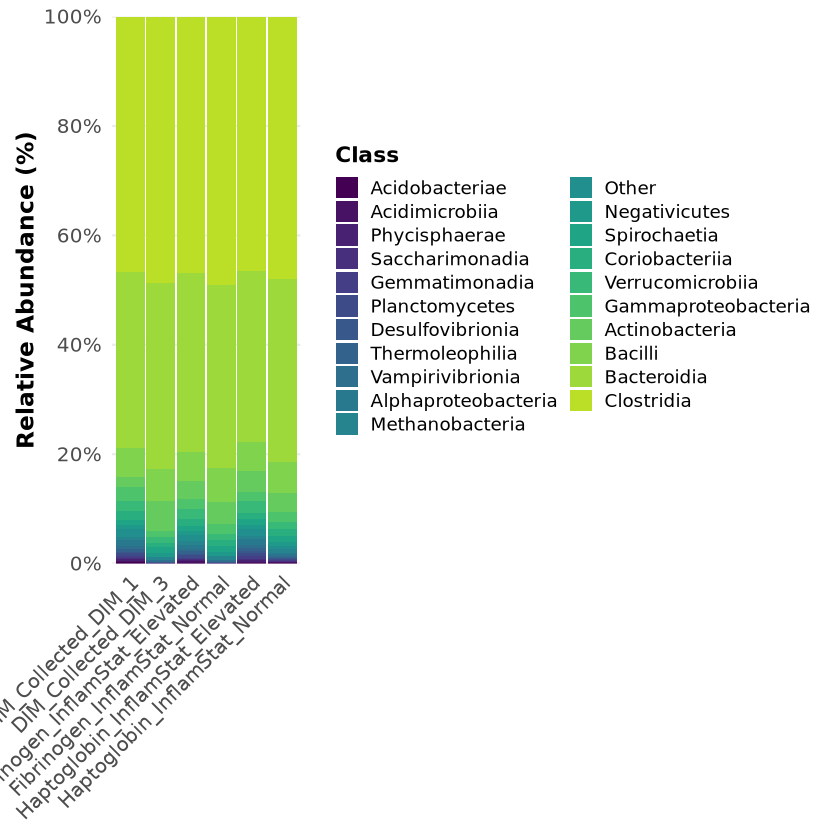

In [188]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(scales)
library(viridis)
library(ggpubr)

# ----------- Relative Abundance Preparation Function for Class -----------
prepare_class_plot_data <- function(group_var, top_n = 20) {
  meta <- sample_data(ps) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Class")
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df$Class <- as.character(df$Class)
  df$Class[is.na(df$Class) | df$Class == ""] <- "Unclassified_Class"

  top_classes <- df %>%
    group_by(Class) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    arrange(desc(MeanRA)) %>%
    slice_head(n = top_n) %>%
    pull(Class)

  df$Class <- ifelse(df$Class %in% top_classes, df$Class, "Other")

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, Class) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, Class) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Plotting Function -----------
plot_class_abundance <- function(df, output_prefix = "class_abundance", output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  df$Class <- fct_reorder(df$Class, df$RelAbundance, .fun = sum)

  p <- ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = Class)) +
    geom_col(width = 0.95, position = position_stack(reverse = TRUE), na.rm = TRUE) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = "Class"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )

  ggsave(file.path(output_dir, paste0(output_prefix, ".tiff")), plot = p, width = 10, height = 6, dpi = 300)
  ggsave(file.path(output_dir, paste0(output_prefix, ".png")), plot = p, width = 10, height = 6, dpi = 300)

  return(p)
}

# ----------- Generate and Plot Data -----------
df_class <- bind_rows(
  prepare_class_plot_data("Haptoglobin_InflamStat", top_n = 20),
  prepare_class_plot_data("Fibrinogen_InflamStat", top_n = 20),
  prepare_class_plot_data("DIM_Collected", top_n = 20)
)

plot_class_abundance(df_class, output_prefix = "class_abundance")


In [189]:
# Agglomerate to Class level and compute relative abundance
ps_class <- tax_glom(ps, taxrank = "Class")
ps_class_rel <- transform_sample_counts(ps_class, function(x) x / sum(x))

# Convert to long format
df_class_long <- psmelt(ps_class_rel)
df_class_long$Class <- as.character(df_class_long$Class)
df_class_long$Class[is.na(df_class_long$Class) | df_class_long$Class == ""] <- "Unclassified_Class"

# Summarize and pivot to wide format
df_class_wide <- df_class_long %>%
  group_by(Sample, Class) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Class, values_from = RelAbundance, values_fill = 0)

# Save as Excel file
write_xlsx(df_class_wide, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Class_Relative_Abundance_Per_Sample.xlsx")

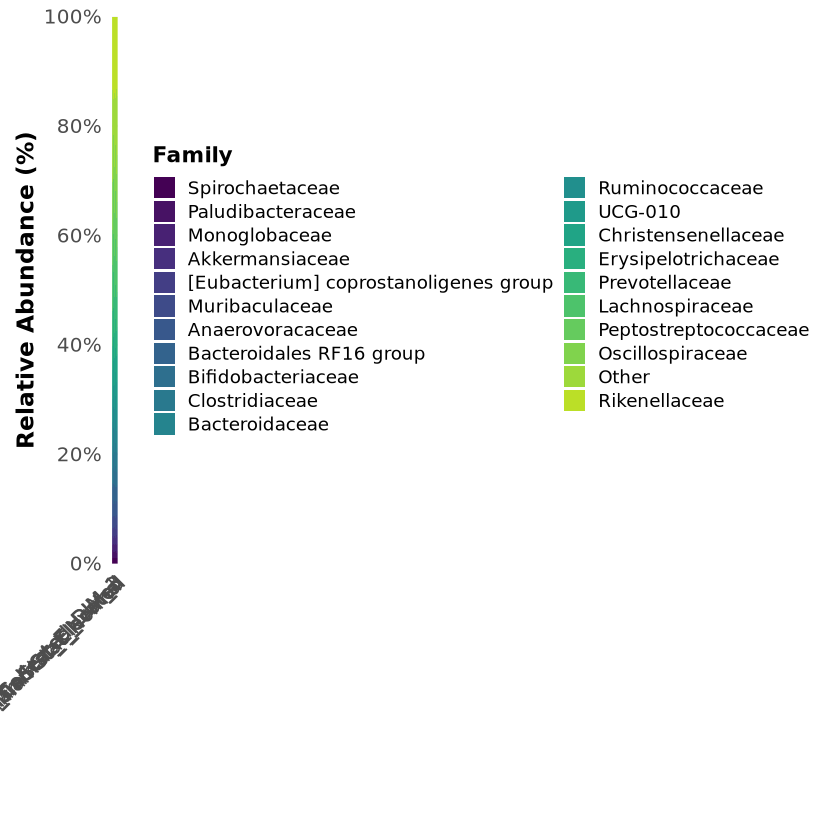

In [191]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(scales)
library(viridis)
library(ggpubr)

# ----------- Plot Data Preparation Function -----------
prepare_family_plot_data <- function(group_var, top_n = 20) {
  meta <- sample_data(ps) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = "Family")
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df$Family <- as.character(df$Family)
  df$Family[is.na(df$Family) | df$Family == ""] <- "Unclassified_Family"

  top_families <- df %>%
    group_by(Family) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    arrange(desc(MeanRA)) %>%
    slice_head(n = top_n) %>%
    pull(Family)

  df$Family <- ifelse(df$Family %in% top_families, df$Family, "Other")

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, Family) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, Family) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Plotting Function -----------
plot_family_abundance <- function(df, output_prefix = "family_abundance", output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  df$Family <- fct_reorder(df$Family, df$RelAbundance, .fun = sum)

  p <- ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = Family)) +
    geom_col(width = 0.95, position = position_stack(reverse = TRUE), na.rm = TRUE) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = "Family"
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )

  ggsave(file.path(output_dir, paste0(output_prefix, ".tiff")), plot = p, width = 10, height = 6, dpi = 300)
  ggsave(file.path(output_dir, paste0(output_prefix, ".png")), plot = p, width = 10, height = 6, dpi = 300)

  return(p)
}

# ----------- Generate and Plot Data -----------
df_family <- bind_rows(
  prepare_family_plot_data("Haptoglobin_InflamStat", top_n = 20),
  prepare_family_plot_data("Fibrinogen_InflamStat", top_n = 20),
  prepare_family_plot_data("DIM_Collected", top_n = 20)
)

plot_family_abundance(df_family, output_prefix = "family_abundance")


In [190]:
# Agglomerate to Family level and compute relative abundance
ps_family <- tax_glom(ps, taxrank = "Family")
ps_family_rel <- transform_sample_counts(ps_family, function(x) x / sum(x))

# Convert to long format
df_family_long <- psmelt(ps_family_rel)
df_family_long$Family <- as.character(df_family_long$Family)
df_family_long$Family[is.na(df_family_long$Family) | df_family_long$Family == ""] <- "Unclassified_Family"

# Summarize and pivot to wide format
df_family_wide <- df_family_long %>%
  group_by(Sample, Family) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Family, values_from = RelAbundance, values_fill = 0)

# Save as Excel file
write_xlsx(df_family_wide, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Family_Relative_Abundance_Per_Sample.xlsx")


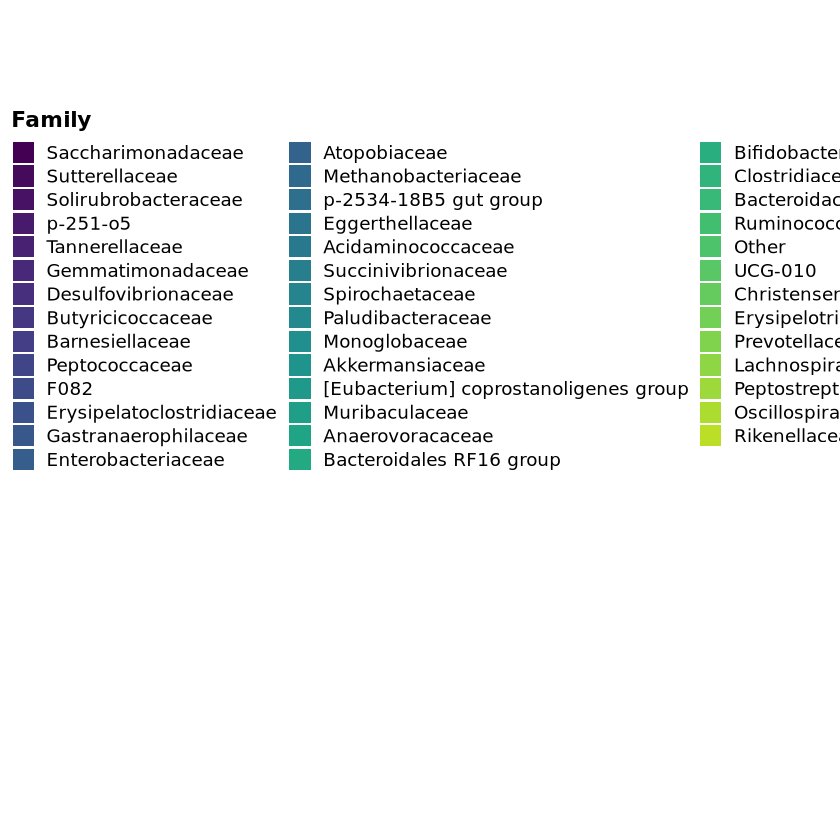

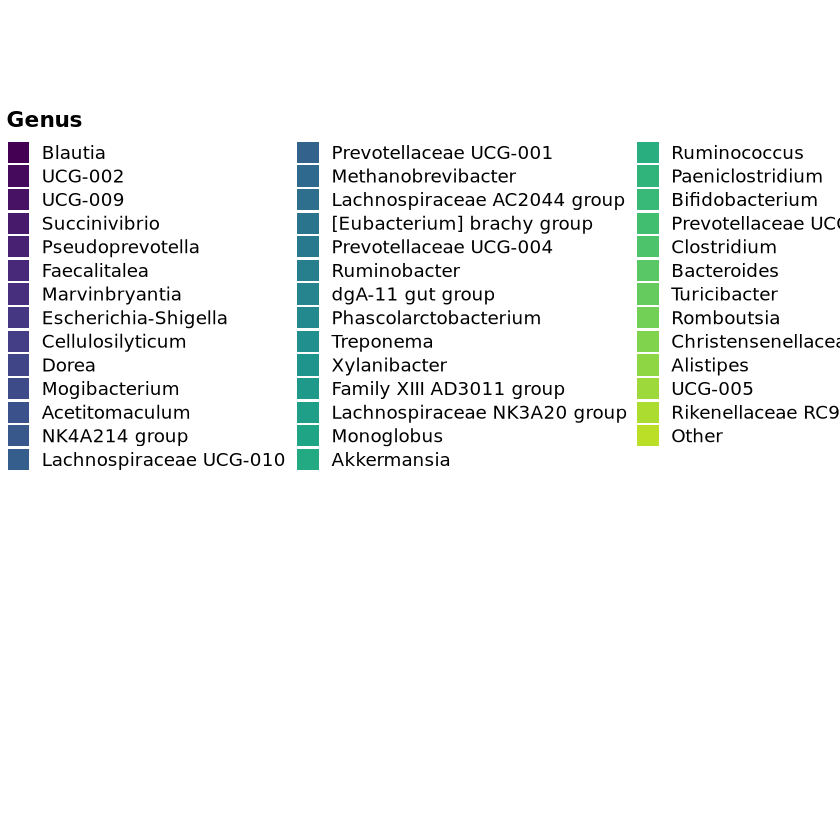

In [194]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(scales)
library(viridis)
library(ggpubr)

# ----------- Function for Family/Genus Relative Abundance -----------
prepare_taxa_plot_data <- function(group_var, taxrank = "Family", top_n = 40) {
  meta <- sample_data(ps) %>% as.data.frame()
  meta <- meta[!is.na(meta[[group_var]]), ]

  if (group_var %in% c("DIM", "DIM_Collected")) {
    meta[[group_var]] <- paste0("DIM_", as.character(meta[[group_var]]))
  }

  ps_sub <- prune_samples(rownames(meta), ps)
  sample_data(ps_sub)[[group_var]] <- meta[[group_var]]

  ps_tax <- tax_glom(ps_sub, taxrank = taxrank)
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df[[taxrank]] <- as.character(df[[taxrank]])
  df[[taxrank]][is.na(df[[taxrank]]) | df[[taxrank]] == ""] <- paste0("Unclassified_", taxrank)

  top_taxa <- df %>%
    group_by(!!sym(taxrank)) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    arrange(desc(MeanRA)) %>%
    slice_head(n = top_n) %>%
    pull(!!sym(taxrank))

  df[[taxrank]] <- ifelse(df[[taxrank]] %in% top_taxa, df[[taxrank]], "Other")

  df <- df %>%
    group_by(Sample) %>%
    mutate(Abundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df$CompositeGroup <- paste0(group_var, "_", df[[group_var]])

  df_summary <- df %>%
    group_by(Sample, CompositeGroup, !!sym(taxrank)) %>%
    summarise(Abundance = sum(Abundance), .groups = "drop") %>%
    group_by(Sample, CompositeGroup) %>%
    mutate(RelAbundance = Abundance / sum(Abundance)) %>%
    ungroup()

  df_summary %>%
    group_by(CompositeGroup, !!sym(taxrank)) %>%
    summarise(RelAbundance = mean(RelAbundance), .groups = "drop") %>%
    group_by(CompositeGroup) %>%
    mutate(RelAbundance = ifelse(row_number() == n(),
                                 pmin(RelAbundance, 1 - sum(RelAbundance[-n()])),
                                 RelAbundance)) %>%
    ungroup()
}

# ----------- Plotting Function -----------
plot_taxa_abundance <- function(df, taxrank, output_prefix, output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  df[[taxrank]] <- fct_reorder(df[[taxrank]], df$RelAbundance, .fun = sum)

  p <- ggplot(df, aes(x = CompositeGroup, y = RelAbundance * 100, fill = !!sym(taxrank))) +
    geom_col(width = 0.95, position = position_stack(reverse = TRUE), na.rm = TRUE) +
    scale_y_continuous(
      labels = function(x) paste0(x, "%"),
      limits = c(0, 100),
      breaks = seq(0, 100, by = 20),
      expand = c(0, 0)
    ) +
    scale_fill_viridis_d(option = "D", begin = 0, end = 0.9) +
    labs(
      x = NULL,
      y = "Relative Abundance (%)",
      fill = taxrank
    ) +
    theme_minimal(base_size = 14) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title.y = element_text(size = 14, face = "bold"),
      legend.title = element_text(size = 13, face = "bold"),
      legend.text = element_text(size = 11),
      legend.key.height = unit(0.5, "cm"),
      legend.key.width = unit(0.5, "cm"),
      panel.grid.major.x = element_blank(),
      panel.grid.minor = element_blank(),
      plot.margin = margin(10, 10, 10, 10)
    )

  ggsave(file.path(output_dir, paste0(output_prefix, ".tiff")), plot = p, width = 10, height = 6, dpi = 300)
  ggsave(file.path(output_dir, paste0(output_prefix, ".png")), plot = p, width = 10, height = 6, dpi = 300)

  return(p)
}

# ----------- Generate and Plot Family-Level Data -----------
df_family <- bind_rows(
  prepare_taxa_plot_data("Haptoglobin_InflamStat", taxrank = "Family", top_n = 40),
  prepare_taxa_plot_data("Fibrinogen_InflamStat", taxrank = "Family", top_n = 40),
  prepare_taxa_plot_data("DIM_Collected", taxrank = "Family", top_n = 40)
)

plot_taxa_abundance(df_family, taxrank = "Family", output_prefix = "family_abundance")

# ----------- Generate and Plot Genus-Level Data -----------
df_genus <- bind_rows(
  prepare_taxa_plot_data("Haptoglobin_InflamStat", taxrank = "Genus", top_n = 40),
  prepare_taxa_plot_data("Fibrinogen_InflamStat", taxrank = "Genus", top_n = 40),
  prepare_taxa_plot_data("DIM_Collected", taxrank = "Genus", top_n = 40)
)

plot_taxa_abundance(df_genus, taxrank = "Genus", output_prefix = "genus_abundance")


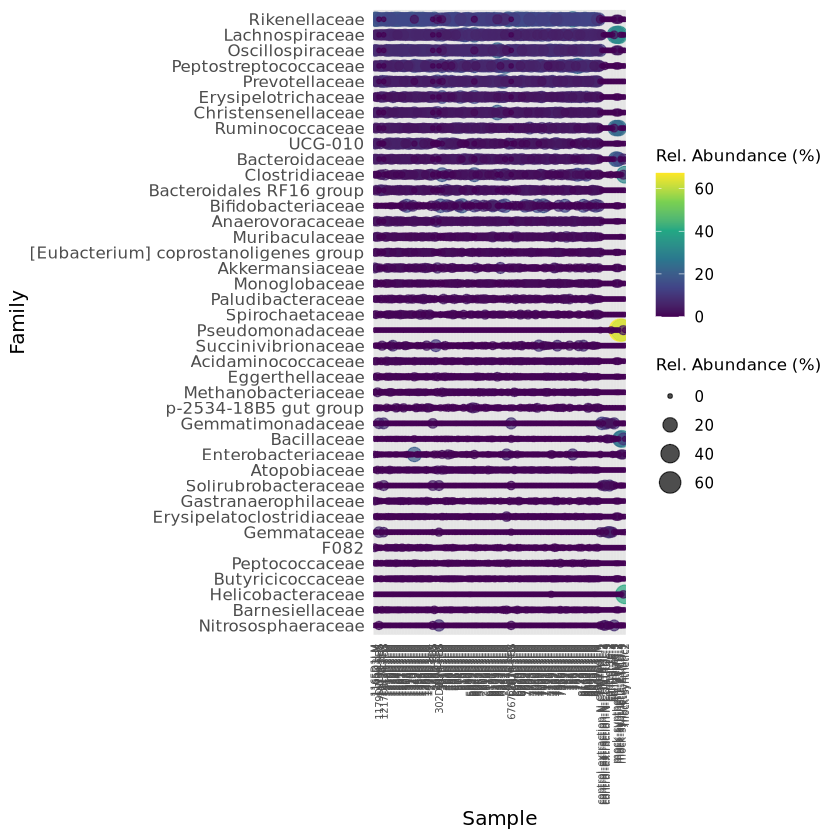

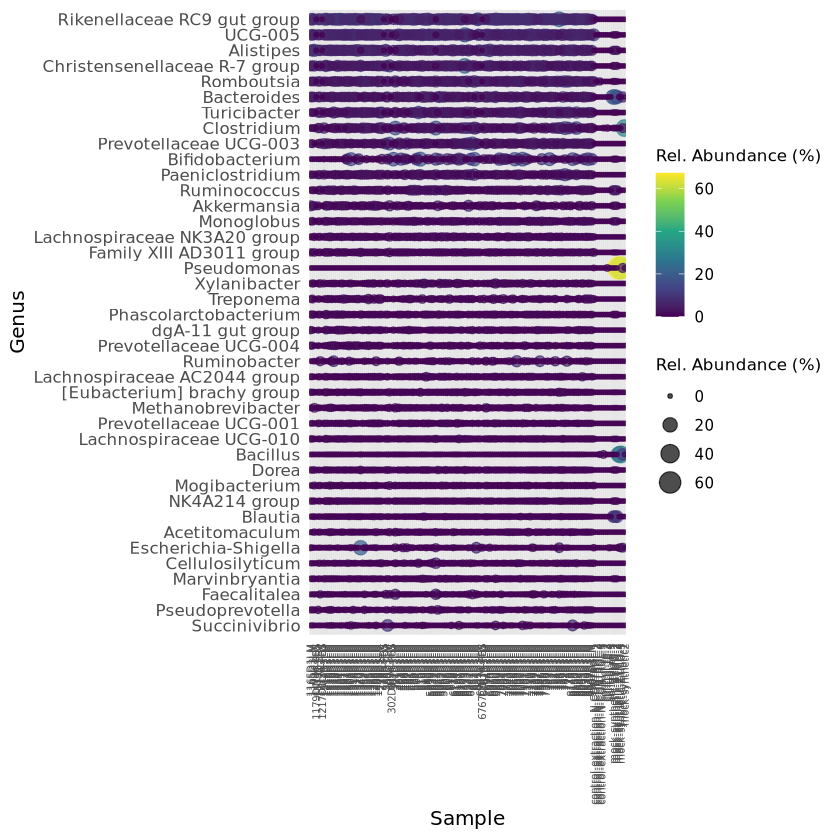

In [195]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(tidyr)
library(ggplot2)
library(forcats)
library(scales)
library(viridis)
library(ggpubr)
library(pheatmap)
library(reshape2)

# ----------- Relative Abundance Dot Plot Function -----------
prepare_dotplot_data <- function(taxrank = "Family", top_n = 40) {
  ps_tax <- tax_glom(ps, taxrank = taxrank)
  ps_rel <- transform_sample_counts(ps_tax, function(x) x / sum(x))
  df <- psmelt(ps_rel)

  df[[taxrank]] <- as.character(df[[taxrank]])
  df[[taxrank]][is.na(df[[taxrank]]) | df[[taxrank]] == ""] <- paste0("Unclassified_", taxrank)

  top_taxa <- df %>%
    group_by(!!sym(taxrank)) %>%
    summarise(MeanRA = mean(Abundance), .groups = "drop") %>%
    arrange(desc(MeanRA)) %>%
    slice_head(n = top_n) %>%
    pull(!!sym(taxrank))

  df <- df %>%
    filter(!!sym(taxrank) %in% top_taxa)

  df$Sample <- as.factor(df$Sample)
  df[[taxrank]] <- factor(df[[taxrank]], levels = rev(top_taxa))

  return(df)
}

plot_dotplot_abundance <- function(df, taxrank, output_prefix = "dotplot_abundance", output_dir = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs") {
  p <- ggplot(df, aes(x = Sample, y = !!sym(taxrank), size = Abundance * 100, color = Abundance * 100)) +
    geom_point(alpha = 0.7) +
    scale_size_continuous(name = "Rel. Abundance (%)") +
    scale_color_viridis_c(name = "Rel. Abundance (%)") +
    labs(x = "Sample", y = taxrank) +
    theme_minimal(base_size = 12) +
    theme(
      axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1, size = 6),
      axis.text.y = element_text(size = 10),
      legend.title = element_text(size = 10),
      legend.text = element_text(size = 9),
      panel.grid.major = element_line(color = "grey90")
    )

  ggsave(file.path(output_dir, paste0(output_prefix, ".tiff")), plot = p, width = 12, height = 8, dpi = 300)
  ggsave(file.path(output_dir, paste0(output_prefix, ".png")), plot = p, width = 12, height = 8, dpi = 300)
  return(p)
}

# ----------- Generate and Save Dot Plots -----------
df_family_dot <- prepare_dotplot_data(taxrank = "Family", top_n = 40)
df_genus_dot <- prepare_dotplot_data(taxrank = "Genus", top_n = 40)

plot_dotplot_abundance(df_family_dot, taxrank = "Family", output_prefix = "family_dotplot")
plot_dotplot_abundance(df_genus_dot, taxrank = "Genus", output_prefix = "genus_dotplot")


In [196]:
# ----------- Save Family and Genus Relative Abundance as Excel -----------

library(writexl)

# ----- Family-Level Table -----
ps_family <- tax_glom(ps, taxrank = "Family")
ps_family_rel <- transform_sample_counts(ps_family, function(x) x / sum(x))
df_family_long <- psmelt(ps_family_rel)
df_family_long$Family <- as.character(df_family_long$Family)
df_family_long$Family[is.na(df_family_long$Family) | df_family_long$Family == ""] <- "Unclassified_Family"

df_family_wide <- df_family_long %>%
  group_by(Sample, Family) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Family, values_from = RelAbundance, values_fill = 0)

write_xlsx(df_family_wide, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Family_Relative_Abundance_Per_Sample.xlsx")

# ----- Genus-Level Table -----
ps_genus <- tax_glom(ps, taxrank = "Genus")
ps_genus_rel <- transform_sample_counts(ps_genus, function(x) x / sum(x))
df_genus_long <- psmelt(ps_genus_rel)
df_genus_long$Genus <- as.character(df_genus_long$Genus)
df_genus_long$Genus[is.na(df_genus_long$Genus) | df_genus_long$Genus == ""] <- "Unclassified_Genus"

df_genus_wide <- df_genus_long %>%
  group_by(Sample, Genus) %>%
  summarise(RelAbundance = sum(Abundance), .groups = "drop") %>%
  pivot_wider(names_from = Genus, values_from = RelAbundance, values_fill = 0)

write_xlsx(df_genus_wide, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Genus_Relative_Abundance_Per_Sample.xlsx")

                                        

In [142]:
# Load libraries
library(phyloseq)
library(vegan)
library(dplyr)

# Load your phyloseq object
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")

# Create Bray–Curtis dissimilarity matrix
bray_dist <- phyloseq::distance(ps, method = "bray")

# Extract sample metadata
meta <- as(sample_data(ps), "data.frame")

# Define variables to test
variables <- c("Haptoglobin_InflamStat", 
               "Fibrinogen_InflamStat", 
               "Parity", 
               "DIM_Collected", 
               "BCS")

# Filter available variables
available_vars <- variables[variables %in% colnames(meta)]

# Initialize result list
results <- list()

# Run PERMANOVA for each variable
for (var in available_vars) {
  # Subset metadata to complete cases
  sub_meta <- meta[!is.na(meta[[var]]), , drop = FALSE]
  sub_meta$SampleID <- rownames(sub_meta)

  # Subset distance matrix to same samples
  samples_to_keep <- sub_meta$SampleID
  dist_sub <- as.matrix(bray_dist)[samples_to_keep, samples_to_keep]
  dist_sub <- as.dist(dist_sub)

  # Run adonis2
  formula <- as.formula(paste("dist_sub ~", var))
  adonis_res <- adonis2(formula, data = sub_meta)

  # Store result
  results[[var]] <- data.frame(
    Variable = var,
    R_squared = adonis_res$R2[1],
    p_value = adonis_res$`Pr(>F)`[1]
  )
}

# Combine all results into a single summary table
summary_table <- bind_rows(results)

# View
print(summary_table)
write_xlsx(summary_table, path = "/scratch/negishi/ldas/COW_INFLAMMATION/PERMANOVA_Results.xlsx")


                Variable  R_squared p_value
1 Haptoglobin_InflamStat 0.01040144   0.062
2  Fibrinogen_InflamStat 0.01033280   0.033
3                 Parity 0.01859795   0.001
4          DIM_Collected 0.06017786   0.001
5                    BCS 0.01648830   0.001


In [214]:
# ----------- PERMANOVA for Each Variable (Univariate) -----------
bray_dist <- phyloseq::distance(ps, method = "bray")
meta <- as(sample_data(ps), "data.frame")
variables <- c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat", "Parity", "DIM_Collected", "BCS")
available_vars <- variables[variables %in% colnames(meta)]

permanova_results <- list()

for (var in available_vars) {
  sub_meta <- meta[!is.na(meta[[var]]), , drop = FALSE]
  sub_meta$SampleID <- rownames(sub_meta)
  samples_to_keep <- sub_meta$SampleID
  dist_sub <- as.matrix(bray_dist)[samples_to_keep, samples_to_keep]
  dist_sub <- as.dist(dist_sub)

  formula <- as.formula(paste("dist_sub ~", var))
  adonis_res <- adonis2(formula, data = sub_meta, permutations = 999)

  permanova_results[[var]] <- data.frame(
    Variable = var,
    R2 = adonis_res$R2[1],
    p_value = adonis_res$`Pr(>F)`[1]
  )
}

permanova_table <- bind_rows(permanova_results)
write_xlsx(permanova_table, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/PERMANOVA_Univariate_Results.xlsx")

# ----------- PERMANOVA Multivariate Model -----------
# Remove rows with NA in any tested variable
meta_complete <- meta %>%
  select(all_of(variables)) %>%
  drop_na()

bray_complete <- as.matrix(bray_dist)[rownames(meta_complete), rownames(meta_complete)]
bray_complete <- as.dist(bray_complete)

# Fit multivariate PERMANOVA
adonis_full <- adonis2(
  bray_complete ~ Haptoglobin_InflamStat + Fibrinogen_InflamStat + Parity + DIM_Collected + BCS,
  data = meta_complete,
  permutations = 999
)

# Save full model output
adonis_full_df <- as.data.frame(adonis_full)
write_xlsx(adonis_full_df, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/PERMANOVA_Multivariate_Results.xlsx")


In [200]:
# ----------- Load Required Libraries -----------
library(phyloseq)
library(dplyr)
library(broom)
library(writexl)

# ----------- Load Phyloseq Object -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")

# ----------- Estimate Alpha Diversity -----------
alpha_df <- estimate_richness(ps, measures = c("Observed", "Shannon", "Simpson"))
alpha_df <- cbind(alpha_df, as(sample_data(ps), "data.frame"))

# ----------- Define Full Model Formula -----------
model_formula <- Observed ~ Haptoglobin_InflamStat + Fibrinogen_InflamStat + Parity + DIM_Collected + BCS

# ----------- Fit Linear Models -----------
fit_observed <- aov(model_formula, data = alpha_df)
fit_shannon  <- aov(update(model_formula, Shannon ~ .), data = alpha_df)
fit_simpson  <- aov(update(model_formula, Simpson ~ .), data = alpha_df)

# ----------- Tidy Output and Save as Excel -----------
anova_tidy <- list(
  Observed = tidy(fit_observed),
  Shannon  = tidy(fit_shannon),
  Simpson  = tidy(fit_simpson)
)

# Flatten list and add diversity metric as column
anova_table <- bind_rows(anova_tidy, .id = "Diversity_Metric")

# Save to Excel
write_xlsx(anova_table, path = "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/AlphaDiversity_ANOVA_Results.xlsx")


In [207]:
# ----------- Alpha Diversity Plotting by Group -----------
library(ggpubr)

# Define diversity metrics to plot
diversity_metrics <- c("Observed", "Chao1", "Shannon", "Simpson", "pielou")

# Define grouping variables to compare
group_vars <- c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat", "Parity", "DIM_Collected", "BCS")

# Output directory
plot_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

# Loop over metrics and group variables
for (metric in diversity_metrics) {
  for (group in group_vars) {
    if (!group %in% colnames(alpha_df)) next

    df_plot <- alpha_df %>%
      filter(!is.na(.data[[group]]), !is.na(.data[[metric]]))

    if (length(unique(df_plot[[group]])) < 2) next

    max_y <- max(df_plot[[metric]], na.rm = TRUE)

    p <- ggboxplot(
      df_plot, x = group, y = metric,
      color = group, palette = "jco",
      add = "jitter"
    ) +
      stat_compare_means(method = "anova", label.y = max_y * 1.05) +
      labs(
        title = paste(metric, "by", group),
        y = metric, x = group
      ) +
      theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(face = "bold")
      )

    # Save plots
    ggsave(filename = paste0(plot_dir, "/", metric, "_by_", group, ".tiff"), plot = p, width = 7, height = 5, dpi = 300)
    ggsave(filename = paste0(plot_dir, "/", metric, "_by_", group, ".png"), plot = p, width = 7, height = 5, dpi = 300)
  }
}


In [208]:
# Load required library
library(ggpubr)

# Create a list of selected metric and group combinations
selected_metrics <- list(
  list(metric = "Shannon", group = "BCS"),
  list(metric = "Simpson", group = "DIM_Collected"),
  list(metric = "Simpson", group = "BCS")
)

# Output directory
output_dir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

# Create individual plots
plot_list <- list()

for (i in seq_along(selected_metrics)) {
  metric <- selected_metrics[[i]]$metric
  group <- selected_metrics[[i]]$group

  df_plot <- alpha_df %>%
    filter(!is.na(.data[[group]]), !is.na(.data[[metric]]))

  if (length(unique(df_plot[[group]])) < 2) next

  p <- ggboxplot(
    df_plot, x = group, y = metric,
    color = group, palette = "jco", add = "jitter"
  ) +
    stat_compare_means(method = "anova", label.y = max(df_plot[[metric]], na.rm = TRUE) * 1.1) +
    labs(
      title = paste(metric, "by", group),
      y = metric, x = group
    ) +
    theme_minimal(base_size = 12) +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1),
      plot.title = element_text(face = "bold", hjust = 0.5)
    )

  plot_list[[paste(metric, group, sep = "_")]] <- p
}

# Combine into one figure
composite_plot <- ggarrange(
  plotlist = plot_list,
  ncol = 2, nrow = 2,
  labels = LETTERS[1:length(plot_list)]
)

# Save figure
ggsave(file.path(output_dir, "AlphaDiversity_Significant_Metrics.tiff"), composite_plot, dpi = 300, width = 10, height = 8)
ggsave(file.path(output_dir, "AlphaDiversity_Significant_Metrics.png"), composite_plot, dpi = 300, width = 10, height = 8)


In [213]:
# ----------- Multivariate Linear Models on Alpha Diversity -----------
model_formula <- Observed ~ Haptoglobin_InflamStat + Fibrinogen_InflamStat + Parity + DIM_Collected + BCS

# Remove rows with missing predictors or only one level in any factor
predictors <- all.vars(model_formula)
alpha_df_model <- alpha_df %>%
  dplyr::select(all_of(c("Observed", "Chao1", "Shannon", "Simpson", "pielou", predictors))) %>%
  filter(complete.cases(.))

# Drop levels with <2 levels (to prevent contrast error)
for (var in predictors) {
  if (is.factor(alpha_df_model[[var]]) && nlevels(droplevels(alpha_df_model[[var]])) < 2) {
    alpha_df_model[[var]] <- NULL
    message(paste("Dropped variable:", var, "- only one level present"))
  }
}

# Update model formula with remaining predictors
remaining_predictors <- setdiff(colnames(alpha_df_model), c("Observed", "Chao1", "Shannon", "Simpson", "pielou"))
model_formula_updated <- as.formula(paste("Observed ~", paste(remaining_predictors, collapse = " + ")))

# Fit models
fit_observed <- lm(model_formula_updated, data = alpha_df_model)
fit_chao1    <- lm(update(model_formula_updated, Chao1 ~ .), data = alpha_df_model)
fit_shannon  <- lm(update(model_formula_updated, Shannon ~ .), data = alpha_df_model)
fit_simpson  <- lm(update(model_formula_updated, Simpson ~ .), data = alpha_df_model)
fit_evenness <- lm(update(model_formula_updated, pielou ~ .), data = alpha_df_model)

# ANOVA results
anova_results <- list(
  Observed = summary(aov(fit_observed)),
  Chao1 = summary(aov(fit_chao1)),
  Shannon = summary(aov(fit_shannon)),
  Simpson = summary(aov(fit_simpson)),
  Evenness = summary(aov(fit_evenness))
)

anova_tidy <- lapply(anova_results, broom::tidy)
alpha_anova_table <- bind_rows(anova_tidy, .id = "Diversity_Metric")

# Save
write_xlsx(alpha_anova_table, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/AlphaDiversity_Multivariate_ANOVA.xlsx")


# ----------- PERMANOVA for Each Variable (Univariate) -----------
bray_dist <- phyloseq::distance(ps, method = "bray")
meta <- as(sample_data(ps), "data.frame")
variables <- c("Haptoglobin_InflamStat", "Fibrinogen_InflamStat", "Parity", "DIM_Collected", "BCS")
available_vars <- variables[variables %in% colnames(meta)]

permanova_results <- list()

for (var in available_vars) {
  sub_meta <- meta[!is.na(meta[[var]]), , drop = FALSE]
  sub_meta$SampleID <- rownames(sub_meta)
  samples_to_keep <- sub_meta$SampleID
  dist_sub <- as.matrix(bray_dist)[samples_to_keep, samples_to_keep]
  dist_sub <- as.dist(dist_sub)

  formula <- as.formula(paste("dist_sub ~", var))
  adonis_res <- adonis2(formula, data = sub_meta, permutations = 999)

  permanova_results[[var]] <- data.frame(
    Variable = var,
    R2 = adonis_res$R2[1],
    p_value = adonis_res$`Pr(>F)`[1]
  )
}

permanova_table <- bind_rows(permanova_results)
write_xlsx(permanova_table, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/PERMANOVA_Univariate_Results.xlsx")


ERROR: Error in `contrasts<-`(`*tmp*`, value = contr.funs[1 + isOF[nn]]): contrasts can be applied only to factors with 2 or more levels


In [53]:
library(phyloseq)
library(vegan)
library(dplyr)

# Load phyloseq object
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")

# Create Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(ps, method = "bray")

# Extract sample metadata
meta <- as(sample_data(ps), "data.frame")

# Define variables to test
variables <- c("Haptoglobin_InflamStat", 
               "Fibrinogen_InflamStat", 
               "Parity", 
               "DIM_Collected", 
               "BCS")

# Filter to only available columns
available_vars <- intersect(variables, colnames(meta))

# Run PERMANOVA per variable, excluding NAs
results <- lapply(available_vars, function(var) {
  df <- meta[, var, drop = FALSE]
  df$SampleID <- rownames(df)
  df <- df[complete.cases(df), ]
  
  samples_to_keep <- df$SampleID
  dist_sub <- as.matrix(bray_dist)[samples_to_keep, samples_to_keep]
  
  adonis2(as.dist(dist_sub) ~ ., data = df[, var, drop = FALSE])
})

# Summarize results
summary_table <- bind_rows(lapply(seq_along(results), function(i) {
  res <- results[[i]]
  data.frame(
    Variable = available_vars[i],
    R_squared = res$R2[1],
    p_value = res$`Pr(>F)`[1]
  )
}))

# View results
print(summary_table)


                Variable  R_squared p_value
1 Haptoglobin_InflamStat 0.01040144   0.035
2  Fibrinogen_InflamStat 0.01033280   0.035
3                 Parity 0.01859795   0.001
4          DIM_Collected 0.06017786   0.001
5                    BCS 0.01648830   0.002


In [22]:
### Betadiversity Fibrinogen InflamStat
library(phyloseq)
library(ggplot2)
library(ggpubr)
library(vegan)
library(microbiome)

# ----------- Load Phyloseq Objects -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")
ps_tree <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.tree.rooted.rds")

# ----------- Filter Samples with Valid Fibrinogen_InflamStat -----------
sample_data_df <- data.frame(sample_data(ps))
non_na_ix <- !is.na(sample_data_df$Fibrinogen_InflamStat)
ps_filt <- prune_samples(non_na_ix, ps)
filtered_sample_data <- sample_data_df[non_na_ix, ]
ps_tree_filt <- prune_samples(non_na_ix, ps_tree)

# ----------- Bray–Curtis -----------
bray_dist <- phyloseq::distance(ps_filt, method = "bray")
ordination_bray <- ordinate(ps_filt, method = "PCoA", distance = bray_dist)
adonis_bray <- adonis2(bray_dist ~ Fibrinogen_InflamStat, data = filtered_sample_data, permutations = 999)
bray_r2 <- formatC(adonis_bray$R2[1], digits = 3)
bray_p <- formatC(adonis_bray$`Pr(>F)`[1], format = "e", digits = 2)

p_bray <- plot_ordination(ps_filt, ordination_bray, color = "Fibrinogen_InflamStat") +
  geom_point(size = 3.5, alpha = 0.8) +
  stat_ellipse(type = "t", linetype = 1, size = 0.8, alpha = 0.4) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Bray–Curtis Dissimilarity (PCoA)",
    subtitle = paste("PERMANOVA: R² =", bray_r2, ", p =", bray_p),
    color = "Fibrinogen Inflammation Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12, margin = margin(b = 10))
  )

# ----------- Aitchison -----------
ps_clr <- microbiome::transform(ps_filt, "clr")
otu_mat <- as(otu_table(ps_clr), "matrix")
if (taxa_are_rows(ps_clr)) otu_mat <- t(otu_mat)
aitchison_dist <- dist(otu_mat, method = "euclidean")
ordination_aitchison <- ordinate(ps_filt, method = "PCoA", distance = aitchison_dist)
adonis_aitchison <- adonis2(aitchison_dist ~ Fibrinogen_InflamStat, data = filtered_sample_data, permutations = 999)
aitch_r2 <- formatC(adonis_aitchison$R2[1], digits = 3)
aitch_p <- formatC(adonis_aitchison$`Pr(>F)`[1], format = "e", digits = 2)

p_aitchison <- plot_ordination(ps_filt, ordination_aitchison, color = "Fibrinogen_InflamStat") +
  geom_point(size = 3.5, alpha = 0.8) +
  stat_ellipse(type = "t", linetype = 1, size = 0.8, alpha = 0.4) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Aitchison Distance (CLR, PCoA)",
    subtitle = paste("PERMANOVA: R² =", aitch_r2, ", p =", aitch_p),
    color = "Fibrinogen Inflammation Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12, margin = margin(b = 10))
  )

# ----------- Weighted UniFrac -----------
unifrac_dist <- UniFrac(ps_tree_filt, weighted = TRUE, normalized = TRUE, parallel = TRUE, fast = TRUE)
ordination_unifrac <- ordinate(ps_tree_filt, method = "PCoA", distance = unifrac_dist)
adonis_unifrac <- adonis2(unifrac_dist ~ Fibrinogen_InflamStat, data = filtered_sample_data, permutations = 999)
unifrac_r2 <- formatC(adonis_unifrac$R2[1], digits = 3)
unifrac_p <- formatC(adonis_unifrac$`Pr(>F)`[1], format = "e", digits = 2)

p_unifrac <- plot_ordination(ps_tree_filt, ordination_unifrac, color = "Fibrinogen_InflamStat") +
  geom_point(size = 3.5, alpha = 0.8) +
  stat_ellipse(type = "t", linetype = 1, size = 0.8, alpha = 0.4) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Weighted UniFrac Distance (PCoA)",
    subtitle = paste("PERMANOVA: R² =", unifrac_r2, ", p =", unifrac_p),
    color = "Fibrinogen Inflammation Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12, margin = margin(b = 10))
  )

# ----------- Combine All Plots -----------
combined_beta_plot <- ggarrange(
  p_bray, p_aitchison, p_unifrac,
  ncol = 3,
  labels = c("a", "b", "c"),
  common.legend = TRUE,
  legend = "bottom",
  font.label = list(size = 14, face = "bold")
)

# ----------- Save Plot -----------
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

ggsave(
  filename = file.path(path.figures, "beta_diversity_Fibrinogen_InflamStat.tiff"),
  plot     = combined_beta_plot,
  width    = 18,
  height   = 6,
  dpi      = 300,
  units    = "in",
  device   = "tiff"
)

ggsave(
  filename = file.path(path.figures, "beta_diversity_Fibrinogen_InflamStat.png"),
  plot     = combined_beta_plot,
  width    = 18,
  height   = 6,
  dpi      = 300,
  units    = "in"
)


In [23]:
#### Betadiversity Haptoglobin_InflamStat

# ----------- Load Phyloseq Objects -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")
ps_tree <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.tree.rooted.rds")

# ----------- Filter Samples with Valid Haptoglobin_InflamStat -----------
sample_data_df <- data.frame(sample_data(ps))
non_na_ix <- !is.na(sample_data_df$Haptoglobin_InflamStat)
ps_filt <- prune_samples(non_na_ix, ps)
filtered_sample_data <- sample_data_df[non_na_ix, ]
ps_tree_filt <- prune_samples(non_na_ix, ps_tree)

# ----------- Bray–Curtis -----------
bray_dist <- phyloseq::distance(ps_filt, method = "bray")
ordination_bray <- ordinate(ps_filt, method = "PCoA", distance = bray_dist)
adonis_bray <- adonis2(bray_dist ~ Haptoglobin_InflamStat, data = filtered_sample_data, permutations = 999)
bray_r2 <- formatC(adonis_bray$R2[1], digits = 3)
bray_p <- formatC(adonis_bray$`Pr(>F)`[1], format = "e", digits = 2)

p_bray <- plot_ordination(ps_filt, ordination_bray, color = "Haptoglobin_InflamStat") +
  geom_point(size = 3.5, alpha = 0.8) +
  stat_ellipse(type = "t", linetype = 1, size = 0.8, alpha = 0.4) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Bray–Curtis Dissimilarity (PCoA)",
    subtitle = paste("PERMANOVA: R² =", bray_r2, ", p =", bray_p),
    color = "Haptoglobin Inflammation Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12, margin = margin(b = 10))
  )

# ----------- Aitchison -----------
ps_clr <- microbiome::transform(ps_filt, "clr")
otu_mat <- as(otu_table(ps_clr), "matrix")
if (taxa_are_rows(ps_clr)) otu_mat <- t(otu_mat)
aitchison_dist <- dist(otu_mat, method = "euclidean")
ordination_aitchison <- ordinate(ps_filt, method = "PCoA", distance = aitchison_dist)
adonis_aitchison <- adonis2(aitchison_dist ~ Haptoglobin_InflamStat, data = filtered_sample_data, permutations = 999)
aitch_r2 <- formatC(adonis_aitchison$R2[1], digits = 3)
aitch_p <- formatC(adonis_aitchison$`Pr(>F)`[1], format = "e", digits = 2)

p_aitchison <- plot_ordination(ps_filt, ordination_aitchison, color = "Haptoglobin_InflamStat") +
  geom_point(size = 3.5, alpha = 0.8) +
  stat_ellipse(type = "t", linetype = 1, size = 0.8, alpha = 0.4) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Aitchison Distance (CLR, PCoA)",
    subtitle = paste("PERMANOVA: R² =", aitch_r2, ", p =", aitch_p),
    color = "Haptoglobin Inflammation Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12, margin = margin(b = 10))
  )

# ----------- Weighted UniFrac -----------
unifrac_dist <- UniFrac(ps_tree_filt, weighted = TRUE, normalized = TRUE, parallel = TRUE, fast = TRUE)
ordination_unifrac <- ordinate(ps_tree_filt, method = "PCoA", distance = unifrac_dist)
adonis_unifrac <- adonis2(unifrac_dist ~ Haptoglobin_InflamStat, data = filtered_sample_data, permutations = 999)
unifrac_r2 <- formatC(adonis_unifrac$R2[1], digits = 3)
unifrac_p <- formatC(adonis_unifrac$`Pr(>F)`[1], format = "e", digits = 2)

p_unifrac <- plot_ordination(ps_tree_filt, ordination_unifrac, color = "Haptoglobin_InflamStat") +
  geom_point(size = 3.5, alpha = 0.8) +
  stat_ellipse(type = "t", linetype = 1, size = 0.8, alpha = 0.4) +
  scale_color_brewer(palette = "Dark2") +
  labs(
    title = "Weighted UniFrac Distance (PCoA)",
    subtitle = paste("PERMANOVA: R² =", unifrac_r2, ", p =", unifrac_p),
    color = "Haptoglobin Inflammation Status"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.line = element_line(color = "black"),
    legend.position = "bottom",
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 12, margin = margin(b = 10))
  )

# ----------- Combine All Plots -----------
combined_beta_plot <- ggarrange(
  p_bray, p_aitchison, p_unifrac,
  ncol = 3,
  labels = c("a", "b", "c"),
  common.legend = TRUE,
  legend = "bottom",
  font.label = list(size = 14, face = "bold")
)

# ----------- Save Plot -----------
path.figures <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

ggsave(
  filename = file.path(path.figures, "beta_diversity_Haptoglobin_InflamStat.tiff"),
  plot     = combined_beta_plot,
  width    = 18,
  height   = 6,
  dpi      = 300,
  units    = "in",
  device   = "tiff"
)

ggsave(
  filename = file.path(path.figures, "beta_diversity_Haptoglobin_InflamStat.png"),
  plot     = combined_beta_plot,
  width    = 18,
  height   = 6,
  dpi      = 300,
  units    = "in"
)


In [ ]:
library(phyloseq)
library(Biostrings)
library(DECIPHER)
library(phangorn)
library(ape)
library(parallel)
library(BiocParallel)

# -------- Load phyloseq object --------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")

# -------- Extract ASV sequences --------
asv_seqs <- taxa_names(ps)
dna <- DNAStringSet(asv_seqs)
names(dna) <- paste0("ASV", seq_along(dna))

# -------- Align sequences using DECIPHER --------
ncores <- detectCores()
alignment <- AlignSeqs(dna, processors = ncores)

saveRDS(alignment, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Tree_alignment.rds")


# -------- Convert to phyDat format --------
phang_align <- phyDat(as(alignment, "matrix"), type = "DNA")
dm <- dist.ml(phang_align)

# -------- Build NJ tree --------
treeNJ <- NJ(dm)

saveRDS(dm, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Tree_distance_matrix.rds")


saveRDS(treeNJ, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/Tree_treeNJ.rds")
# -------- Optimize tree using GTR model --------
# Register parallel backend but leave 4 cores free
use_cores <- max(1, ncores - 4)
register(MulticoreParam(workers = use_cores))

fit <- pml(treeNJ, data = phang_align)
fit_opt <- optim.pml(
  fit,
  model = "GTR",
  optInv = TRUE,
  optGamma = TRUE,
  rearrangement = "stochastic",
  control = pml.control(trace = 0)  # 'ncore' doesn't work in pml.control; parallelization handled via BiocParallel
)

# -------- Set tip labels to ASV names --------
tree <- fit_opt$tree
tree$tip.label <- taxa_names(ps)

# -------- Save tree --------
saveRDS(tree, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/phy_tree_unifrac.rds")

# -------- Attach tree to phyloseq object --------
ps_tree <- ps
phy_tree(ps_tree) <- tree

# -------- Save updated phyloseq object --------
saveRDS(ps_tree, "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.tree.rds")

# -------- Plot tree (optional) --------
plot(tree, cex = 0.4)


Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges


Attaching package: ‘IRanges’


The following object is masked from ‘package:phyl

Determining distance matrix based on shared 8-mers:

Time difference of 53.78 secs

Clustering into groups by similarity:

Time difference of 41.37 secs

Aligning Sequences:

Time difference of 155.88 secs

Iteration 1 of 2:

Determining distance matrix based on alignment:

Time difference of 5.31 secs

Reclustering into groups by similarity:

Time difference of 34.51 secs

Realigning Sequences:

Time difference of 79.91 secs

Iteration 2 of 2:

Determining distance matrix based on alignment:

Time difference of 5.2 secs

Reclustering into groups by similarity:

Time difference of 35.01 secs

Realigning Sequences:

Time difference of 40.58 secs

Refining the alignment:

Time difference of 4.93 secs



only one rate class, ignored optGamma



In [ ]:
# ----------- Load Required Packages -----------
library(phyloseq)
library(DESeq2)
library(ggplot2)
library(ggrepel)
library(dplyr)

# ----------- Load Phyloseq Object -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")

# ----------- Remove Samples with NA in Group Variable -----------
ps <- subset_samples(ps, !is.na(Haptoglobin_InflamStat))

# ----------- Agglomerate to Genus Level -----------
ps_genus <- tax_glom(ps, taxrank = "Genus")

# ----------- Relaxed Taxa Filtering (prevalence > 5%, abundance > 2 reads) -----------
ps_genus_filtered <- filter_taxa(
  ps_genus, 
  function(x) sum(x > 2) > (0.05 * length(x)), 
  prune = TRUE
)

# ----------- Remove Samples with Zero Total Counts -----------
ps_genus_filtered <- prune_samples(sample_sums(ps_genus_filtered) > 0, ps_genus_filtered)

# ----------- Run DESeq2 on Genus-Level Data -----------
dds <- phyloseq_to_deseq2(ps_genus_filtered, ~ Haptoglobin_InflamStat)
dds <- DESeq(dds, sfType = "poscounts")

# ----------- Extract Differential Abundance Results -----------
res <- results(dds, contrast = c("Haptoglobin_InflamStat", "Elevated", "Normal"))
res <- res[order(res$padj, na.last = NA), ]

# ----------- Annotate with Genus Information -----------
tax_df <- as.data.frame(tax_table(ps_genus_filtered))
tax_df$Genus <- as.character(tax_df$Genus)
tax_df$Genus[is.na(tax_df$Genus) | tax_df$Genus == ""] <- "Unclassified"
tax_df$ASV <- rownames(tax_df)

res_df <- as.data.frame(res)
res_df$ASV <- rownames(res_df)

res_annotated <- merge(res_df, tax_df, by = "ASV")

# ----------- Categorize by significance & log2FC threshold -----------
log2FC_threshold <- 1
pval_threshold <- 0.05

res_annotated$Significance <- "Not Significant"
res_annotated$Significance[res_annotated$log2FoldChange >  log2FC_threshold & res_annotated$pvalue < pval_threshold] <- "Upregulated"
res_annotated$Significance[res_annotated$log2FoldChange < -log2FC_threshold & res_annotated$pvalue < pval_threshold] <- "Downregulated"

# ----------- Choose top taxa to label ----------- 
top_to_label <- res_annotated %>%
  filter(Significance != "Not Significant") %>%
  arrange(pvalue) %>%
  slice_head(n = 15)

# ----------- Volcano Plot with Labels -----------
p_volcano <- ggplot(res_annotated, aes(x = log2FoldChange, y = -log10(pvalue), color = Significance)) +
  geom_point(alpha = 0.8, size = 1.5) +
  geom_text_repel(data = top_to_label,
                  aes(label = Genus),
                  size = 3.5,
                  max.overlaps = Inf,
                  box.padding = 0.4,
                  point.padding = 0.3,
                  segment.color = "grey50") +
  scale_color_manual(values = c("Downregulated" = "red",
                                "Upregulated" = "forestgreen",
                                "Not Significant" = "gray")) +
  geom_vline(xintercept = c(-log2FC_threshold, log2FC_threshold), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(pval_threshold), linetype = "dashed", color = "black") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Volcano Plot: Haptoglobin (Elevated vs Normal)",
    x = expression(Log[2]~FoldChange),
    y = expression(-Log[10]~p~value),
    color = NULL
  ) +
  theme(legend.position = "top")

# ----------- Show Plot -----------
print(p_volcano)

# ----------- Save Results and Plot -----------
outdir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

write.csv(res_annotated, file.path(outdir, "deseq2_genus_haptoglobin_labeled_results.csv"), row.names = FALSE)

ggsave(
  filename = file.path(outdir, "volcano_deseq2_genus_haptoglobin_labeled.png"),
  plot     = p_volcano,
  width    = 9,
  height   = 6,
  dpi      = 300
)

ggsave(
  filename = file.path(outdir, "volcano_deseq2_genus_haptoglobin_labeled.tiff"),
  plot     = p_volcano,
  width    = 9,
  height   = 6,
  dpi      = 300,
  device   = "tiff"
)


In [ ]:
# ----------- Load Required Packages -----------
library(phyloseq)
library(DESeq2)
library(ggplot2)
library(ggrepel)
library(dplyr)

# ----------- Load Phyloseq Object -----------
ps <- readRDS("/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs/ps.decontam.rds")

# ----------- Remove Samples with NA in Group Variable -----------
ps <- subset_samples(ps, !is.na(Fibrinogen_InflamStat))

# ----------- Agglomerate to Genus Level -----------
ps_genus <- tax_glom(ps, taxrank = "Genus")

# ----------- Relaxed Taxa Filtering (prevalence > 5%, abundance > 2 reads) -----------
ps_genus_filtered <- filter_taxa(
  ps_genus, 
  function(x) sum(x > 2) > (0.05 * length(x)), 
  prune = TRUE
)

# ----------- Remove Samples with Zero Total Counts -----------
ps_genus_filtered <- prune_samples(sample_sums(ps_genus_filtered) > 0, ps_genus_filtered)

# ----------- Run DESeq2 on Genus-Level Data -----------
dds <- phyloseq_to_deseq2(ps_genus_filtered, ~ Fibrinogen_InflamStat)
dds <- DESeq(dds, sfType = "poscounts")

# ----------- Extract Differential Abundance Results -----------
res <- results(dds, contrast = c("Fibrinogen_InflamStat", "Elevated", "Normal"))
res <- res[order(res$padj, na.last = NA), ]

# ----------- Annotate with Genus Information -----------
tax_df <- as.data.frame(tax_table(ps_genus_filtered))
tax_df$Genus <- as.character(tax_df$Genus)
tax_df$Genus[is.na(tax_df$Genus) | tax_df$Genus == ""] <- "Unclassified"
tax_df$ASV <- rownames(tax_df)

res_df <- as.data.frame(res)
res_df$ASV <- rownames(res_df)

res_annotated <- merge(res_df, tax_df, by = "ASV")

# ----------- Categorize by significance & log2FC threshold -----------
log2FC_threshold <- 1
pval_threshold <- 0.05

res_annotated$Significance <- "Not Significant"
res_annotated$Significance[res_annotated$log2FoldChange >  log2FC_threshold & res_annotated$pvalue < pval_threshold] <- "Upregulated"
res_annotated$Significance[res_annotated$log2FoldChange < -log2FC_threshold & res_annotated$pvalue < pval_threshold] <- "Downregulated"

# ----------- Choose top taxa to label ----------- 
top_to_label <- res_annotated %>%
  filter(Significance != "Not Significant") %>%
  arrange(pvalue) %>%
  slice_head(n = 15)

# ----------- Volcano Plot with Labels -----------
p_volcano <- ggplot(res_annotated, aes(x = log2FoldChange, y = -log10(pvalue), color = Significance)) +
  geom_point(alpha = 0.8, size = 1.5) +
  geom_text_repel(data = top_to_label,
                  aes(label = Genus),
                  size = 3.5,
                  max.overlaps = Inf,
                  box.padding = 0.4,
                  point.padding = 0.3,
                  segment.color = "grey50") +
  scale_color_manual(values = c("Downregulated" = "red",
                                "Upregulated" = "forestgreen",
                                "Not Significant" = "gray")) +
  geom_vline(xintercept = c(-log2FC_threshold, log2FC_threshold), linetype = "dashed", color = "black") +
  geom_hline(yintercept = -log10(pval_threshold), linetype = "dashed", color = "black") +
  theme_minimal(base_size = 14) +
  labs(
    title = "Volcano Plot: Fibrinogen (Elevated vs Normal)",
    x = expression(Log[2]~FoldChange),
    y = expression(-Log[10]~p~value),
    color = NULL
  ) +
  theme(legend.position = "top")

# ----------- Show Plot -----------
print(p_volcano)

# ----------- Save Results and Plot -----------
outdir <- "/scratch/negishi/ldas/COW_INFLAMMATION/DADA2_outputs"

write.csv(res_annotated, file.path(outdir, "deseq2_genus_fibrinogen_labeled_results.csv"), row.names = FALSE)

ggsave(
  filename = file.path(outdir, "volcano_deseq2_genus_fibrinogen_labeled.png"),
  plot     = p_volcano,
  width    = 9,
  height   = 6,
  dpi      = 300
)

ggsave(
  filename = file.path(outdir, "volcano_deseq2_genus_fibrinogen_labeled.tiff"),
  plot     = p_volcano,
  width    = 9,
  height   = 6,
  dpi      = 300,
  device   = "tiff"
)


In [ ]:
#### Network analysis by SpiecEasi
# Load required libraries
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(RColorBrewer)
library(scales)

# Step 1: Load Phyloseq Object
ps <- readRDS("/scratch/negishi/ldas/1_5_25/DADA2_outputs/ps.decontam.rds")

# Step 2: Agglomerate to Genus level
ps_genus <- tax_glom(ps, taxrank = "Genus")

# Step 3: Clean taxonomy (Genus + Phylum)
tax_df <- as.data.frame(tax_table(ps_genus))
tax_df$Genus_Clean <- make.unique(ifelse(is.na(tax_df$Genus) | tax_df$Genus == "", 
                                         "Unclassified", as.character(tax_df$Genus)))
tax_df$Phylum <- ifelse(is.na(tax_df$Phylum) | tax_df$Phylum == "", "Unknown", as.character(tax_df$Phylum))
taxa_names(ps_genus) <- make.unique(tax_df$Genus_Clean)  # Use Genus_Clean

# Step 4: Filter out low-prevalence genera
min_prevalence <- floor(0.1 * nsamples(ps_genus))  # present in at least 10% of samples
ps_genus_filt <- filter_taxa(ps_genus, function(x) sum(x > 10) > min_prevalence, TRUE)

# Step 5: Run SPIEC-EASI (MB method with CLR transform)
se.mb <- spiec.easi(ps_genus_filt, method = 'mb',
                    lambda.min.ratio = 1e-2,
                    nlambda = 20,
                    sel.criterion = 'stars',
                    pulsar.params = list(rep.num = 50),
                    verbose = TRUE)

# Step 6: Extract adjacency matrix
adj <- as.matrix(getRefit(se.mb))
used_taxa <- taxa_names(ps_genus_filt)[1:nrow(adj)]

# Step 7: Build igraph object
net <- graph_from_adjacency_matrix(adj, mode = "undirected")

# Step 8: Assign genus and phylum as vertex attributes
tax_df_filt <- as.data.frame(tax_table(ps_genus_filt))
tax_df_filt$Genus_Clean <- make.unique(ifelse(is.na(tax_df_filt$Genus) | tax_df_filt$Genus == "", 
                                              "Unclassified", as.character(tax_df_filt$Genus)))
tax_df_filt$Phylum <- ifelse(is.na(tax_df_filt$Phylum) | tax_df_filt$Phylum == "", 
                             "Unknown", as.character(tax_df_filt$Phylum))
genus_labels <- tax_df_filt$Genus_Clean
phylum_labels <- tax_df_filt$Phylum
names(genus_labels) <- taxa_names(ps_genus_filt)
names(phylum_labels) <- taxa_names(ps_genus_filt)

matched_labels <- genus_labels[used_taxa]
matched_labels[is.na(matched_labels)] <- used_taxa[is.na(matched_labels)]
V(net)$name <- matched_labels
V(net)$phylum <- phylum_labels[used_taxa]

# Step 9: Remove isolated nodes
deg <- degree(net)
net <- delete_vertices(net, which(deg == 0))

# Step 10: Layout
set.seed(123)
layout <- layout_with_fr(net)

# Step 11: Vertex size by abundance
abundances <- taxa_sums(ps_genus_filt)
abund_used <- abundances[used_taxa]
abund_used <- abund_used[V(net)$name]
abund_used[is.na(abund_used)] <- 1  # fallback for missing abundances
V(net)$size <- rescale(abund_used, to = c(4, 15))

# Step 12: Assign colors by Phylum
phyla <- unique(V(net)$phylum)
n_colors <- length(phyla)
pal <- if (n_colors <= 8) {
  brewer.pal(n_colors, "Set2")
} else {
  colorRampPalette(brewer.pal(8, "Set2"))(n_colors)
}
colors <- setNames(pal, phyla)
V(net)$color <- colors[V(net)$phylum]

# Step 13: Labels (high degree or high abundance)
deg <- degree(net)
abund_threshold <- quantile(abund_used, 0.75, na.rm = TRUE)
V(net)$label <- ifelse(deg >= 5 | abund_used >= abund_threshold, V(net)$name, NA)
V(net)$label.cex <- 0.8
V(net)$label.color <- "black"

# Step 14: Plot and save
png("/scratch/negishi/ldas/1_5_25/DADA2_outputs/spieceasi_network_abundance.png", width = 1400, height = 1200)
plot(net,
     layout = layout,
     vertex.frame.color = "gray40",
     vertex.label.family = "Arial",
     vertex.label.dist = 0.5,
     vertex.label.degree = -pi/2)
legend("topright", legend = names(colors), col = colors, pch = 19, bty = "n",
       title = "Phylum", cex = 0.8)
dev.off()


In [ ]:
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(RColorBrewer)
library(scales)

# ---------- Function: Agglomerate + Filter ----------
agglom_filter <- function(physeq){
  ps_genus <- tax_glom(physeq, taxrank = "Genus")
  min_prev <- floor(0.1 * nsamples(ps_genus))
  ps_filtered <- filter_taxa(ps_genus, function(x) sum(x > 10) > min_prev, TRUE)
  return(ps_filtered)
}

# ---------- Function: Run SPIEC-EASI ----------
run_spieceasi <- function(physeq_filtered){
  se.mb <- spiec.easi(physeq_filtered, method = 'mb',
                      lambda.min.ratio = 1e-2,
                      nlambda = 20,
                      sel.criterion = 'stars',
                      pulsar.params = list(rep.num = 50),
                      verbose = TRUE)
  return(se.mb)
}

# ---------- Function: Plot Network ----------
plot_network <- function(adj_mat, title, file_name){
  net <- graph_from_adjacency_matrix(adj_mat, mode = "undirected")
  deg <- degree(net)
  net <- delete_vertices(net, which(deg == 0))  # Remove isolated nodes

  layout <- layout_with_fr(net)
  set.seed(123)

  png(file_name, width = 1200, height = 1000)
  plot(net,
       layout = layout,
       vertex.size = 5,
       vertex.label.cex = 0.7,
       vertex.label.color = "black",
       vertex.label = NA,
       main = title)
  dev.off()
}

# ---------- FIBRINOGEN ----------
ps_fib_elevated <- subset_samples(ps, Fibrinogen_InflamStat == "Elevated")
ps_fib_normal <- subset_samples(ps, Fibrinogen_InflamStat == "Normal")

ps_fib_elevated_filt <- agglom_filter(ps_fib_elevated)
ps_fib_normal_filt   <- agglom_filter(ps_fib_normal)

se_fib_elevated <- run_spieceasi(ps_fib_elevated_filt)
se_fib_normal   <- run_spieceasi(ps_fib_normal_filt)

adj_fib_elevated <- as.matrix(getRefit(se_fib_elevated))
adj_fib_normal   <- as.matrix(getRefit(se_fib_normal))

# Compare edges
edges_fib_elevated_str <- apply(which(adj_fib_elevated == 1, arr.ind = TRUE), 1, function(x) paste(sort(x), collapse = "-"))
edges_fib_normal_str   <- apply(which(adj_fib_normal == 1, arr.ind = TRUE),   1, function(x) paste(sort(x), collapse = "-"))

edges_only_in_fib_elevated <- setdiff(edges_fib_elevated_str, edges_fib_normal_str)
edges_only_in_fib_normal   <- setdiff(edges_fib_normal_str, edges_fib_elevated_str)

cat("Fibrinogen - Edges only in Elevated:", length(edges_only_in_fib_elevated), "\n")
cat("Fibrinogen - Edges only in Normal:",   length(edges_only_in_fib_normal), "\n")

# Plot Fibrinogen networks
plot_network(adj_fib_elevated, "Fibrinogen: Elevated Inflammation", "/scratch/negishi/ldas/1_5_25/DADA2_outputs/network_fibrinogen_elevated.png")
plot_network(adj_fib_normal,   "Fibrinogen: Normal Inflammation",   "/scratch/negishi/ldas/1_5_25/DADA2_outputs/network_fibrinogen_normal.png")

# ---------- HAPTOGLOBIN ----------
ps_hapto_elevated <- subset_samples(ps, Haptoglobin_InflamStat == "Elevated")
ps_hapto_normal   <- subset_samples(ps, Haptoglobin_InflamStat == "Normal")

ps_hapto_elevated_filt <- agglom_filter(ps_hapto_elevated)
ps_hapto_normal_filt   <- agglom_filter(ps_hapto_normal)

se_hapto_elevated <- run_spieceasi(ps_hapto_elevated_filt)
se_hapto_normal   <- run_spieceasi(ps_hapto_normal_filt)

adj_hapto_elevated <- as.matrix(getRefit(se_hapto_elevated))
adj_hapto_normal   <- as.matrix(getRefit(se_hapto_normal))

# Compare edges
edges_hapto_elevated_str <- apply(which(adj_hapto_elevated == 1, arr.ind = TRUE), 1, function(x) paste(sort(x), collapse = "-"))
edges_hapto_normal_str   <- apply(which(adj_hapto_normal == 1, arr.ind = TRUE),   1, function(x) paste(sort(x), collapse = "-"))

edges_only_in_hapto_elevated <- setdiff(edges_hapto_elevated_str, edges_hapto_normal_str)
edges_only_in_hapto_normal   <- setdiff(edges_hapto_normal_str, edges_hapto_elevated_str)

cat("Haptoglobin - Edges only in Elevated:", length(edges_only_in_hapto_elevated), "\n")
cat("Haptoglobin - Edges only in Normal:",   length(edges_only_in_hapto_normal), "\n")

# Plot Haptoglobin networks
plot_network(adj_hapto_elevated, "Haptoglobin: Elevated Inflammation", "/scratch/negishi/ldas/1_5_25/DADA2_outputs/network_haptoglobin_elevated.png")
plot_network(adj_hapto_normal,   "Haptoglobin: Normal Inflammation",   "/scratch/negishi/ldas/1_5_25/DADA2_outputs/network_haptoglobin_normal.png")


In [ ]:
# Load necessary packages
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(ggplot2)
library(dplyr)

#-------------------------------
# 1. Function: Agglomerate and Filter
#-------------------------------
agglom_filter <- function(physeq){
  ps_genus <- tax_glom(physeq, taxrank = "Genus")
  min_prev <- floor(0.1 * nsamples(ps_genus))
  ps_filtered <- filter_taxa(ps_genus, function(x) sum(x > 10) > min_prev, TRUE)
  return(ps_filtered)
}

#-------------------------------
# 2. Function: Run SPIEC-EASI
#-------------------------------
run_spieceasi <- function(physeq_filtered){
  se.mb <- spiec.easi(physeq_filtered, method = 'mb',
                      lambda.min.ratio = 1e-2,
                      nlambda = 20,
                      sel.criterion = 'stars',
                      pulsar.params = list(rep.num = 50),
                      verbose = TRUE)
  return(se.mb)
}

#-------------------------------
# 3. Function: Degree per Genus
#-------------------------------
get_genus_degree_df <- function(net, physeq_filtered, group_name) {
  deg <- degree(net)
  tax_df <- as.data.frame(tax_table(physeq_filtered))
  taxa_ids <- taxa_names(physeq_filtered)
  rownames(tax_df) <- taxa_ids

  tax_df$Genus_Clean <- make.unique(
    ifelse(is.na(tax_df$Genus) | tax_df$Genus == "", "Unclassified", as.character(tax_df$Genus))
  )

  common_nodes <- intersect(names(deg), taxa_ids)

  if (length(common_nodes) == 0) {
    warning("No overlapping taxa names found between network and phyloseq.")
    return(data.frame(Genus = character(), Degree = numeric(), Group = character()))
  }

  matched_genera <- tax_df[common_nodes, "Genus_Clean"]
  names(deg) <- matched_genera[match(names(deg), common_nodes)]

  deg_agg <- tapply(deg, names(deg), sum)

  df <- data.frame(
    Genus = names(deg_agg),
    Degree = as.numeric(deg_agg),
    Group = group_name,
    stringsAsFactors = FALSE
  )
  return(df)
}

#-------------------------------
# 4. Subset Fibrinogen Groups
#-------------------------------
ps_fib_elevated <- subset_samples(ps, Fibrinogen_InflamStat == "Elevated")
ps_fib_normal   <- subset_samples(ps, Fibrinogen_InflamStat == "Normal")

#-------------------------------
# 5. Agglomerate & Filter
#-------------------------------
ps_fib_elevated_filt <- agglom_filter(ps_fib_elevated)
ps_fib_normal_filt   <- agglom_filter(ps_fib_normal)

#-------------------------------
# 6. Run SPIEC-EASI
#-------------------------------
se_fib_elevated <- run_spieceasi(ps_fib_elevated_filt)
se_fib_normal   <- run_spieceasi(ps_fib_normal_filt)

#-------------------------------
# 7. Assign Node Names Before Graph Creation
#-------------------------------
adj_elev_fib <- as.matrix(getRefit(se_fib_elevated))
rownames(adj_elev_fib) <- colnames(adj_elev_fib) <- taxa_names(ps_fib_elevated_filt)
net_elev_fib <- graph_from_adjacency_matrix(adj_elev_fib, mode = "undirected")

adj_norm_fib <- as.matrix(getRefit(se_fib_normal))
rownames(adj_norm_fib) <- colnames(adj_norm_fib) <- taxa_names(ps_fib_normal_filt)
net_norm_fib <- graph_from_adjacency_matrix(adj_norm_fib, mode = "undirected")

#-------------------------------
# 8. Genus Degree Data
#-------------------------------
df_elev <- get_genus_degree_df(net_elev_fib, ps_fib_elevated_filt, "Fibrinogen Elevated")
df_norm <- get_genus_degree_df(net_norm_fib, ps_fib_normal_filt, "Fibrinogen Normal")

#-------------------------------
# 9. Combine & Top 15 Genera
#-------------------------------
df_combined <- bind_rows(df_elev, df_norm)

top_genera <- df_combined %>%
  group_by(Genus) %>%
  summarise(TotalDegree = sum(Degree), .groups = "drop") %>%
  arrange(desc(TotalDegree)) %>%
  slice_head(n = 15) %>%
  pull(Genus)

df_top <- df_combined %>% filter(Genus %in% top_genera)

#-------------------------------
# 10. Plot Side-by-Side Barplot
#-------------------------------
p_deg <- ggplot(df_top, aes(x = reorder(Genus, Degree), y = Degree, fill = Group)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), color = "black", width = 0.7) +
  coord_flip() +
  scale_fill_manual(values = c("Fibrinogen Elevated" = "#3C7DC4", "Fibrinogen Normal" = "#F4A7B9")) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Top 15 Genus Node Degrees by Fibrinogen Inflammation Status",
    x = "Genus", y = "Degree (Number of Edges)",
    fill = "Group"
  ) +
  theme(axis.text.x = element_text(size = 10))

#-------------------------------
# 11. Save Plot
#-------------------------------
ggsave("/scratch/negishi/ldas/1_5_25/DADA2_outputs/top15_genus_degrees_fibrinogen.png",
       plot = p_deg, width = 10, height = 7, dpi = 300)


In [ ]:
#### Haptoglobin
# Load necessary packages
library(phyloseq)
library(SpiecEasi)
library(igraph)
library(ggplot2)
library(dplyr)

#-------------------------------
# 1. Function: Agglomerate and Filter
#-------------------------------
agglom_filter <- function(physeq){
  ps_genus <- tax_glom(physeq, taxrank = "Genus")
  min_prev <- floor(0.1 * nsamples(ps_genus))
  ps_filtered <- filter_taxa(ps_genus, function(x) sum(x > 10) > min_prev, TRUE)
  return(ps_filtered)
}

#-------------------------------
# 2. Function: Run SPIEC-EASI
#-------------------------------
run_spieceasi <- function(physeq_filtered){
  se.mb <- spiec.easi(physeq_filtered, method = 'mb',
                      lambda.min.ratio = 1e-2,
                      nlambda = 20,
                      sel.criterion = 'stars',
                      pulsar.params = list(rep.num = 50),
                      verbose = TRUE)
  return(se.mb)
}

#-------------------------------
# 3. Function: Degree per Genus
#-------------------------------
get_genus_degree_df <- function(net, physeq_filtered, group_name) {
  deg <- degree(net)
  tax_df <- as.data.frame(tax_table(physeq_filtered))
  taxa_ids <- taxa_names(physeq_filtered)
  rownames(tax_df) <- taxa_ids

  tax_df$Genus_Clean <- make.unique(
    ifelse(is.na(tax_df$Genus) | tax_df$Genus == "", "Unclassified", as.character(tax_df$Genus))
  )

  common_nodes <- intersect(names(deg), taxa_ids)

  if (length(common_nodes) == 0) {
    warning("No overlapping taxa names found between network and phyloseq.")
    return(data.frame(Genus = character(), Degree = numeric(), Group = character()))
  }

  matched_genera <- tax_df[common_nodes, "Genus_Clean"]
  names(deg) <- matched_genera[match(names(deg), common_nodes)]

  deg_agg <- tapply(deg, names(deg), sum)

  df <- data.frame(
    Genus = names(deg_agg),
    Degree = as.numeric(deg_agg),
    Group = group_name,
    stringsAsFactors = FALSE
  )
  return(df)
}

#-------------------------------
# 4. Subset Haptoglobin Groups
#-------------------------------
ps_hapto_elevated <- subset_samples(ps, Haptoglobin_InflamStat == "Elevated")
ps_hapto_normal   <- subset_samples(ps, Haptoglobin_InflamStat == "Normal")

#-------------------------------
# 5. Agglomerate & Filter
#-------------------------------
ps_hapto_elevated_filt <- agglom_filter(ps_hapto_elevated)
ps_hapto_normal_filt   <- agglom_filter(ps_hapto_normal)

#-------------------------------
# 6. Run SPIEC-EASI
#-------------------------------
se_hapto_elevated <- run_spieceasi(ps_hapto_elevated_filt)
se_hapto_normal   <- run_spieceasi(ps_hapto_normal_filt)

#-------------------------------
# 7. Create Network Graphs
#-------------------------------
adj_elev_hapto <- as.matrix(getRefit(se_hapto_elevated))
rownames(adj_elev_hapto) <- colnames(adj_elev_hapto) <- taxa_names(ps_hapto_elevated_filt)
net_elev_hapto <- graph_from_adjacency_matrix(adj_elev_hapto, mode = "undirected")

adj_norm_hapto <- as.matrix(getRefit(se_hapto_normal))
rownames(adj_norm_hapto) <- colnames(adj_norm_hapto) <- taxa_names(ps_hapto_normal_filt)
net_norm_hapto <- graph_from_adjacency_matrix(adj_norm_hapto, mode = "undirected")

#-------------------------------
# 8. Compute Degree Tables
#-------------------------------
df_elev_hapto <- get_genus_degree_df(net_elev_hapto, ps_hapto_elevated_filt, "Haptoglobin Elevated")
df_norm_hapto <- get_genus_degree_df(net_norm_hapto, ps_hapto_normal_filt, "Haptoglobin Normal")

#-------------------------------
# 9. Combine and Get Top 15
#-------------------------------
df_combined_hapto <- bind_rows(df_elev_hapto, df_norm_hapto)

top_genera_hapto <- df_combined_hapto %>%
  group_by(Genus) %>%
  summarise(TotalDegree = sum(Degree), .groups = "drop") %>%
  arrange(desc(TotalDegree)) %>%
  slice_head(n = 15) %>%
  pull(Genus)

df_top_hapto <- df_combined_hapto %>% filter(Genus %in% top_genera_hapto)

#-------------------------------
# 10. Plot Side-by-Side Barplot
#-------------------------------
p_hapto <- ggplot(df_top_hapto, aes(x = reorder(Genus, Degree), y = Degree, fill = Group)) +
  geom_bar(stat = "identity", position = position_dodge(width = 0.8), color = "black", width = 0.7) +
  coord_flip() +
  scale_fill_manual(values = c("Haptoglobin Elevated" = "#3C7DC4", "Haptoglobin Normal" = "#F4A7B9")) +
  theme_minimal(base_size = 14) +
  labs(
    title = "Top 15 Genus Node Degrees by Haptoglobin Inflammation Status",
    x = "Genus", y = "Degree (Number of Edges)",
    fill = "Group"
  ) +
  theme(axis.text.x = element_text(size = 10))

#-------------------------------
# 11. Save Plot
#-------------------------------
ggsave("/scratch/negishi/ldas/1_5_25/DADA2_outputs/top15_genus_degrees_haptoglobin.png",
       plot = p_hapto, width = 10, height = 7, dpi = 300)


In [ ]:
### Radial Polar Plot (Circular)
plot_eigen_polar <- function(df, group_name) {
  ggplot(df, aes(x = Genus, y = Mean_EigenvectorCentrality)) +
    geom_bar(stat = "identity", fill = "#3C7DC4", color = "black") +
    coord_polar(start = 0) +
    labs(title = paste("Circular Eigenvector Centrality -", group_name),
         x = "", y = "") +
    theme_minimal(base_size = 13) +
    theme(axis.text.x = element_text(angle = 90, size = 10, vjust = 0.5),
          axis.text.y = element_blank(),
          panel.grid = element_blank(),
          axis.title = element_blank())
}
plot_eigen_polar(eigen_fib_elev, "Fibrinogen Elevated")
plot_eigen_polar(eigen_fib_norm, "Fibrinogen Normal")
plot_eigen_polar(eigen_hapto_elev, "Haptoglobin Elevated")
plot_eigen_polar(eigen_hapto_norm, "Haptoglobin Normal")
